In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Use 6 different seeds, adjust range as needed
seed_range = range(100, 120)
dist_file = [fr'C:\Users\User\Desktop\Dynamic-tendon-Leg\Dynamic-tendon-Leg\JJ\data\LegEnv_Jul10_constant_20k_lr_5e-04_PPO\displacements\displacements_seed_{seed_value}.npy' for seed_value in seed_range]
group1_data = [np.load(file) for file in dist_file]

# Convert to array
group1_data = np.array(group1_data)

# Plotting subplots
fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey=True)
axs = axs.flatten()

episodes = np.arange(1, group1_data.shape[1] + 1)

for i, seed_data in enumerate(group1_data):
    axs[i].plot(episodes, seed_data, color="blue")
    #axs[i].set_title(f"Seed {seed_range[i]}")
    axs[i].grid(True)

# Global labels
fig.suptitle("Distance Traveled", fontsize=16)
fig.text(0.5, 0.04, 'Episode', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Distance Traveled', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[1.03, 0.03, 1, 0.95])
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Dynamic-tendon-Leg\\Dynamic-tendon-Leg\\JJ\\data\\LegEnv_Jul10_constant_20k_lr_5e-04_PPO\\displacements\\displacements_seed_110.npy'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

def moving_average(data, window_size=5):
    """Apply moving average smoothing."""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Define your groups: folder name and seed range
groups = {
    "20K w/o springlength": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_20k_constant_5e-04_PPO_seeds_100-100\distance",
    "20K w springlength": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun07_constant_20k_constant_5e-04_PPO_seeds_100-100\distance",
    "30K w/o springlength": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_5k_constant_5e-04_PPO_seeds_100-100\distance",
    "30K w springlength": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun07_constant_5k_constant_5e-04_PPO_seeds_100-100\distance",
}

# Set corresponding seeds for each group
group_seeds = {
    "20K w/o springlength": range(100, 110),
    "20K w springlength":  range(100, 110),# Change these based on your seed filenames
    "30K w/o springlength": range(100, 110),
    "30K w springlength": range(100,110),
}

#
# Colors for plotting
colors = ['blue', 'green', 'red', 'purple']

# Smoothing window size
window_size = 15

plt.figure(figsize=(20, 12))

for idx, (label, folder) in enumerate(groups.items()):
    seeds = group_seeds[label]
    data_list = []
    for seed in seeds:
        file_path = os.path.join(folder, f"displacement_history_seed_{seed}.npy")
        if os.path.exists(file_path):
            data_list.append(np.load(file_path))
        else:
            print(f"Warning: {file_path} not found.")
    
    if data_list:
        group_data = np.array(data_list)
        group_mean = group_data.mean(axis=0)
        group_std = group_data.std(axis=0)

        # Apply smoothing
        smoothed_mean = moving_average(group_mean, window_size)
        smoothed_std = moving_average(group_std, window_size)

        # Adjust x-axis to match smoothed data
        episodes = np.arange(1, len(smoothed_mean) + 1)

        plt.plot(episodes, smoothed_mean, label=label, color=colors[idx], linestyle='-')
        plt.fill_between(episodes, smoothed_mean - smoothed_std, smoothed_mean + smoothed_std, color=colors[idx], alpha=0.2)
    else:
        print(f"No data loaded for {label}.")

# Final plot formatting
plt.title("Smoothed Distance Traveled (Mean ± Std) Across All Groups")
plt.xlabel("Episode")
plt.ylabel("Distance Traveled")
plt.legend()
plt.grid(True)
plt.show()

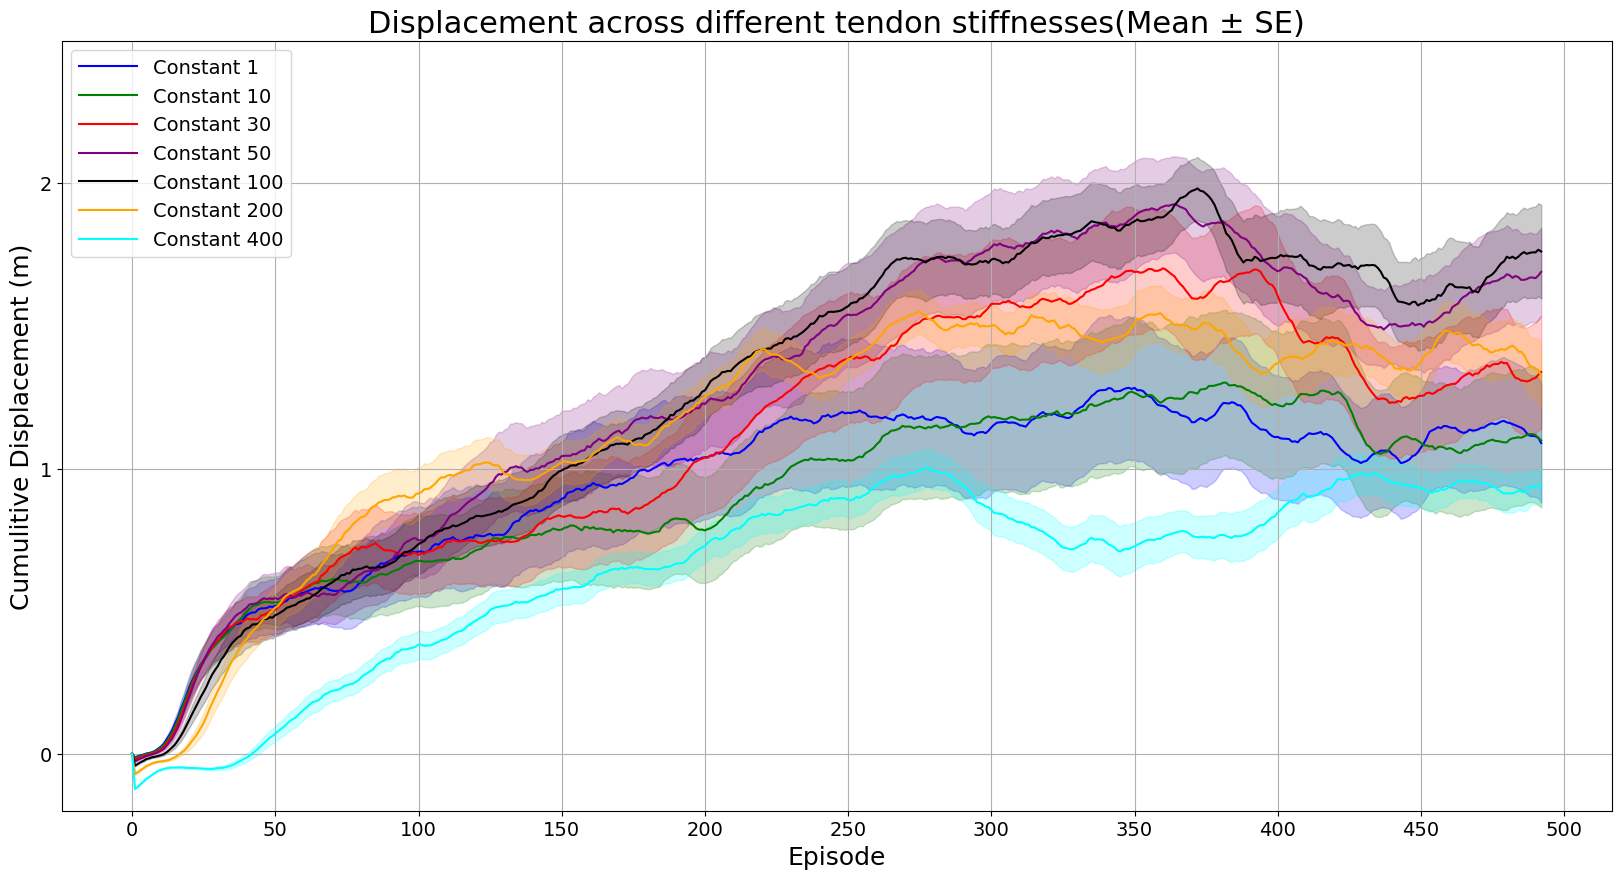

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25"
def moving_average(data, window_size=5):
    """Apply moving average smoothing."""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Define your groups: folder name and seed range
groups = {
     "Constant 1": fr"{folder_name}\LegEnv_Aug07_constant_1_lr_5e-04_PPO\displacements",
    # "Constant 5": fr"{folder_name}\LegEnv_Jul24_constant_5_lr_5e-04_PPO\displacements",

    "Constant 10": fr"{folder_name}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO\displacements",
    "Constant 30": fr"{folder_name}\LegEnv_Jul20_constant_3k_lr_5e-04_PPO\displacements",
    "Constant 50": fr"{folder_name}\LegEnv_Jul20_constant_5k_lr_5e-04_PPO\displacements",

    "Constant 100": fr"{folder_name}\LegEnv_Jul20_constant_10k_lr_5e-04_PPO\displacements",
    "Constant 200": fr"{folder_name}\LegEnv_Jul20_constant_20k_lr_5e-04_PPO\displacements",
    "Constant 400": fr"{folder_name}\LegEnv_Jul20_constant_40k_lr_5e-04_PPO\displacements",
   
    # "Dynamic 10-100": fr"{folder_name}\LegEnv_Aug02_seeds_100-120_linear_10-100_lr_5e-04_PPO\displacements",
    # "Dynamic 50-100": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO\displacements",
    # "Dynamic 50-200": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-200_lr_5e-04_PPO\displacements",



}

# Set corresponding seeds for each group
group_seeds = {
     "Constant 1": range(100, 125),
    # "Constant 5": range(100, 120),
    
    "Constant 10": range(100, 125),
    "Constant 30": range(100, 125),
    "Constant 50": range(100, 125),

    "Constant 100": range(100, 125),
    "Constant 200": range(100, 120),
    "Constant 400": range(100, 125),
    # "Dynamic 10-100": range(100, 120),
    # "Dynamic 50-100": range(100, 120),
    # "Dynamic 50-200": range(100, 120),
   
   
}

#
# Colors for plotting
colors = [  'blue', 'green', 'red', 'purple', 'black', 'orange', 'cyan','magenta','brown','darkgrey', 'tan', 'sienna']


# Smoothing window size
window_size = 10

plt.figure(figsize=(20, 10))

for idx, (label, folder) in enumerate(groups.items()):
    seeds = group_seeds[label]
    data_list = []
    for seed in seeds:
        file_path = os.path.join(folder, f"displacements_seed_{seed}.npy")
        if os.path.exists(file_path):
            data_list.append(np.load(file_path))
        else:
            print(f"Warning: {file_path} not found.")
    
    if data_list:
        group_data = np.array(data_list)
        group_mean = group_data.mean(axis=0)
        group_std = group_data.std(axis=0)/ np.sqrt(len(seeds))  # Standard error of the mean

        # Apply smoothing
        smoothed_mean = moving_average(group_mean, window_size)
        smoothed_std = moving_average(group_std, window_size)

        # Add zero at the beginning
        smoothed_mean = np.insert(smoothed_mean, 0, 0)
        smoothed_std = np.insert(smoothed_std, 0, 0)

        # Update episodes to start at 0
        episodes = np.arange(len(smoothed_mean))

        plt.plot(episodes, smoothed_mean, label=label, color=colors[idx], linestyle='-')
        plt.fill_between(episodes, smoothed_mean - smoothed_std, smoothed_mean + smoothed_std, color=colors[idx], alpha=0.2)

    else:
        print(f"No data loaded for {label}.")

# Final plot formatting
plt.title("Displacement across different tendon stiffnesses(Mean ± SE)", fontsize = 22)
plt.xlabel("Episode", fontsize = 18)
plt.ylabel("Cumulitive Displacement (m)", fontsize = 18)
plt.xticks(np.arange(0, 501, 50), fontsize=14)     # X-axis ticks every 50, font size 14
plt.yticks(np.arange(0, 5.6, 1), fontsize=14)     # Y-axis ticks every 0.5, font size 14
plt.xticks(fontsize=14)  # X-axis font size
plt.yticks(fontsize=14)  # Y-axis font size
plt.ylim(-.2, 2.5)  # Adjust y-axis limits as needed
plt.legend(fontsize=14, handlelength=3, loc='upper left')
plt.grid(True)
plt.savefig("displacement_plot_const.png", dpi=700, bbox_inches='tight')
plt.show()

  File not found: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_30k_constant_5e-04_PPO_seeds_100-100_default\tendon_lengths\tendon_lengths_seed_100.npy
  File not found: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_30k_constant_5e-04_PPO_seeds_100-100_default\tendon_lengths\tendon_lengths_seed_101.npy
  File not found: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_30k_constant_5e-04_PPO_seeds_100-100_default\tendon_lengths\tendon_lengths_seed_102.npy
  File not found: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_30k_constant_5e-04_PPO_seeds_100-100_default\tendon_lengths\tendon_lengths_seed_103.npy
  File not found: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_30k_constant_5e-04_PPO_seeds_100-100_default\tendon_lengths\tendon_lengths_seed_104.npy
  File not found: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_30k_constant_5e-04_PPO_seeds_100-100_default

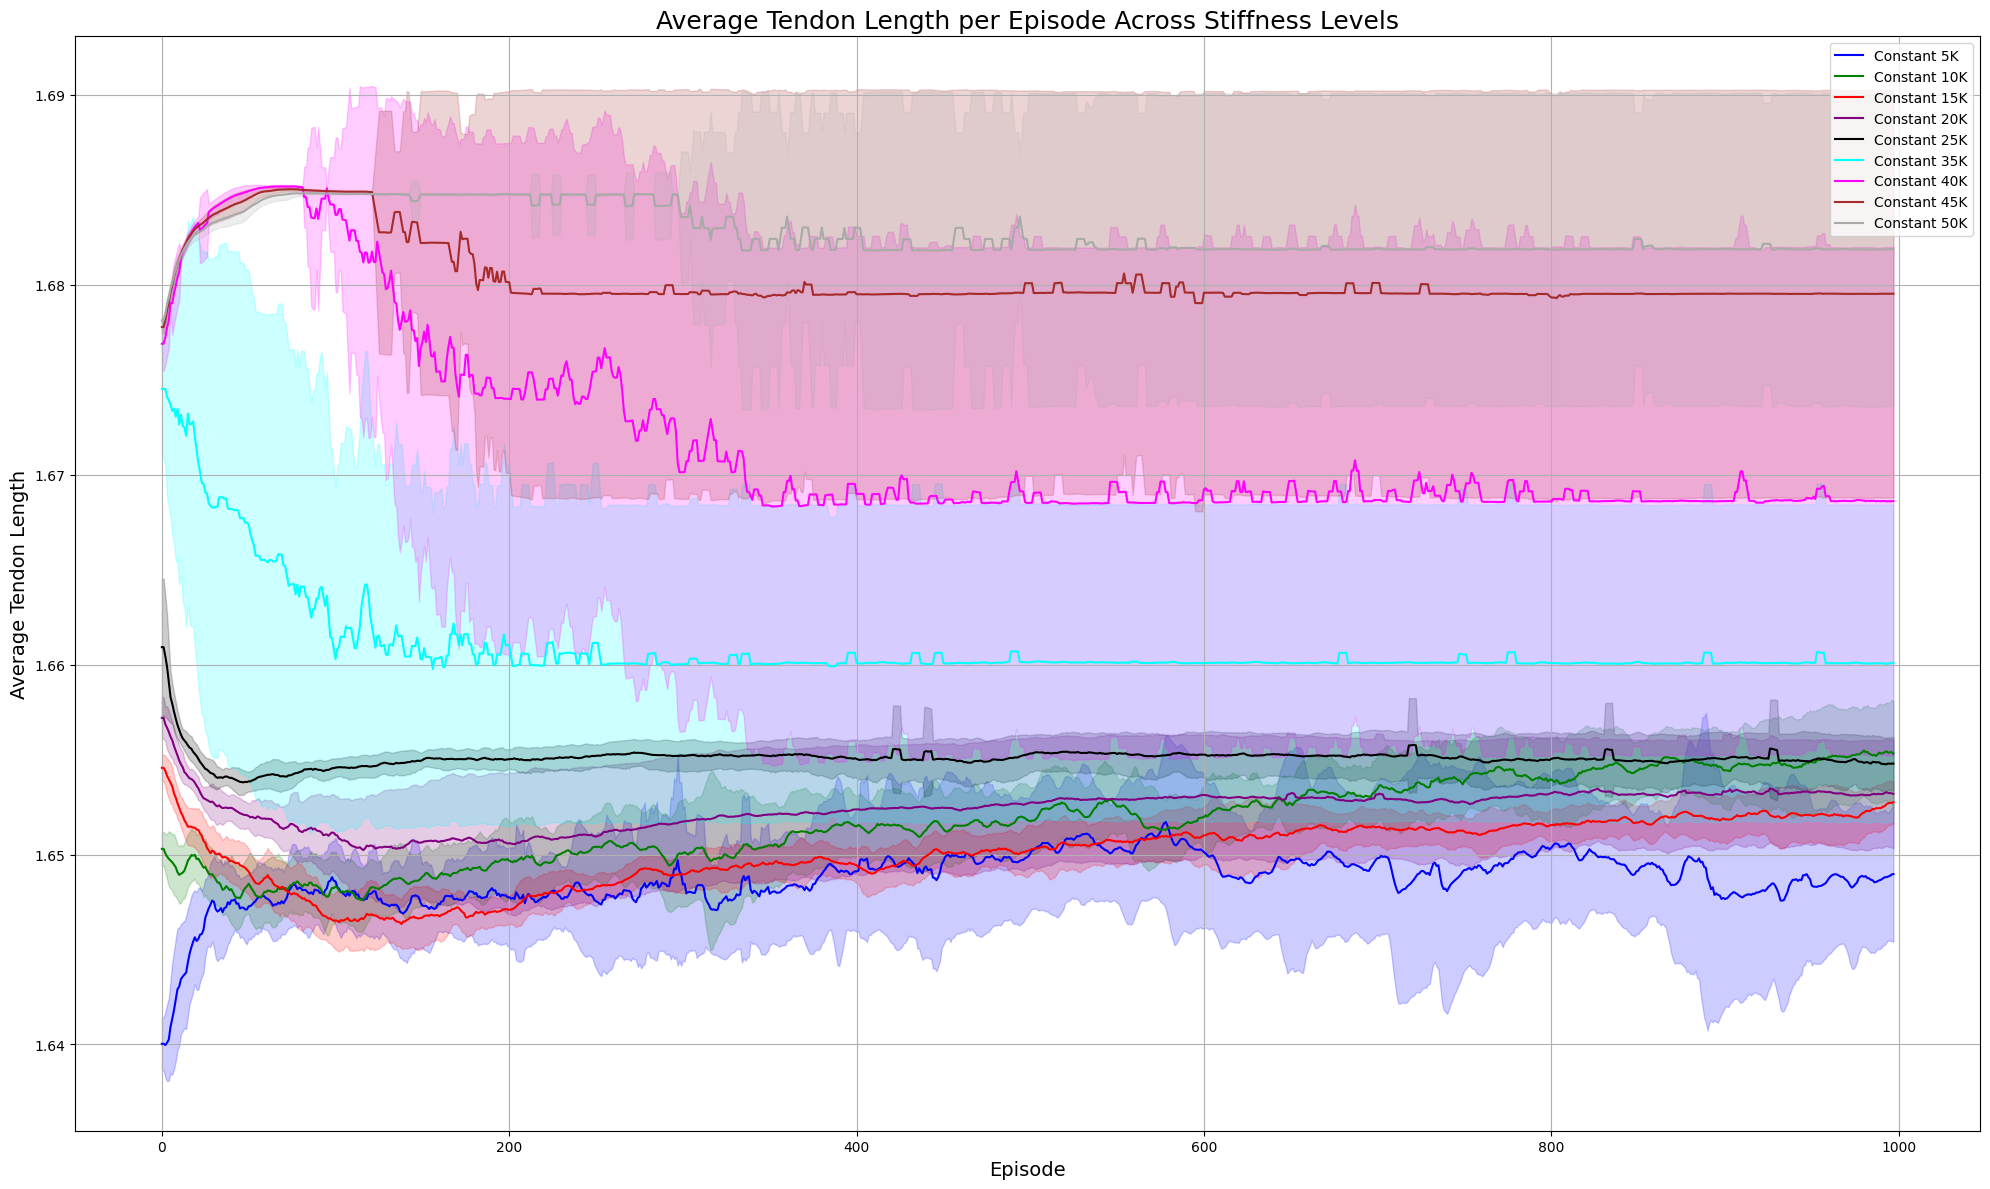

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

def moving_average(data, window_size=5):
    """Apply moving average smoothing."""
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

# Define your groups (tendon_lengths folder)
groups = {
    "Constant 5K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_5k_constant_5e-04_PPO_seeds_100-100\tendon_lengths",
    "Constant 10K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_10k_constant_5e-04_PPO_seeds_100-100\tendon_lengths",
    "Constant 15K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_15k_constant_5e-04_PPO_seeds_100-100\tendon_lengths",
    "Constant 20K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_20k_constant_5e-04_PPO_seeds_100-100\tendon_lengths",
    "Constant 25K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_25k_constant_5e-04_PPO_seeds_100-100\tendon_lengths",
    "Constant 30K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_30k_constant_5e-04_PPO_seeds_100-100_default\tendon_lengths",
    "Constant 35K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_35k_constant_5e-04_PPO_seeds_100-100\tendon_lengths",
    "Constant 40K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_40k_constant_5e-04_PPO_seeds_100-100\tendon_lengths",
    "Constant 45K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_45k_constant_5e-04_PPO_seeds_100-100\tendon_lengths",
    "Constant 50K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_50k_constant_5e-04_PPO_seeds_100-100\tendon_lengths",
}

# Seed range for each group
group_seeds = {k: range(100, 110) for k in groups}

# Plot styling
colors = ['blue', 'green', 'red', 'purple', 'black', 'orange', 'cyan', 'magenta', 'brown', 'darkgrey']
window_size = 5

plt.figure(figsize=(20, 12))

for idx, (label, folder) in enumerate(groups.items()):
    seeds = group_seeds[label]
    data_list = []

    # print(f"\n--- Loading group: {label} ---")

    for seed in seeds:
        tendon_file = os.path.join(folder, f"tendon_lengths_seed_{seed}.npy")
        if os.path.exists(tendon_file):
            try:
                data = np.load(tendon_file, allow_pickle=True)  # shape: (1001, 100, 3)
                data = np.asarray(data, dtype=np.float32)

                # Average over tendons (axis=2), then over timesteps (axis=1)
                episode_means = data.mean(axis=(1, 2))  # shape: (1001,)
                data_list.append(episode_means)
                #print(f"  Loaded seed {seed} with shape {data.shape}")
            except Exception as e:
                print(f"  Error with seed {seed}: {e}")
        else:
            print(f"  File not found: {tendon_file}")

    if data_list:
        # Truncate to shortest length
        min_len = min(len(arr) for arr in data_list)
        data_list = [arr[:min_len] for arr in data_list]
        group_data = np.stack(data_list, axis=0)  # shape: (num_seeds, episodes)

        group_mean = group_data.mean(axis=0)
        group_std = group_data.std(axis=0)

        if len(group_mean) >= window_size:
            smoothed_mean = moving_average(group_mean, window_size)
            smoothed_std = moving_average(group_std, window_size)

            # Optional: repeat first value for nicer starting point
            smoothed_mean = np.insert(smoothed_mean, 0, smoothed_mean[0])
            smoothed_std = np.insert(smoothed_std, 0, smoothed_std[0])
            episodes = np.arange(len(smoothed_mean))

            plt.plot(episodes, smoothed_mean, label=label, color=colors[idx])
            plt.fill_between(episodes, smoothed_mean - smoothed_std, smoothed_mean + smoothed_std,
                             color=colors[idx], alpha=0.2)
        else:
            print(f"  Not enough data for smoothing in group {label}.")
    else:
        print(f"  No valid data loaded for group {label}.")

# Final plot formatting
plt.title("Average Tendon Length per Episode Across Stiffness Levels", fontsize=18)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Average Tendon Length", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


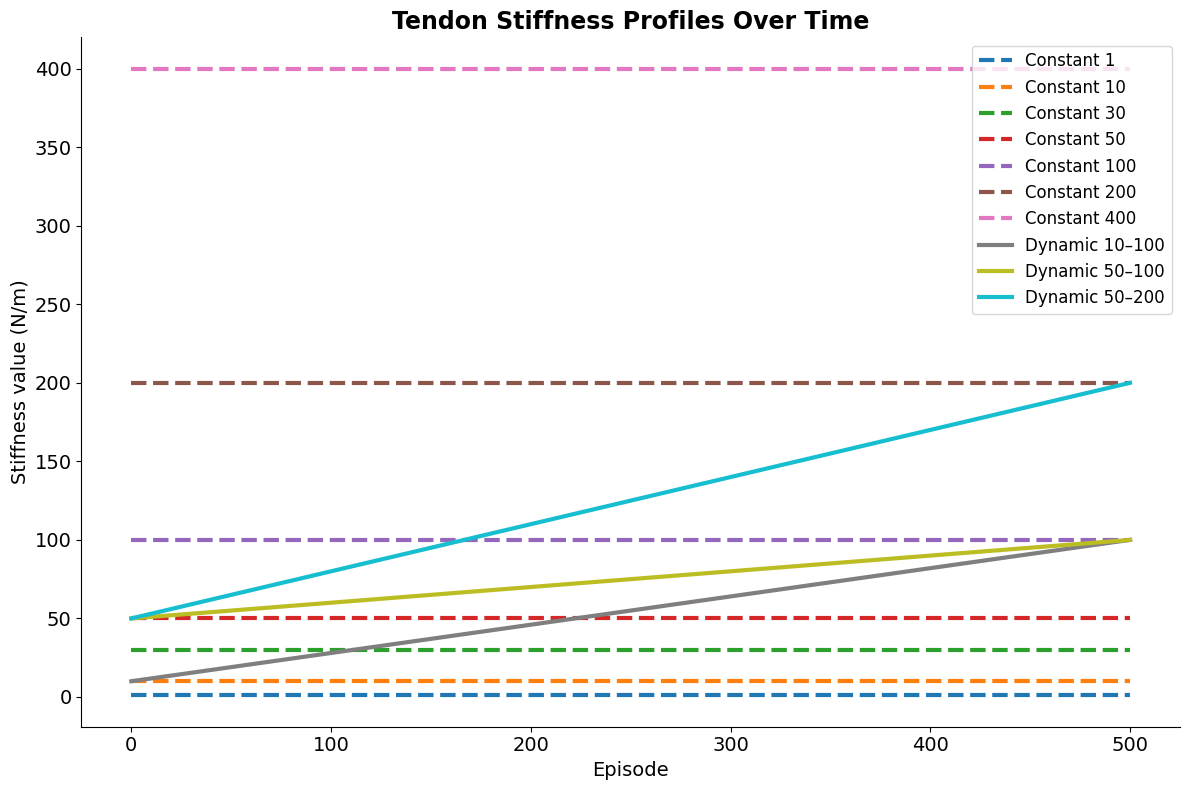

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Time setup
timesteps = 1000
total_time = 500  # seconds
time = np.linspace(0, total_time, timesteps)
plt.figure(figsize=(12, 8))
# Constant stiffness profiles
constant_stiffnesses = [1, 10, 30, 50, 100, 200, 400]
for val in constant_stiffnesses:
    plt.plot(time, np.full(timesteps, val), linestyle='--', label=f"Constant {val}", linewidth=3)

# Dynamic stiffness profiles
dynamic_profiles = {
    "Dynamic 10–100": (10, 100),
    "Dynamic 50–100": (50, 100),
    "Dynamic 50–200": (50, 200),
}

for label, (start, end) in dynamic_profiles.items():
    plt.plot(time, np.linspace(start, end, timesteps), label=label, linewidth=3)

# Plot styling
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel("Episode", fontsize=14)
plt.ylabel("Stiffness value (N/m)", fontsize=14)
plt.title("Tendon Stiffness Profiles Over Time", fontsize=17, weight='bold')
plt.grid(False)
plt.legend( fontsize=12, loc='upper right')
plt.tight_layout()
plt.savefig("tendon_stiffness_profiles.png", dpi=700, bbox_inches='tight')
plt.show()


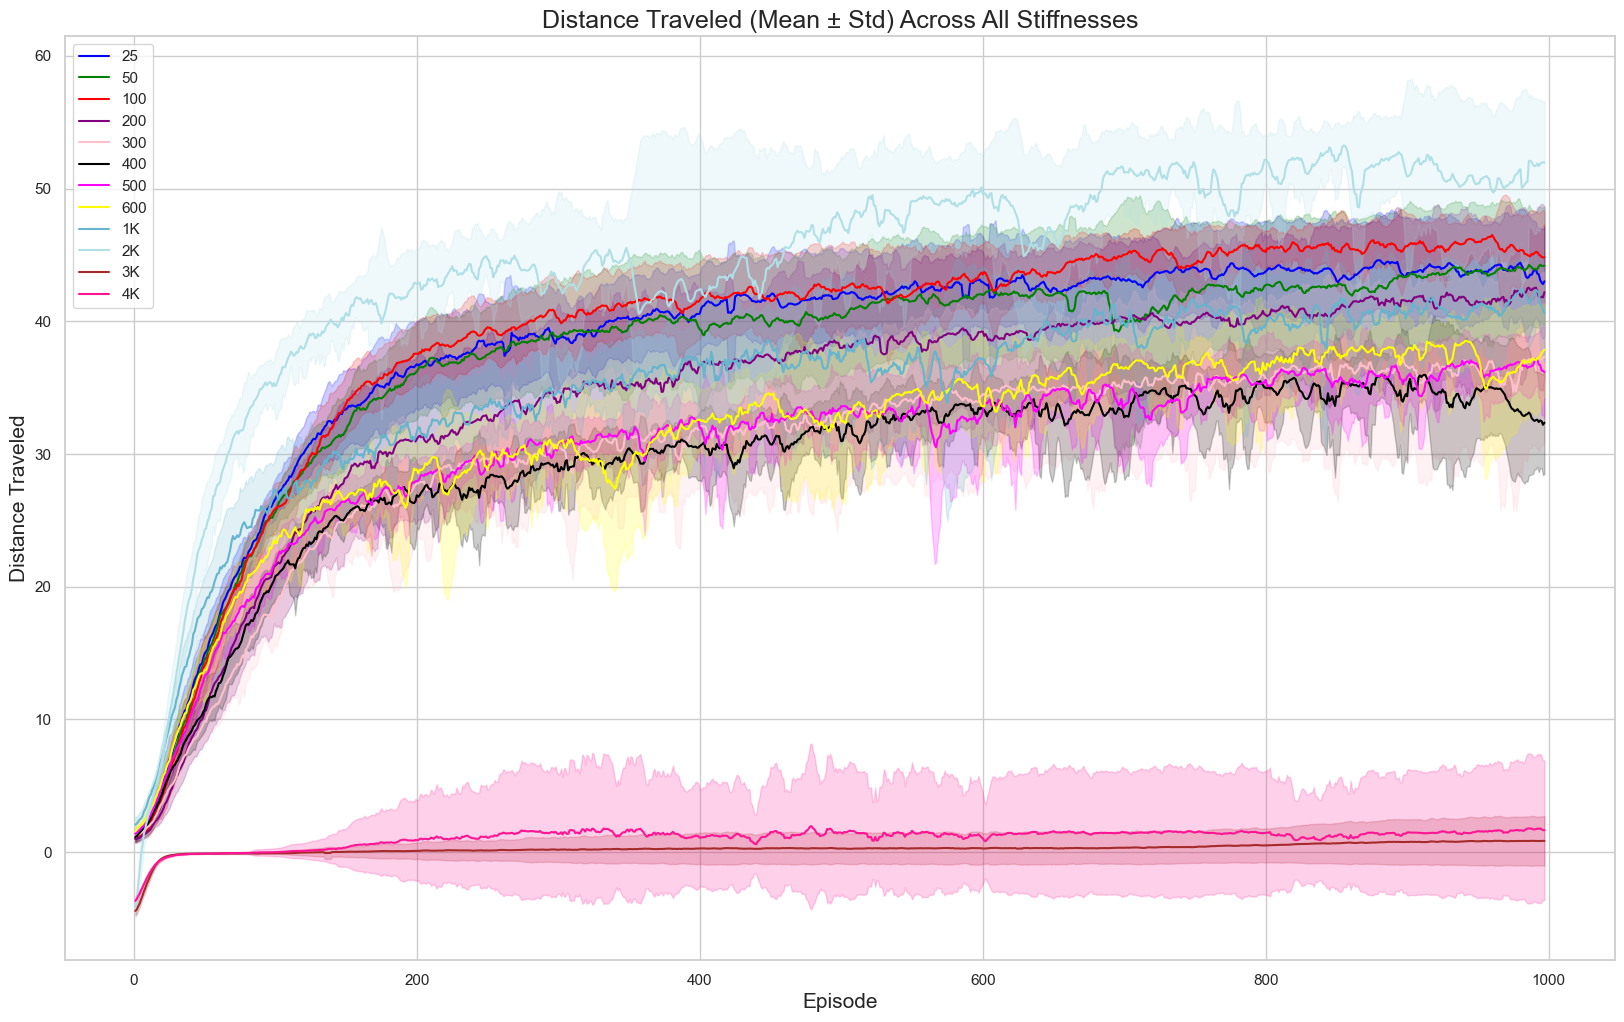

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

def moving_average(data, window_size=5):
    """Apply moving average smoothing."""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Define your groups: folder name and seed range
groups = {
    "25": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_25_lr_5e-04_PPO\displacements",
    "50": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_50_lr_5e-04_PPO\displacements",
    "100": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_100_lr_5e-04_PPO\displacements",
    "200": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_200_lr_5e-04_PPO\displacements",
    "300": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_300_lr_5e-04_PPO\displacements",
    "400": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_400_lr_5e-04_PPO\displacements",
    "500": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_500_lr_5e-04_PPO\displacements",
    "600": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_600_lr_5e-04_PPO\displacements",
    "1K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_1000_lr_5e-04_PPO\displacements",
    "2K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_2000_lr_5e-04_PPO\displacements",
    "3K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_3000_lr_5e-04_PPO\displacements",
    "4K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_4000_lr_5e-04_PPO\displacements",
    # "4K": r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jul02_constant_4000_lr_5e-04_PPO\displacements",

}

# Set corresponding seeds for each group
group_seeds = {
    "25": range(100, 110),
    "50": range(100, 110),
    "100": range(100, 110),
    "200":  range(100, 110),# Change these based on your seed filenames
    "300": range(100, 110),
    "400": range(100, 110),
    "500": range(100, 110),
    "600": range(100, 110),
    "1K": range(100,110),
    "2K": range(100,110),
    "3K": range(100,110),
    "4K": range(100,110),


}

#
# Colors for plotting
colors = ['blue', 'green', 'red', 'purple', 'pink','black',  'magenta', 'yellow','c', 'powderblue', 'brown', 'deeppink', 'tan', 'sienna' ]

# Smoothing window size
window_size = 5

plt.figure(figsize=(20, 12))

for idx, (label, folder) in enumerate(groups.items()):
    seeds = group_seeds[label]
    data_list = []
    for seed in seeds:
        file_path = os.path.join(folder, f"displacements_seed_{seed}.npy")
        if os.path.exists(file_path):
            data_list.append(np.load(file_path))
        else:
            print(f"Warning: {file_path} not found.")
    
    if data_list:
        group_data = np.array(data_list)
        group_mean = group_data.mean(axis=0)
        group_std = group_data.std(axis=0)

        # Apply smoothing
        smoothed_mean = moving_average(group_mean, window_size)
        smoothed_std = moving_average(group_std, window_size)

        # Adjust x-axis to match smoothed data
        episodes = np.arange(1, len(smoothed_mean) + 1)

        plt.plot(episodes, smoothed_mean, label=label, color=colors[idx], linestyle='-')
        plt.fill_between(episodes, smoothed_mean - smoothed_std, smoothed_mean + smoothed_std, color=colors[idx], alpha=0.2)
    else:
        print(f"No data loaded for {label}.")

# Final plot formatting
plt.title("Distance Traveled (Mean ± Std) Across All Stiffnesses", fontsize = 18)
plt.xlabel("Episode", fontsize = 15)
plt.ylabel("Distance Traveled", fontsize = 15)
plt.legend()
plt.grid(True)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_2812\798834148.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


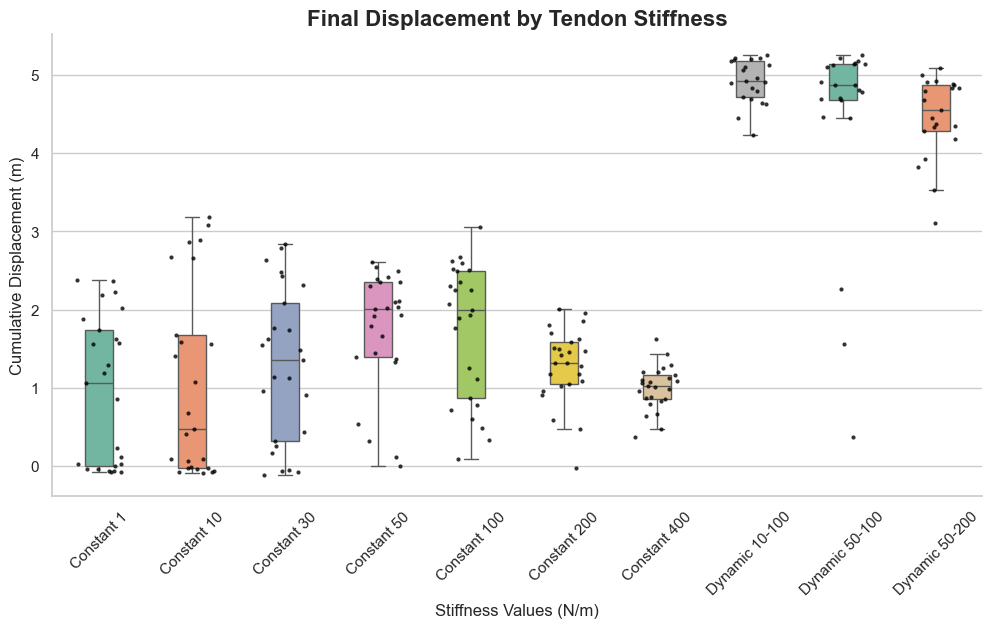

<Figure size 640x480 with 0 Axes>

In [4]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import ttest_ind




group_seeds = {k: range(100, 125) for k in groups}

# Load data
data = []
for stiffness, folder in groups.items():
    for seed in group_seeds[stiffness]:
        file_path = os.path.join(folder, f"displacements_seed_{seed}.npy")
        if os.path.exists(file_path):
            displacement = np.load(file_path)[-1]
            data.append({"Stiffness": stiffness, "Displacement": displacement})
        else:
            print(f"Warning: {file_path} not found.")

df = pd.DataFrame(data)


# Choose reference group to compare against
reference_group = "Dynamic 50-100"
reference_data = df[df['Stiffness'] == reference_group]['Displacement'].values

stiffness_order = list(groups.keys())

# Collect p-values

# Ensure correct ordering of x-axis
stiffness_order = list(groups.keys())


# Plotting
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

sns.boxplot(
    x="Stiffness",
    y="Displacement",
    data=df,
    palette="Set2",
    width=0.3,
    fliersize=0,
    order=stiffness_order
)

sns.stripplot(
    x="Stiffness",
    y="Displacement",
    data=df,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.8,
    order=stiffness_order
)

plt.title("Final Displacement by Tendon Stiffness", fontsize=16, weight='bold')
plt.xlabel("Stiffness Values (N/m)", fontsize=12)
plt.ylabel("Cumulative Displacement (m)", fontsize=12)
plt.xticks(rotation=45)


y_max = df['Displacement'].max()
y_offset = y_max * 0.05  # 5% of range

ax = plt.gca()

# Get correct x positions from seaborn
xtick_labels = [tick.get_text() for tick in ax.get_xticklabels()]
xtick_positions = ax.get_xticks()





# Format x-axis ticks (optional: change 1000 -> 1K etc.)
# ax.set_xticklabels([f"{int(x/1000)}K" if x >= 1000 else str(x) for x in stiffness_order])

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.tight_layout()
plt.show()
plt.savefig("boxplot_all.png", dpi=700, bbox_inches='tight')


In [103]:
import plotly.express as px

fig = px.box(
    df,
    x="Stiffness",
    y="Displacement",
    points="all",  # show all points
    color="Stiffness",  # optional for coloring
    title="Final Displacement by Tendon Stiffness"
)
fig.show()


C:\Users\User\AppData\Local\Temp\ipykernel_2812\1761695066.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


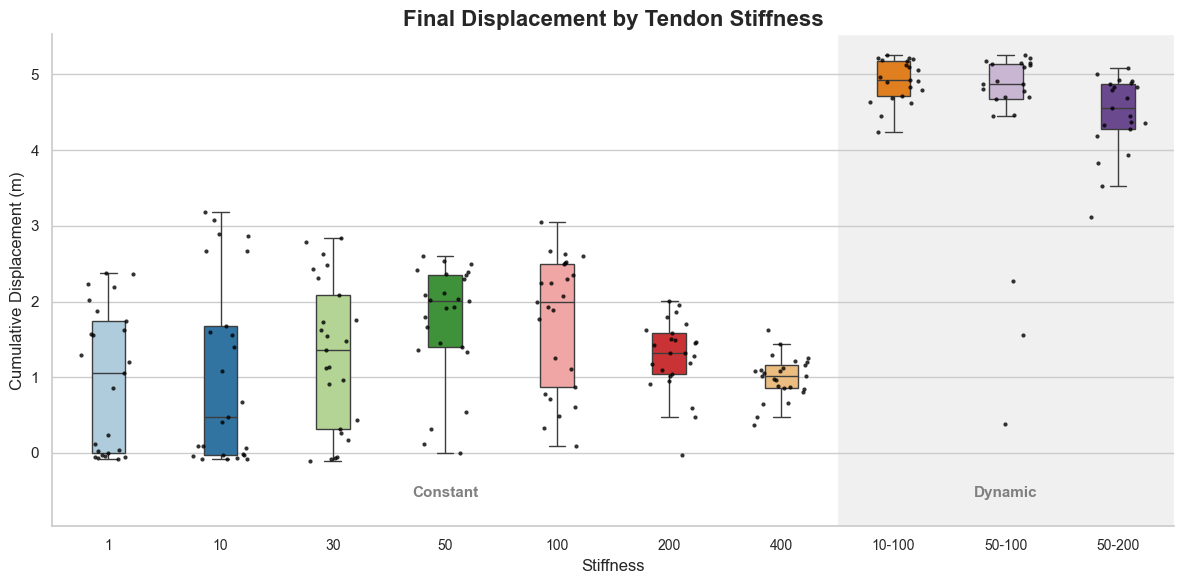

In [8]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ==================== LOAD DATA ====================
data = []
for stiffness, folder in groups.items():
    for seed in group_seeds[stiffness]:
        file_path = os.path.join(folder, f"displacements_seed_{seed}.npy")
        if os.path.exists(file_path):
            displacement = np.load(file_path)[-1]
            data.append({"Stiffness": stiffness, "Displacement": displacement})
        else:
            print(f"Warning: {file_path} not found.")

df = pd.DataFrame(data)

# ==================== PLOT SETUP ====================
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")
ax = plt.gca()

stiffness_order = list(groups.keys())
tick_positions = list(range(len(stiffness_order)))
tick_labels_bottom = [s.replace("Constant ", "").replace("Dynamic ", "") for s in stiffness_order]

# Identify indices for dynamic and constant
dynamic_indices = [i for i, s in enumerate(stiffness_order) if "Dynamic" in s]
constant_indices = [i for i, s in enumerate(stiffness_order) if "Constant" in s]

# ==================== BACKGROUND HIGHLIGHT ====================
if dynamic_indices:
    xmin = min(dynamic_indices) - 0.5
    xmax = max(dynamic_indices) + 0.5
    ax.axvspan(xmin, xmax, facecolor="#f0f0f0", zorder=0)

# ==================== BOXPLOT + STRIP ====================


sns.boxplot(
    x="Stiffness",
    y="Displacement",
    data=df,
    palette= "Paired", #"pastel",
    width=0.3,
    fliersize=0,
    order=stiffness_order,
    ax=ax
)

sns.stripplot(
    x="Stiffness",
    y="Displacement",
    data=df,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.8,
    order=stiffness_order,
    ax=ax
)

# ==================== AXIS LABELS ====================
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels_bottom, fontsize=10)
ax.set_ylabel("Cumulative Displacement (m)", fontsize=12)
ax.set_xlabel("Stiffness", fontsize=12)
ax.set_title("Final Displacement by Tendon Stiffness", fontsize=16, weight='bold')

# ==================== ADD GROUP LABELS BELOW ====================
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin - (ymax - ymin) * 0.1, ymax)  # Make room below x-axis
y_bottom = ymin - (ymax - ymin) * 0.01

if constant_indices:
    mid_const = sum(constant_indices) / len(constant_indices)
    ax.text(mid_const, y_bottom, "Constant", ha='center', va='top', fontsize=11, fontweight='bold', color='gray')

if dynamic_indices:
    mid_dyn = sum(dynamic_indices) / len(dynamic_indices)
    ax.text(mid_dyn, y_bottom, "Dynamic", ha='center', va='top', fontsize=11, fontweight='bold', color='gray')

# ==================== CLEAN UP ====================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("boxplot_with_labels.png", dpi=700,) # bbox_inches='tight')
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_17740\613599080.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='StiffnessType', ylabel='Displacement'>

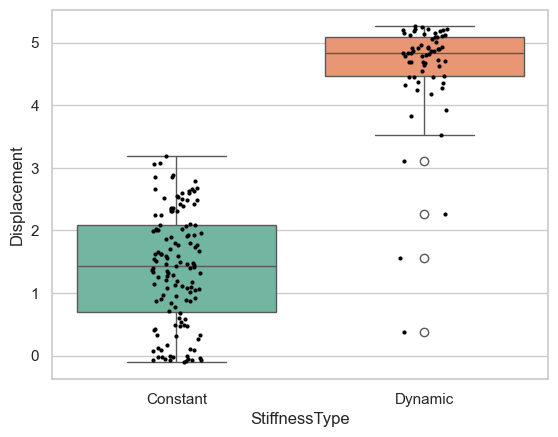

In [39]:
df['StiffnessType'] = df['Stiffness'].apply(lambda x: 'Dynamic' if 'Dynamic' in x else 'Constant')
sns.boxplot(x='StiffnessType', y='Displacement', data=df, palette='Set2')
sns.stripplot(x='StiffnessType', y='Displacement', data=df, color='black', jitter=True, size=3)



C:\Users\User\AppData\Local\Temp\ipykernel_17740\1259230960.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Stiffness', ylabel='Displacement'>

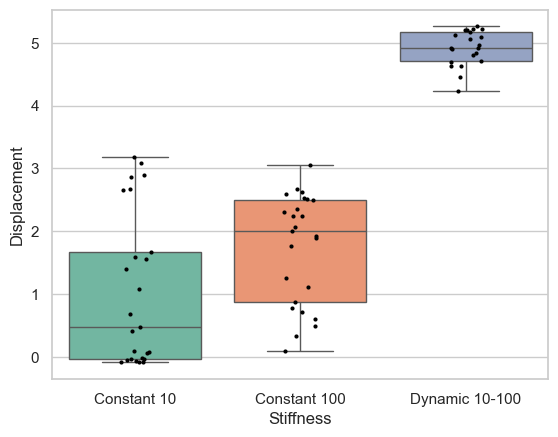

In [40]:
subset_df = df[df['Stiffness'].isin(['Constant 10', 'Constant 100', 'Dynamic 10-100'])]


sns.boxplot(x='Stiffness', y='Displacement', data=subset_df, palette='Set2')
sns.stripplot(x='Stiffness', y='Displacement', data=subset_df,        color='black', jitter=True, size=3)


In [41]:
from scipy.stats import ttest_ind

groups_to_compare = ['Constant 10', 'Constant 100', 'Dynamic 10-100']
comparisons = [
    ('Constant 10', 'Constant 100'),
    ('Constant 10', 'Dynamic 10-100'),
    ('Constant 100', 'Dynamic 10-100')
]

for g1, g2 in comparisons:
    d1 = subset_df[subset_df['Stiffness'] == g1]['Displacement']
    d2 = subset_df[subset_df['Stiffness'] == g2]['Displacement']
    stat, p = ttest_ind(d1, d2, equal_var=False)
    print(f"{g1} vs {g2}: p = {p:.3e}")


Constant 10 vs Constant 100: p = 2.334e-02
Constant 10 vs Dynamic 10-100: p = 5.117e-15
Constant 100 vs Dynamic 10-100: p = 5.467e-17


C:\Users\User\AppData\Local\Temp\ipykernel_17740\3813217459.py:46: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




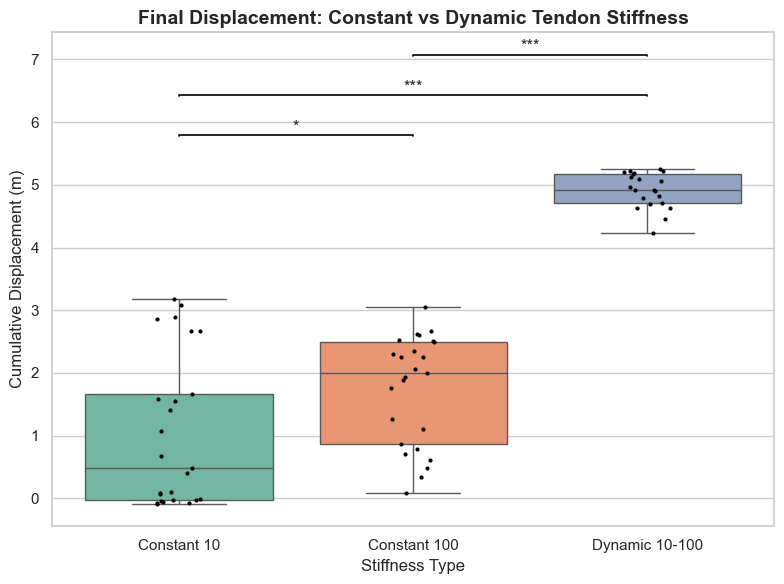

In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ------------------------
# 1. Filter Relevant Groups
# ------------------------
target_groups = ["Constant 10", "Constant 100", "Dynamic 10-100"]
subset_df = df[df['Stiffness'].isin(target_groups)]

# ------------------------
# 2. Run Pairwise t-tests
# ------------------------
def get_significance_marker(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

comparisons = [
    ("Constant 10", "Constant 100"),
    ("Constant 10", "Dynamic 10-100"),
    ("Constant 100", "Dynamic 10-100")
]

results = []
for g1, g2 in comparisons:
    d1 = subset_df[subset_df['Stiffness'] == g1]['Displacement']
    d2 = subset_df[subset_df['Stiffness'] == g2]['Displacement']
    stat, p = ttest_ind(d1, d2, equal_var=False)
    results.append((g1, g2, p, get_significance_marker(p)))

# ------------------------
# 3. Plot Boxplot + Stars
# ------------------------
order = target_groups
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

ax = sns.boxplot(data=subset_df, x="Stiffness", y="Displacement", order=order, palette="Set2")
sns.stripplot(data=subset_df, x="Stiffness", y="Displacement", color="black", size=3, jitter=True, order=order)

# ------------------------
# 4. Add significance markers
# ------------------------
y_max = subset_df['Displacement'].max()
y_offset = (subset_df['Displacement'].max() - subset_df['Displacement'].min()) * 0.1
height_step = y_offset * 1.2
start_height = y_max + y_offset

for i, (g1, g2, p, marker) in enumerate(results):
    x1 = order.index(g1)
    x2 = order.index(g2)
    y = start_height + i * height_step
    ax.plot([x1, x1, x2, x2], [y-0.02, y, y, y-0.02], color='black', linewidth=1.2)
    ax.text((x1 + x2) / 2, y + 0.01, marker, ha='center', va='bottom', fontsize=12)

# ------------------------
# 5. Formatting
# ------------------------
plt.title("Final Displacement: Constant vs Dynamic Tendon Stiffness", fontsize=14, weight='bold')
plt.xlabel("Stiffness Type")
plt.ylabel("Cumulative Displacement (m)")
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_20320\1404846198.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


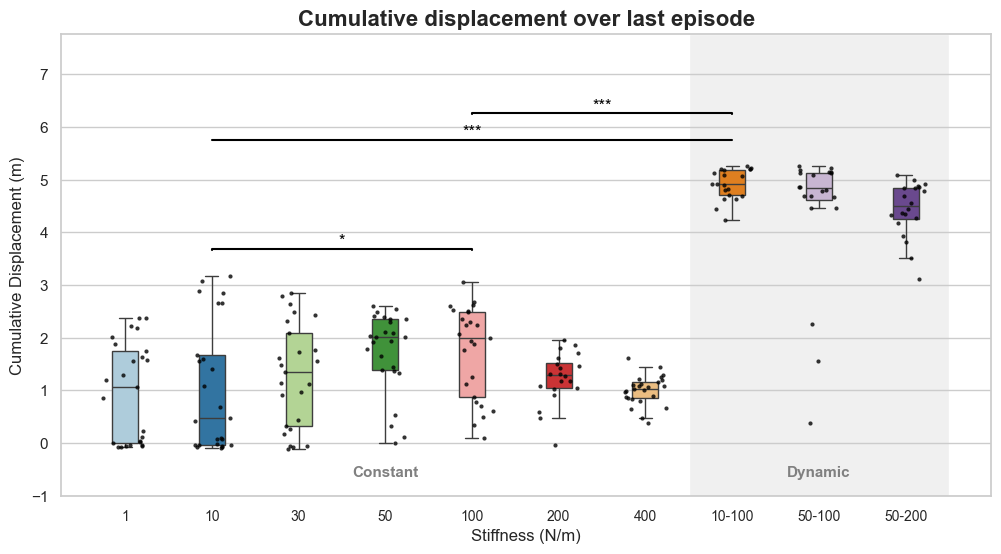

In [4]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu

from scipy.stats import ttest_ind

# ------------- Define Your Data Paths -------------

# ------------- Load Displacement Data -------------
data = []
for stiffness, folder in groups.items():
    for seed in group_seeds[stiffness]:
        file_path = os.path.join(folder, f"displacements_seed_{seed}.npy")
        if os.path.exists(file_path):
            displacement = np.load(file_path)[-1]
            data.append({"Stiffness": stiffness, "Displacement": displacement})
        else:
            print(f"Warning: {file_path} not found.")
df = pd.DataFrame(data)

# ------------- Set Up Plot Elements -------------
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")
ax = plt.gca()

stiffness_order = list(groups.keys())
tick_positions = list(range(len(stiffness_order)))
tick_labels_bottom = [s.replace("Constant ", "").replace("Dynamic ", "") for s in stiffness_order]

dynamic_indices = [i for i, s in enumerate(stiffness_order) if "Dynamic" in s]
constant_indices = [i for i, s in enumerate(stiffness_order) if "Constant" in s]

# ------------- Highlight Dynamic Region -------------
if dynamic_indices:
    xmin = min(dynamic_indices) - 0.5
    xmax = max(dynamic_indices) + 0.5
    ax.axvspan(xmin, xmax, facecolor="#f0f0f0", zorder=0)

# ------------- Plot Data -------------
sns.boxplot(
    x="Stiffness", y="Displacement", data=df,
    palette="Paired", width=0.3, fliersize=0,
    order=stiffness_order, ax=ax
)
sns.stripplot(
    x="Stiffness", y="Displacement", data=df,
    color="black", size=3, jitter=0.25, alpha=0.8,
    order=stiffness_order, ax=ax
)

# ------------- Axis Labels and Group Titles -------------
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels_bottom, fontsize=10)
ax.set_ylabel("Cumulative Displacement (m)", fontsize=12)
ax.set_xlabel("Stiffness (N/m)", fontsize=12)
ax.set_title("Cumulative displacement over last episode", fontsize=16, weight='bold')

# Add "Constant" and "Dynamic" under x-axis
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin - (ymax - ymin) * 0.1, ymax)
y_bottom = ymin - (ymax - ymin) * 0.01
if constant_indices:
    mid_const = sum(constant_indices) / len(constant_indices)
    ax.text(mid_const, y_bottom, "Constant", ha='center', va='top', fontsize=11, fontweight='bold', color='gray')
if dynamic_indices:
    mid_dyn = sum(dynamic_indices) / len(dynamic_indices)
    ax.text(mid_dyn, y_bottom, "Dynamic", ha='center', va='top', fontsize=11, fontweight='bold', color='gray')

# ------------- Statistical Significance Tests -------------

# === Adjust Y-axis to create enough vertical space for significance markers ===
group_max = df.groupby("Stiffness")["Displacement"].max().to_dict()
ymax = max(group_max.values())
ymin = df['Displacement'].min()-0.9
y_range = ymax - ymin

extra_space = y_range * 0.4  # give 40% extra room on top
ax.set_ylim(ymin, ymax + extra_space)

# === Statistical tests with proper spacing ===
from scipy.stats import ttest_ind

comparisons = [
    ("Constant 10", "Constant 100"),
    ("Constant 10", "Dynamic 10-100"),
    ("Constant 100", "Dynamic 10-100")
]

def get_significance_marker(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

y_offset = y_range * 0.08
used_heights = []

for i, (g1, g2) in enumerate(comparisons):
    d1 = df[df["Stiffness"] == g1]["Displacement"]
    d2 = df[df["Stiffness"] == g2]["Displacement"]
    # stat, p = ttest_ind(d1, d2, equal_var=False)

    # Inside your comparison loop
    stat, p = mannwhitneyu(d1, d2, alternative='two-sided')
    marker = get_significance_marker(p)

    x1 = stiffness_order.index(g1)
    x2 = stiffness_order.index(g2)
    y = max(group_max[g1], group_max[g2]) + y_offset

    # Avoid overlap
    while y in used_heights:
        y += y_offset
    used_heights.append(y)


    # Draw lines and star
    ax.plot([x1, x1, x2, x2], [y - 0.01, y, y, y - 0.01], color='black', linewidth=1.5)
    ax.text((x1 + x2) / 2, y + 0.005, marker, ha='center', va='bottom', fontsize=12, color='black')

    plt.savefig("boxplot_with_significance.png", dpi=700, bbox_inches='tight')




In [96]:
from scipy.stats import mannwhitneyu, shapiro
import numpy as np

# ---------- Define Groups to Compare ----------
comparisons = [
    ("Constant 10", "Constant 100"),
    ("Constant 10", "Dynamic 10-100"),
    ("Constant 100", "Dynamic 10-100")
]

def get_significance_marker(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

def cliffs_delta(x, y):
    """Calculate Cliff's delta effect size."""
    nx, ny = len(x), len(y)
    gt = sum([1 for xi in x for yi in y if xi > yi])
    lt = sum([1 for xi in x for yi in y if xi < yi])
    return (gt - lt) / (nx * ny)

# ---------- Run Tests ----------
results = []
for g1, g2 in comparisons:
    d1 = df[df['Stiffness'] == g1]['Displacement'].values
    d2 = df[df['Stiffness'] == g2]['Displacement'].values

    # Normality test
    _, p1_norm = shapiro(d1)
    _, p2_norm = shapiro(d2)
    normal1 = p1_norm > 0.05
    normal2 = p2_norm > 0.05

    # Mann-Whitney U test
    stat, p_val = mannwhitneyu(d1, d2, alternative='two-sided')

    # Cliff’s Delta
    delta = cliffs_delta(d1, d2)

    results.append({
        'Group 1': g1,
        'Group 2': g2,
        'p-value': p_val,
        'marker': get_significance_marker(p_val),
        'cliffs_delta': round(delta, 3),
        'group1_normal': normal1,
        'group2_normal': normal2
    })

# ---------- Print Summary ----------
print("\nComparison Summary:\n")
for r in results:
    print(f"{r['Group 1']} vs {r['Group 2']}: p={r['p-value']:.4f} {r['marker']}, Cliff's Δ={r['cliffs_delta']} "
          f"(Normal? {r['group1_normal']} / {r['group2_normal']})")



Comparison Summary:

Constant 10 vs Constant 100: p=0.0244 *, Cliff's Δ=-0.373 (Normal? False / False)
Constant 10 vs Dynamic 10-100: p=0.0000 ***, Cliff's Δ=-1.0 (Normal? False / True)
Constant 100 vs Dynamic 10-100: p=0.0000 ***, Cliff's Δ=-1.0 (Normal? False / True)


Missing: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_50k_constant_5e-04_PPO_seeds_100-100\distance\displacement_history_seed_109.npy


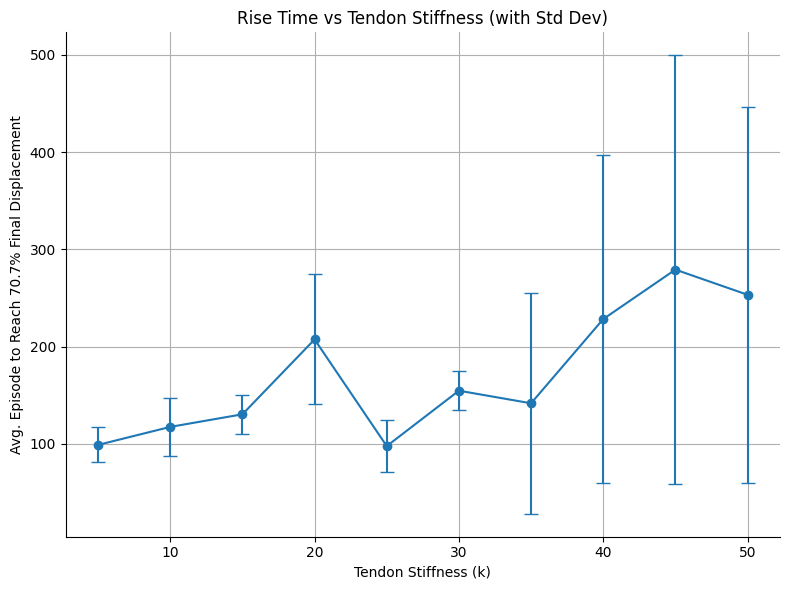

In [1]:
###7.7% Mean and STD
import numpy as np
import os
import re
import matplotlib.pyplot as plt

# Base path
base_folder = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data" #\with_springlength_param"

# Detect all tendon folders
# Detect only Jun06 tendon folders
tendon_folders = [
    f for f in os.listdir(base_folder)
    if "constant" in f and "Jun06" in f and os.path.isdir(os.path.join(base_folder, f))
]

# Collect results
stiffness_vals = []
mean_episodes_to_70 = []
std_episodes_to_70 = []

for folder in sorted(tendon_folders):
    full_path = os.path.join(base_folder, folder, "distance")
    if not os.path.exists(full_path):
        continue

    # Extract stiffness value from folder name
    match = re.search(r'constant_(\d+)k', folder)
    if not match:
        continue
    stiffness = int(match.group(1))

    episodes_per_seed = []

    for seed in range(100, 120):  # seeds 100–119
          file_path = os.path.join(full_path, f"displacement_history_seed_{seed}.npy")
          if not os.path.exists(file_path):
            print(f"Missing: {file_path}")
            continue

          disp = np.load(file_path)
          if disp.ndim == 0 or len(disp) == 0:
            continue

#         final_val = disp[-1]
          final_val = np.mean(disp[-10:])  # Mean of last 10 episodes
          threshold = 0.707 * final_val

          try:
            episode_reach = np.argmax(disp >= threshold)
            episodes_per_seed.append(episode_reach)
          except Exception as e:
            print(f"Error in seed {seed}: {e}")

    if episodes_per_seed:
        stiffness_vals.append(stiffness)
        mean_episodes_to_70.append(np.mean(episodes_per_seed))
        std_episodes_to_70.append(np.std(episodes_per_seed))

# Sort for plotting
sorted_data = sorted(zip(stiffness_vals, mean_episodes_to_70, std_episodes_to_70))
stiffness_vals, mean_episodes_to_70, std_episodes_to_70 = zip(*sorted_data)
# Plot with error bars
plt.figure(figsize=(8, 6))
ax = plt.gca()

ax.errorbar(stiffness_vals, mean_episodes_to_70, yerr=std_episodes_to_70, fmt='-o', capsize=5)
ax.set_xlabel("Tendon Stiffness (k)")
ax.set_ylabel("Avg. Episode to Reach 70.7% Final Displacement")
ax.set_title("Rise Time vs Tendon Stiffness (with Std Dev)")

# Add grid
ax.grid(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_8404\1999868525.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


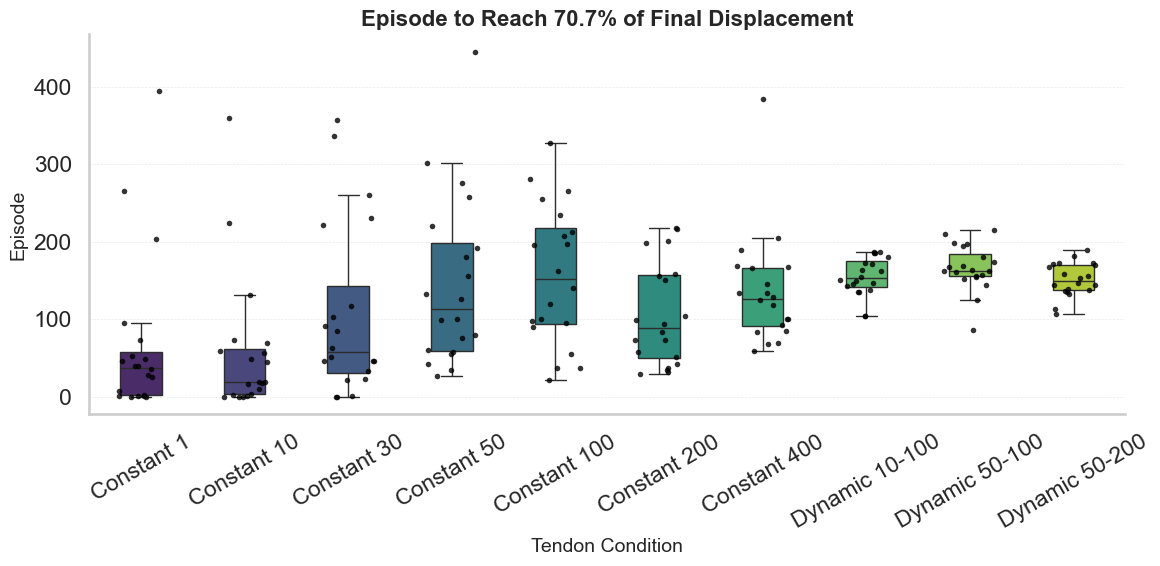

In [5]:
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Set modern style
sns.set(style="whitegrid", context="talk")


group_seeds = {k: range(100, 120) for k in groups}

# Collect data
records = []

for label, folder in groups.items():
    for seed in group_seeds[label]:
        file_path = os.path.join(folder, f"displacements_seed_{seed}.npy")
        if not os.path.exists(file_path):
            continue

        disp = np.load(file_path)
        if disp.ndim == 0 or len(disp) == 0:
            continue

        final_val = np.mean(disp[-10:])
        threshold = 0.707 * final_val

        above_thresh = np.where(disp >= threshold)[0]
        if len(above_thresh) > 0:
            reach_episode = above_thresh[0]
            records.append({
                "Group": label,
                "Episode": reach_episode,
                "Seed": seed
            })

# Create DataFrame
df = pd.DataFrame(records)

if df.empty:
    print("No data met the threshold condition.")
else:
    # Order categories logically
    category_order = list(groups.keys())
    df["Group"] = pd.Categorical(df["Group"], categories=category_order, ordered=True)

    plt.figure(figsize=(12, 6))
    ax = plt.gca()

    # Palette
    palette = sns.color_palette("viridis", n_colors=len(category_order))

    # Boxplot
    sns.boxplot(
        x="Group",
        y="Episode",
        data=df,
        palette=palette,
        width=0.4,
        fliersize=0,
        ax=ax
    )

    # Overlay jittered points
    sns.stripplot(
        x="Group",
        y="Episode",
        data=df,
        color="black",
        size=4,
        jitter=0.25,
        alpha=0.8,
        ax=ax
    )

    # Titles and labels
    ax.set_title("Episode to Reach 70.7% of Final Displacement", fontsize=16, weight='bold')
    ax.set_xlabel("Tendon Condition", fontsize=14)
    ax.set_ylabel("Episode", fontsize=14)
    ax.tick_params(axis='x', rotation=30)

    # Clean aesthetics
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
    ax.xaxis.grid(False)

    plt.tight_layout()
    plt.savefig("episodes_to_reach_70.7_percent.png", dpi=700, bbox_inches='tight')
    plt.show()


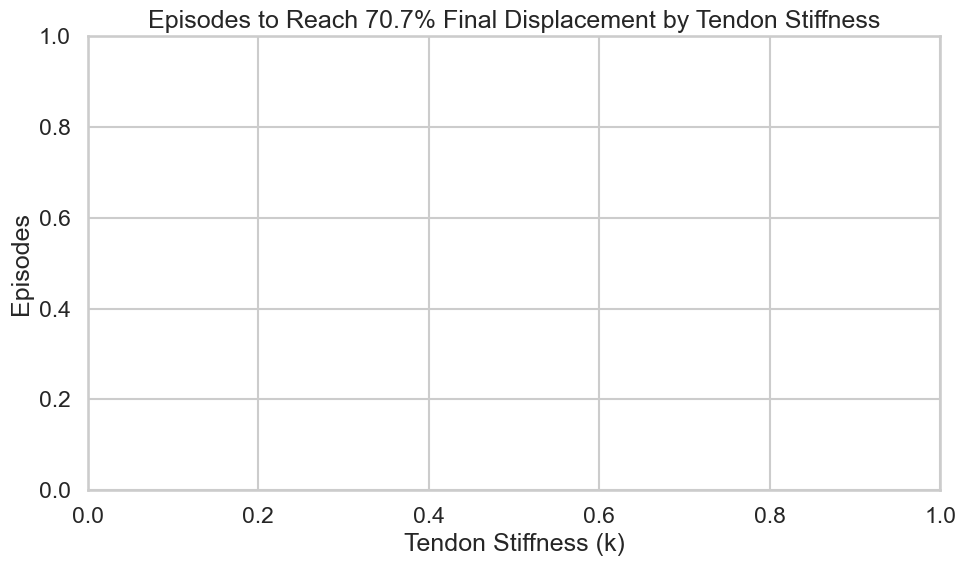

ValueError: Need at least two groups in stats.kruskal()

In [11]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu

# Base folder containing your data
base_folder = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data"

# Detect relevant folders
tendon_folders = [
    f for f in os.listdir(base_folder)
    if "constant" in f and "Jul02" in f and os.path.isdir(os.path.join(base_folder, f))
]

# Dictionary to store all episode data per stiffness
all_data = {}

for folder in sorted(tendon_folders):
    full_path = os.path.join(base_folder, folder, "placements")
    if not os.path.exists(full_path):
        continue

    # Extract stiffness value from folder name
    match = re.search(r'constant_(\d+)k', folder)
    if not match:
        continue
    stiffness = int(match.group(1))

    episodes_per_seed = []

    for seed in range(100, 120):  # 20 seeds
        file_path = os.path.join(full_path, f"displacements_seed_{seed}.npy")
        if not os.path.exists(file_path):
            print(f"Missing: {file_path}")
            continue

        disp = np.load(file_path)
        if disp.ndim == 0 or len(disp) == 0:
            continue

        final_val = np.mean(disp[-10:])  # Mean of last 10 values
        #a = 0.707
        a = 1
        threshold = a  * final_val

        try:
            episode_reach = np.argmax(disp >= threshold)
            episodes_per_seed.append(episode_reach)
        except Exception as e:
            print(f"Error in seed {seed} for {stiffness}k: {e}")

    if episodes_per_seed:
        all_data[stiffness] = episodes_per_seed

# -------------------------------
# Visualization: Boxplot
# -------------------------------
# Flatten data into a DataFrame
flat_data = [(k, ep) for k, vals in all_data.items() for ep in vals]
df = pd.DataFrame(flat_data, columns=["Stiffness", "Episodes"])

plt.figure(figsize=(10, 6))
sns.boxplot(x="Stiffness", y="Episodes", data=df)
plt.title("Episodes to Reach 70.7% Final Displacement by Tendon Stiffness")
plt.xlabel("Tendon Stiffness (k)")
plt.ylabel("Episodes")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------
# Kruskal-Wallis Test
# -------------------------------
groups = [vals for vals in all_data.values()]
stat, p = kruskal(*groups)
print(f"\nKruskal-Wallis Test: H={stat:.2f}, p={p:.4f}")

# -------------------------------
# Pairwise Mann-Whitney U Tests with Bonferroni Correction
# -------------------------------
print("\nPairwise Mann-Whitney U Tests:")
stiffness_keys = sorted(all_data.keys())
comparisons = list(combinations(stiffness_keys, 2))
alpha = 0.05
corrected_alpha = alpha / len(comparisons)

for k1, k2 in comparisons:
    data1 = all_data[k1]
    data2 = all_data[k2]
    u_stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
    sig_marker = "*" if p_val < corrected_alpha else ""
    print(f"{k1}k vs {k2}k: U={u_stat:.2f}, p={p_val:.4f} {sig_marker}")

print(f"\nBonferroni-corrected alpha = {corrected_alpha:.4f}")


In [ ]:
import mujoco
import numpy as np
import pandas as pd

model = mujoco.MjModel.from_xml_path(r"C:\Users\User\Desktop\Dynamic-tendon-Leg\Dynamic-tendon-Leg\JJ\assets\leg.xml")
data = mujoco.MjData(model)
mujoco.mj_forward(model, data)

epsilon = 1e-6
nq = model.nq
ntendon = model.ntendon
moment_arms_fd = np.zeros((nq, ntendon))

for i in range(nq):
    qpos_backup = data.qpos.copy()

    data.qpos[i] += epsilon
    mujoco.mj_forward(model, data)
    tendon_plus = data.ten_length.copy()

    data.qpos[:] = qpos_backup
    data.qpos[i] -= epsilon
    mujoco.mj_forward(model, data)
    tendon_minus = data.ten_length.copy()

    moment_arms_fd[i] = (tendon_plus - tendon_minus) / (2 * epsilon)

    data.qpos[:] = qpos_backup
    mujoco.mj_forward(model, data)

df = pd.DataFrame(
    moment_arms_fd,
    index=[mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, i) for i in range(model.njnt)],
    columns=[mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_TENDON, i) for i in range(model.ntendon)]

)

print(df)
R = df[1:]

       T_M0          T_M1  T_M2
rootx   0.0  1.110223e-10   0.0
Hip    -0.1  1.000000e-01  -0.1
Knee    0.1  0.000000e+00  -0.1


array([0., 0., 0.])

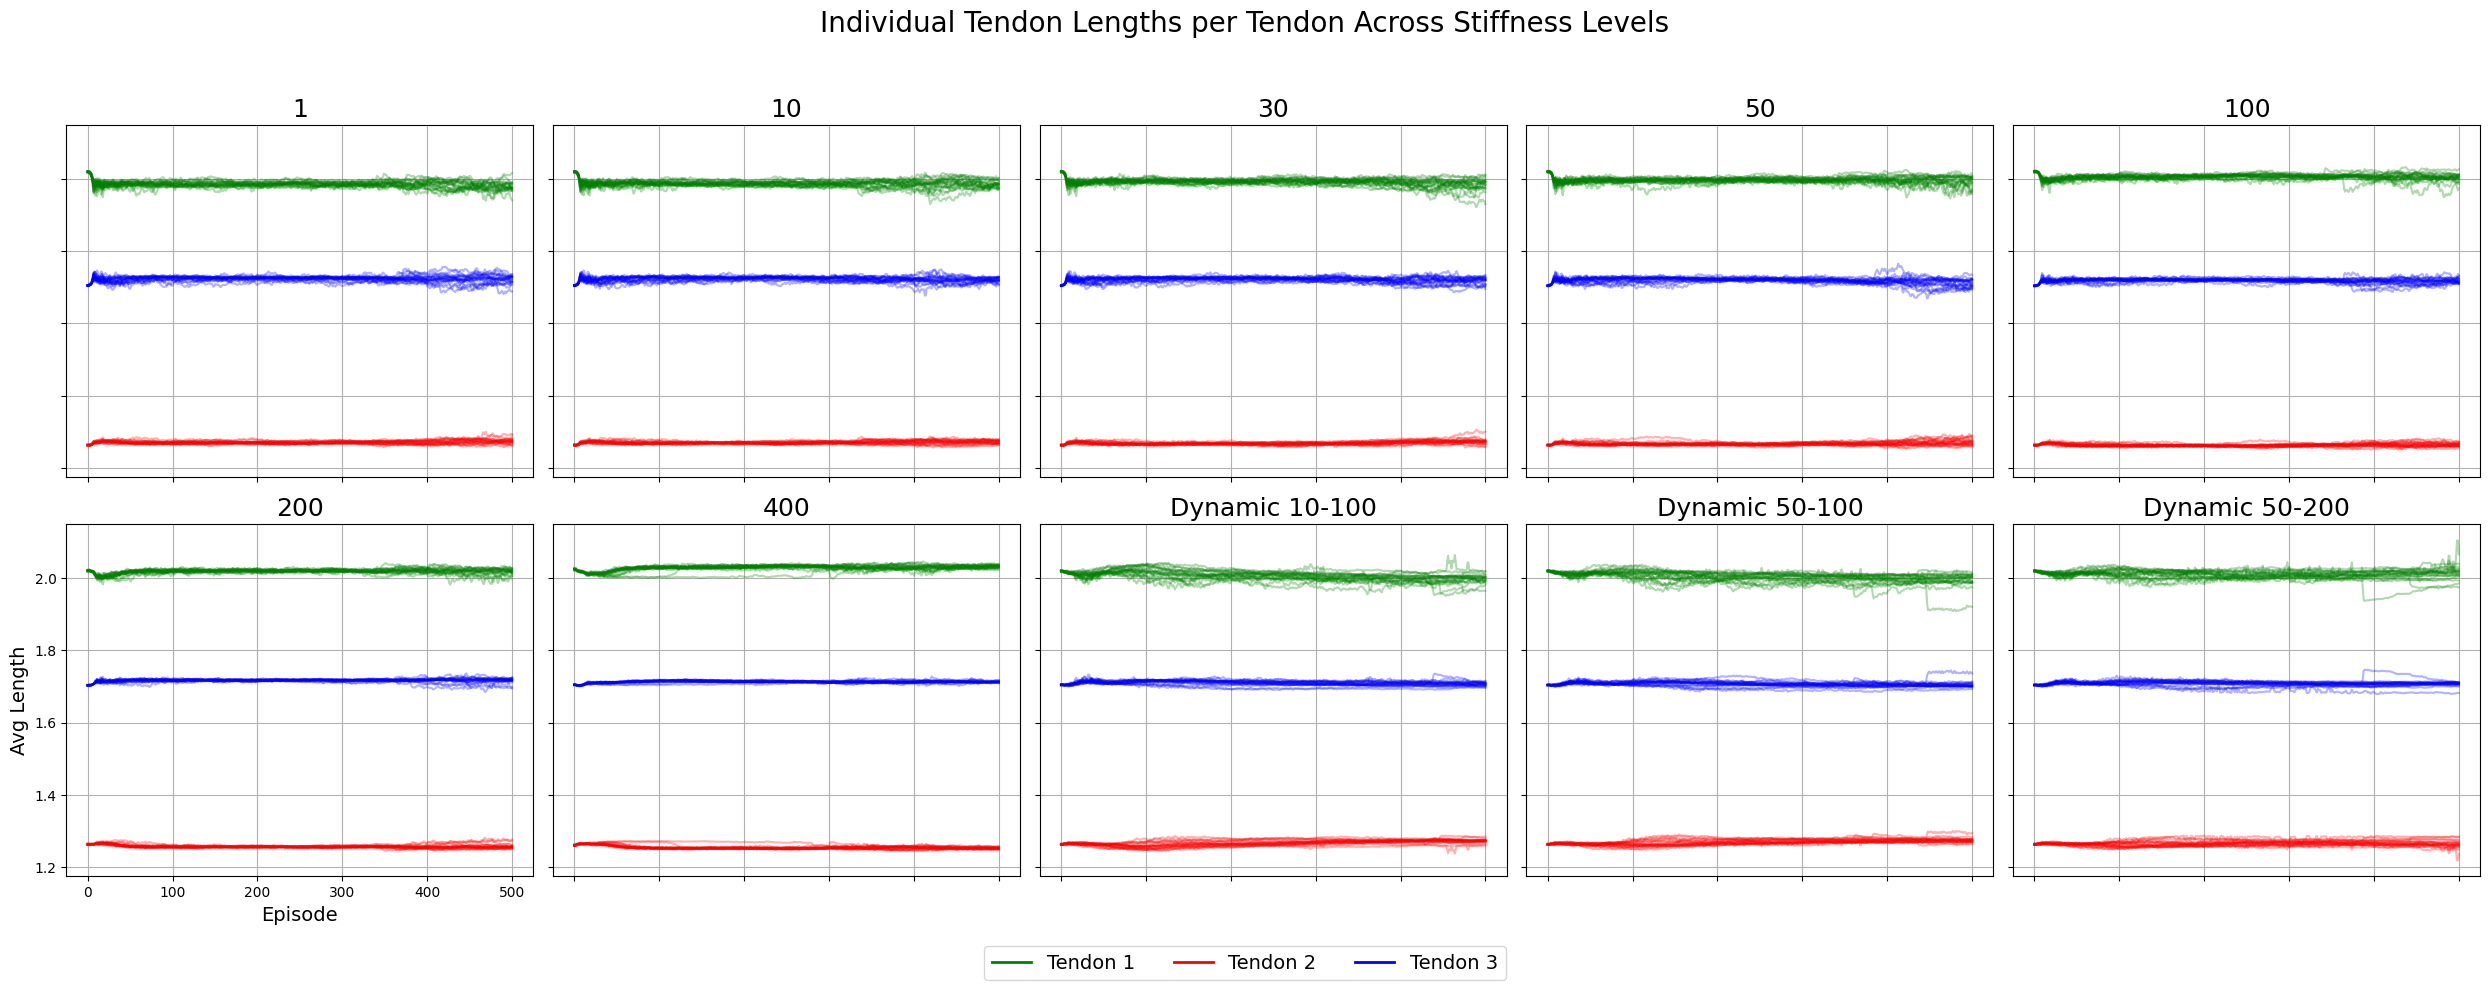

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25"


groups = {
     "Constant 1": fr"{folder_name}\LegEnv_Aug07_constant_1_lr_5e-04_PPO\tendon_lengths",
    # "Constant 5": fr"{folder_name}\LegEnv_Jul24_constant_5_lr_5e-04_PPO\displacements",

    "Constant 10": fr"{folder_name}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO\tendon_lengths",
     "Constant 30": fr"{folder_name}\LegEnv_Jul20_constant_3k_lr_5e-04_PPO\tendon_lengths",
    "Constant 50": fr"{folder_name}\LegEnv_Jul20_constant_5k_lr_5e-04_PPO\tendon_lengths",

    "Constant 100": fr"{folder_name}\LegEnv_Jul20_constant_10k_lr_5e-04_PPO\tendon_lengths",
    "Constant 200": fr"{folder_name}\LegEnv_Jul20_constant_20k_lr_5e-04_PPO\tendon_lengths",
    "Constant 400": fr"{folder_name}\LegEnv_Jul20_constant_40k_lr_5e-04_PPO\tendon_lengths",
   
    "Dynamic 10-100": fr"{folder_name}\LegEnv_Aug02_seeds_100-120_linear_10-100_lr_5e-04_PPO\tendon_lengths",
    "Dynamic 50-100": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO\tendon_lengths",
    "Dynamic 50-200": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-200_lr_5e-04_PPO\tendon_lengths",



}
group_seeds = {k: range(100, 120) for k in groups}


window_size = 2

# Set up 2x5 subplots
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=True, sharey=True)
axes = axes.flatten()
tendon_colors = ['green', 'red', 'blue']

for idx, (label, folder) in enumerate(groups.items()):
    seeds = group_seeds[label]
    all_seeds_data = []

    for seed in seeds:
        path = os.path.join(folder, f"tendon_length_seed_{seed}.npy")
        if os.path.exists(path):
            try:
                data = np.load(path, allow_pickle=True)  # shape: (episodes, timesteps, 3)
                data = np.asarray(data, dtype=np.float32)

                # Average over time steps → shape: (episodes, 3)
                episode_means = data.mean(axis=1)
                all_seeds_data.append(episode_means)
            except Exception as e:
                print(f"Error loading seed {seed} from {label}: {e}")
        else:
            print(f"Missing: {path}")

    ax = axes[idx]
    ax.set_title(label.replace("Constant ", ""), fontsize = 18)

   

    if all_seeds_data:
        min_len = min([d.shape[0] for d in all_seeds_data])
        all_seeds_data = [d[:min_len] for d in all_seeds_data]

        # Plot each seed individually
        for tendon_idx in range(3):
            for seed_data in all_seeds_data:
                tendon_values = seed_data[:, tendon_idx]
                tendon_values = moving_average(tendon_values, window_size)
                tendon_values = np.insert(tendon_values, 0, tendon_values[0])  # to match original length
                episodes = np.arange(len(tendon_values))
                ax.plot(episodes, tendon_values, color=tendon_colors[tendon_idx], alpha=0.3)

    ax.grid(True)
    if idx == 5:
        ax.set_xlabel("Episode", fontsize = 14)
        ax.set_ylabel("Avg Length", fontsize = 14)
        ax.tick_params(labelbottom=True, labelleft=True)
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(labelbottom=False, labelleft=False)
   


# Add legend with tendon colors (only once)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=tendon_colors[i], lw=2, label=f'Tendon {i+1}') for i in range(3)]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=14)
fig.suptitle("Individual Tendon Lengths per Tendon Across Stiffness Levels", fontsize=20)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("tendon_lengths_per_stiffness.png", dpi=700, bbox_inches='tight')
plt.show()


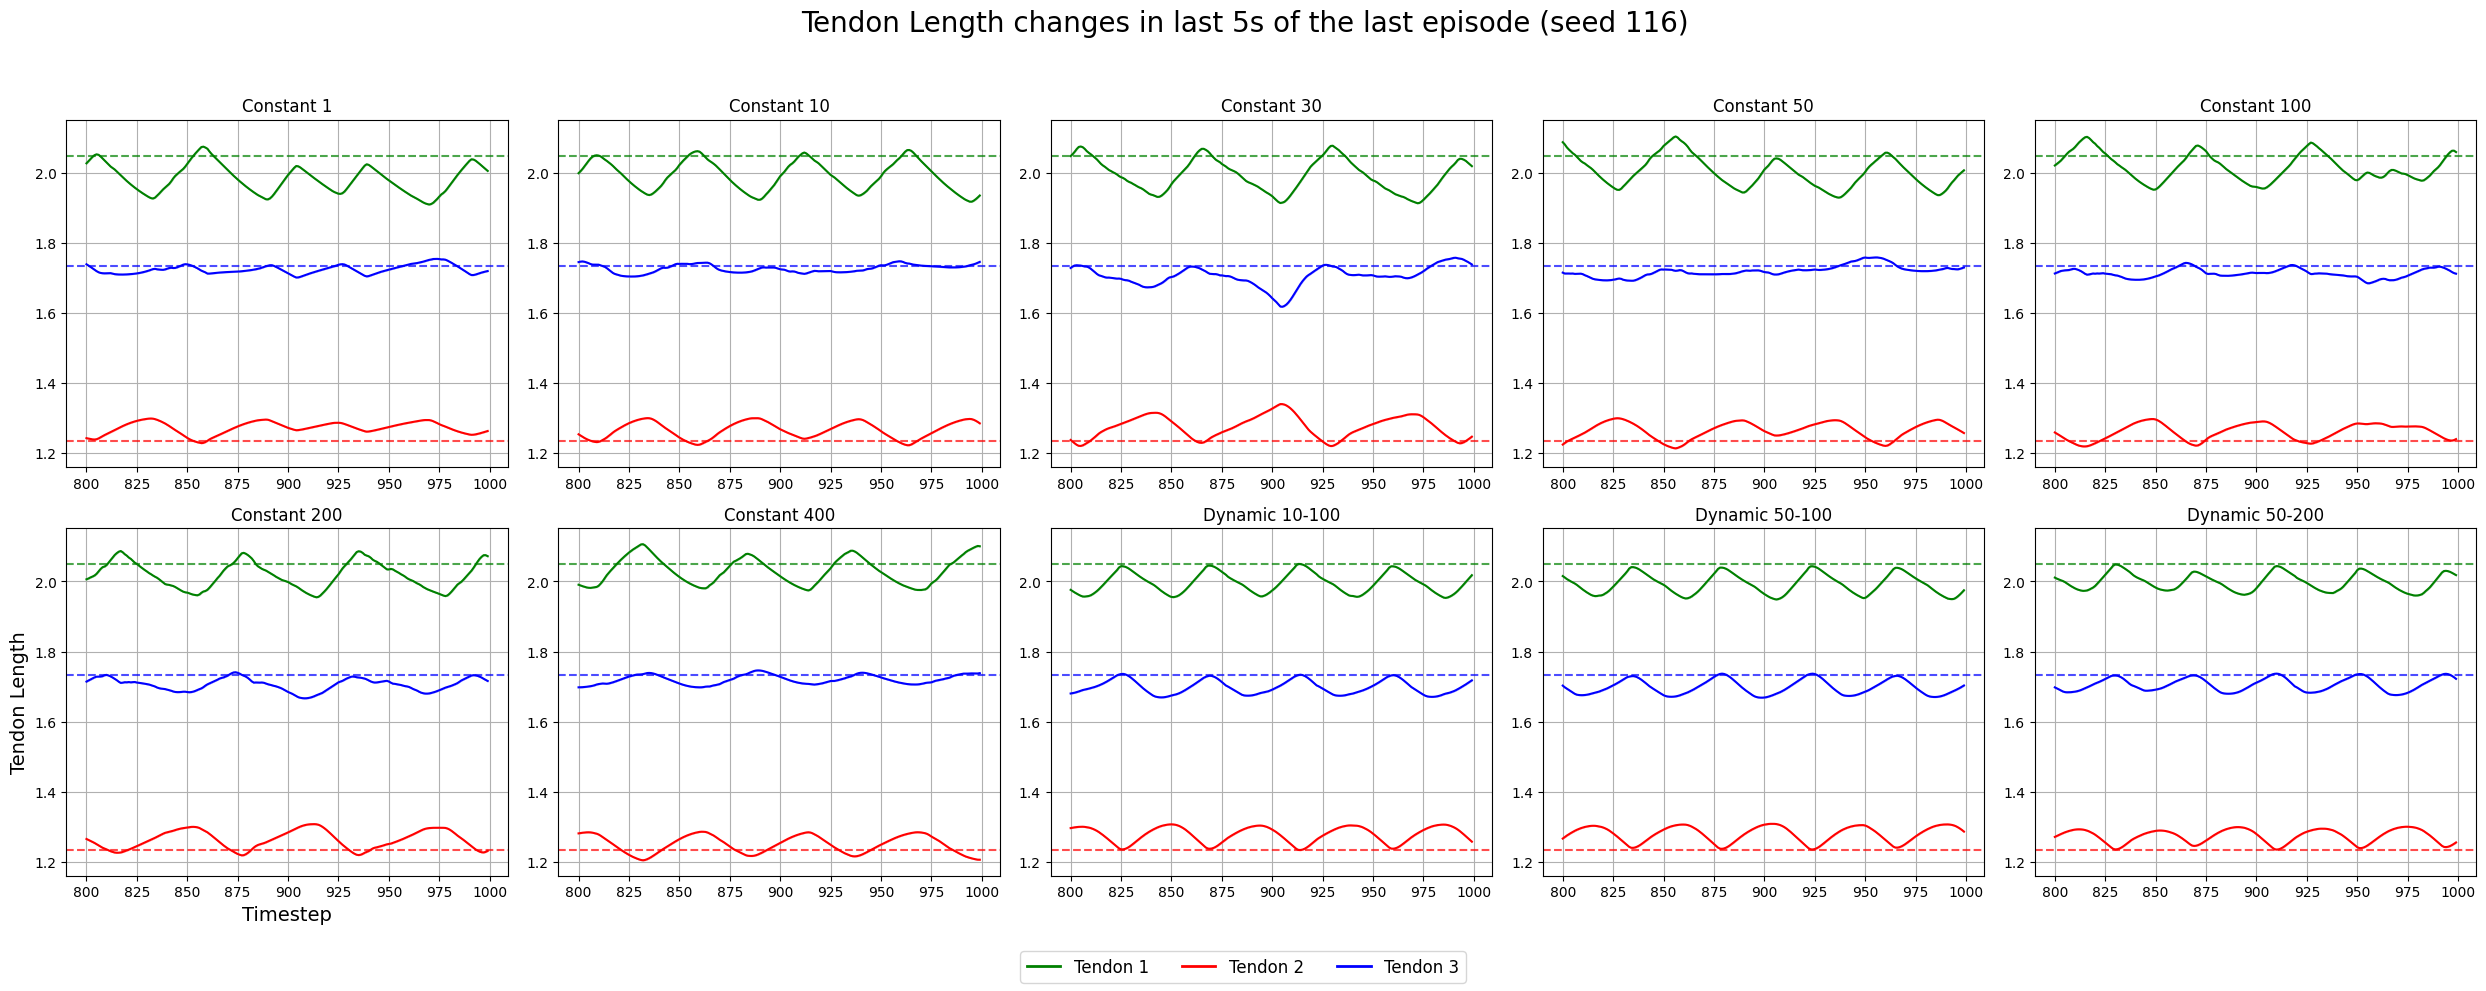

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25"


groups = {
    "Constant 1": fr"{folder_name}\LegEnv_Aug07_constant_1_lr_5e-04_PPO\tendon_lengths",
    # "Constant 5": fr"{folder_name}\LegEnv_Jul24_constant_5_lr_5e-04_PPO\displacements",

    "Constant 10": fr"{folder_name}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO\tendon_lengths",
    "Constant 30": fr"{folder_name}\LegEnv_Jul20_constant_3k_lr_5e-04_PPO\tendon_lengths",
    "Constant 50": fr"{folder_name}\LegEnv_Jul20_constant_5k_lr_5e-04_PPO\tendon_lengths",

    "Constant 100": fr"{folder_name}\LegEnv_Jul20_constant_10k_lr_5e-04_PPO\tendon_lengths",
    "Constant 200": fr"{folder_name}\LegEnv_Jul20_constant_20k_lr_5e-04_PPO\tendon_lengths",
    "Constant 400": fr"{folder_name}\LegEnv_Jul20_constant_40k_lr_5e-04_PPO\tendon_lengths",
   
    "Dynamic 10-100": fr"{folder_name}\LegEnv_Aug02_seeds_100-120_linear_10-100_lr_5e-04_PPO\tendon_lengths",
    "Dynamic 50-100": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO\tendon_lengths",
    "Dynamic 50-200": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-200_lr_5e-04_PPO\tendon_lengths",



}
seed_chosen = 116  # Fixed seed for all groups
group_seeds = {k: range(seed_chosen, seed_chosen+1) for k in groups}

# Plot setup
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=True, sharey=True)
axes = axes.flatten()
tendon_colors = ['green', 'red', 'blue']
horizontal_lines = [2.0486, 1.2341, 1.7341]  # Reference values per tendon

for idx, (label, folder) in enumerate(groups.items()):
    seeds = group_seeds[label]
    all_seeds_data = []

    for seed in seeds:
        path = os.path.join(folder, f"tendon_length_seed_{seed}.npy")
        if os.path.exists(path):
            try:
                data = np.load(path, allow_pickle=True)  # shape: (episodes, timesteps, 3)
                data = np.asarray(data, dtype=np.float32)
                last_episode = data[-1][800:]  # shape: (1000, 3)
                
                all_seeds_data.append(last_episode)
            except Exception as e:
                print(f"Error loading seed {seed} from {label}: {e}")
        else:
            print(f"Missing: {path}")

    ax = axes[idx]
    ax.set_title(label)

    if all_seeds_data:
        min_len = min(d.shape[0] for d in all_seeds_data)
        all_seeds_data = [d[:min_len] for d in all_seeds_data]
        group_array = np.stack(all_seeds_data, axis=0)  # (seeds, timesteps, 3)

        mean = group_array.mean(axis=0)  # (timesteps, 3)
        std = group_array.std(axis=0)
        steps = np.arange(min_len)+800

        for tendon_idx in range(3):
            tendon_mean = mean[:, tendon_idx]
            tendon_std = std[:, tendon_idx]

            ax.plot(steps, tendon_mean, label=f"Tendon {tendon_idx+1}", color=tendon_colors[tendon_idx])
            ax.fill_between(steps, tendon_mean - tendon_std, tendon_mean + tendon_std,
                            color=tendon_colors[tendon_idx], alpha=0.2)
            ax.axhline(y=horizontal_lines[tendon_idx], linestyle='--',
                       color=tendon_colors[tendon_idx], linewidth=1.5, alpha=0.7)

    ax.grid(True)
    if idx == 5:
        ax.set_ylabel("Tendon Length", fontsize=14)
        ax.set_xlabel("Timestep", fontsize=14)
    else:
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(labelbottom=True, labelleft=True)

        

# Final layout
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=tendon_colors[i], lw=2, label=f'Tendon {i+1}') for i in range(3)]
fig.legend(handles= legend_elements, loc='lower center', ncol=3, fontsize=12)
fig.suptitle(f"Tendon Length changes in last 5s of the last episode (seed {seed_chosen})", fontsize=20)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(f"tendon_lengths_last_episode_{seed_chosen}.png", dpi=700, bbox_inches='tight')
plt.show()


Missing: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\LegEnv_Aug07_constant_1_lr_5e-04_PPO\tendon_lengths\tendon_lengths_seed_100.npy
Missing: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\LegEnv_Aug07_constant_1_lr_5e-04_PPO\tendon_lengths\tendon_lengths_seed_101.npy
Missing: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\LegEnv_Aug07_constant_1_lr_5e-04_PPO\tendon_lengths\tendon_lengths_seed_102.npy
Missing: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\LegEnv_Aug07_constant_1_lr_5e-04_PPO\tendon_lengths\tendon_lengths_seed_103.npy
Missing: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\LegEnv_Aug07_constant_1_lr_5e-04_PPO\tendon_lengths\tendon_lengths_seed_104.npy
Missing: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\LegEnv_Aug07_constant_1_lr_5e-04_PPO\tendon_lengths\tendon_lengths_seed_105.npy
Missing: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\LegEnv_Aug07_constant_1_lr_5e-

IndexError: index 8 is out of bounds for axis 0 with size 8

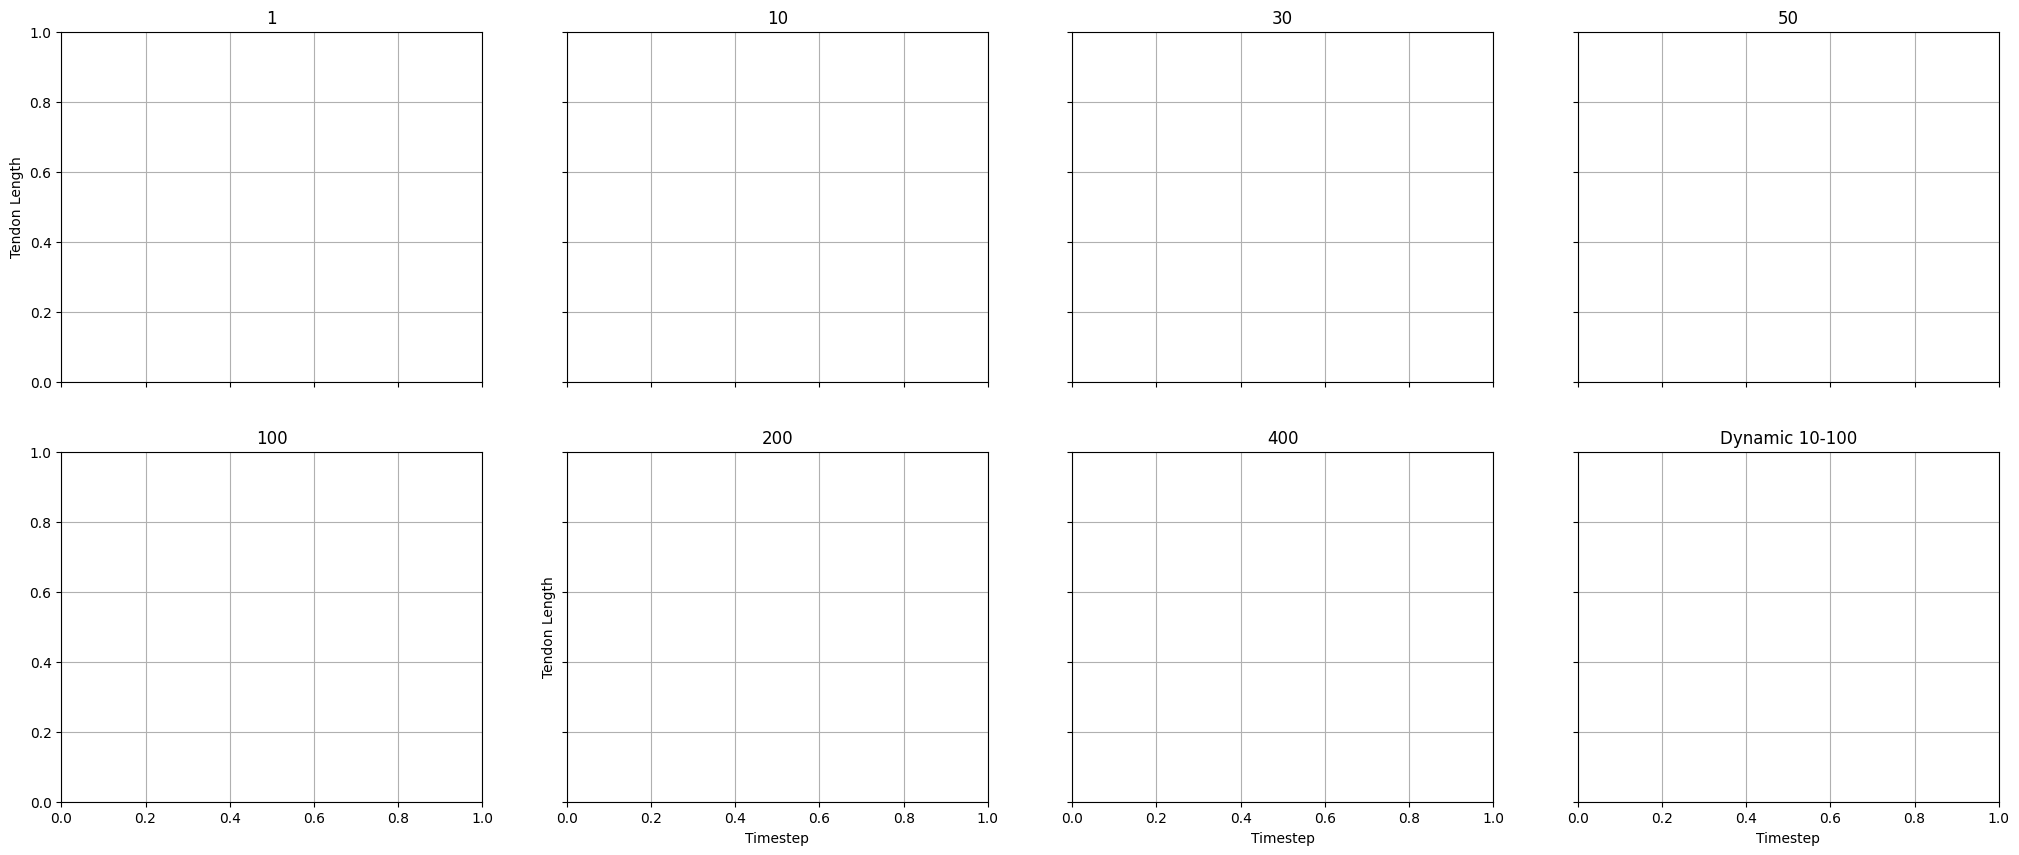

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

group_seeds = {k: range(100, 120) for k in groups}

window_size = 2
tendon_colors = ['green', 'red', 'blue']

# === Create Subplots ===
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (label, folder) in enumerate(groups.items()):
    seeds = group_seeds[label]
    ax = axes[idx]
    ax.set_title(label.replace("Constant ", ""))

    for seed in seeds:
        path = os.path.join(folder, f"tendon_lengths_seed_{seed}.npy")
        if os.path.exists(path):
            try:
                data = np.load(path, allow_pickle=True)  # shape: (episodes, timesteps, 3)
                data = np.asarray(data, dtype=np.float32)

                last_episode = data[-1]  # shape: (timesteps, 3)
                last_episode = last_episode[800:]
                timesteps = np.arange(last_episode.shape[0])

                for i in range(3):  # for each tendon
                    values = moving_average(last_episode[:, i], window_size)
                    values = np.insert(values, 0, values[0])  # pad to match length
                    ax.plot(timesteps, values, color=tendon_colors[i], alpha=0.3)

            except Exception as e:
                print(f"Error loading seed {seed} from {label}: {e}")
        else:
            print(f"Missing: {path}")

    ax.grid(True)
    if idx % 5 == 0:
        ax.set_ylabel("Tendon Length")
    if idx >= 5:
        ax.set_xlabel("Timestep")

# === Legend & Title ===
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=tendon_colors[i], lw=2, label=f'Tendon {i+1}') for i in range(3)]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12)
fig.suptitle("Tendon Lengths During Last Episode by Stiffness Level", fontsize=18)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuration
folder = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\Dynamic-tendon-Leg\JJ\data\LegEnv_Jun23_constant_0.3k_lr_5e-04_PPO_seeds_106-106"
seed_range = range(106, 107)  # 20 seeds: 100 to 119

all_episode_means = []

for seed in seed_range:
    force_path = os.path.join(folder, f'actuator_forces/actuator_forces_seed_{seed}.npy')
    if not os.path.exists(force_path):
        print(f"Missing file for seed {seed}: {force_path}")
        continue

    episodes = np.load(force_path, allow_pickle=True)
    
    # Ensure each episode is converted to proper float arrays
    try:
        episode_means = np.array([
            np.mean(np.array(ep, dtype=np.float32), axis=0) for ep in episodes
        ])
        all_episode_means.append(episode_means)
    except Exception as e:
        print(f"Error processing seed {seed}: {e}")

# Make sure we have valid seeds
if not all_episode_means:
    raise RuntimeError("No valid episode data loaded.")

# Align episode lengths
min_episodes = min([ep.shape[0] for ep in all_episode_means])
all_episode_means = np.array([ep[:min_episodes] for ep in all_episode_means], dtype=np.float32)

# Compute mean and std
mean_across_seeds = np.mean(all_episode_means, axis=0)
std_across_seeds = np.std(all_episode_means, axis=0)

# Plot
episodes = np.arange(min_episodes)
plt.figure(figsize=(10, 5))

muscle_labels = ['M0', 'M1', 'M2']
colors = ['green', 'red', 'blue']

for i in range(3):
    plt.plot(episodes, mean_across_seeds[:, i], label=f'{muscle_labels[i]} (mean)', color=colors[i])
    plt.fill_between(
        episodes,
        mean_across_seeds[:, i] - std_across_seeds[:, i],
        mean_across_seeds[:, i] + std_across_seeds[:, i],
        color=colors[i],
        alpha=0.3,
        #label=f'{muscle_labels[i]} ±1 SD'
    )

plt.xlabel("Episode")
plt.ylabel("Average Muscle Force (N)")
plt.title("Average Muscle Force per Episode (Mean ± SD over 20 Seeds)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\Dynamic-tendon-Leg\JJ\data"

# groups = {
#     '10' : fr"{folder_name}\LegEnv_Jul10_constant_1k_lr_5e-04_PPO\tendon_forces",
#     '20':  fr"{folder_name}\LegEnv_Jul10_constant_2k_lr_5e-04_PPO\tendon_forces",
#     '30':  fr"{folder_name}\LegEnv_Jul10_constant_3k_lr_5e-04_PPO\tendon_forces",
#     '40':  fr"{folder_name}\LegEnv_Jul10_constant_4k_lr_5e-04_PPO\tendon_forces",
#     '50': fr"{folder_name}\LegEnv_Jul10_constant_5k_lr_5e-04_PPO\tendon_forces", 
#     '60': fr"{folder_name}\LegEnv_Jul10_constant_6k_lr_5e-04_PPO\tendon_forces", 
    
#     '100': fr"{folder_name}\LegEnv_Jul10_constant_10k_lr_5e-04_PPO\tendon_forces",
#     '200': fr"{folder_name}\LegEnv_Jul10_constant_20k_lr_5e-04_PPO\tendon_forces",
#     '300': fr"{folder_name}\LegEnv_Jul10_constant_30k_lr_5e-04_PPO\tendon_forces",
#     '400': fr"{folder_name}\LegEnv_Jul10_constant_40k_lr_5e-04_PPO\tendon_forces",
#     '500': fr"{folder_name}\LegEnv_Jul10_constant_50k_lr_5e-04_PPO\tendon_forces",

}
group_seeds = {k: range(100, 110) for k in groups}
window_size = 2

# Set up 2x5 subplots
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=True, sharey=True)
axes = axes.flatten()
tendon_colors = [ 'green', 'red', 'blue']

for idx, (label, folder) in enumerate(groups.items()):
    seeds = group_seeds[label]
    all_seeds_data = []

    for seed in seeds:
        path = os.path.join(folder, f"tendon_force_seed_{seed}.npy")
        if os.path.exists(path):
            try:
                data = np.load(path, allow_pickle=True)  # shape: (episodes, timesteps, 3)
                data = np.asarray(data, dtype=np.float32)

                # Avg over time (axis=1), keep 3 tendons → shape: (episodes, 3)
                episode_means = data.mean(axis=1)
                all_seeds_data.append(episode_means)
            except Exception as e:
                print(f"Error loading seed {seed} from {label}: {e}")
        else:
            print(f"Missing: {path}")

    ax = axes[idx]
    ax.set_title(label)

    if all_seeds_data:
        min_len = min([d.shape[0] for d in all_seeds_data])
        all_seeds_data = [d[:min_len] for d in all_seeds_data]
        group_array = np.stack(all_seeds_data, axis=0)  # shape: (seeds, episodes, 3)

        mean = group_array.mean(axis=0)  # shape: (episodes, 3)
        std = group_array.std(axis=0)

        # Apply smoothing to each tendon
        for tendon_idx in range(3):
            tendon_mean = moving_average(mean[:, tendon_idx], window_size)
            tendon_std = moving_average(std[:, tendon_idx], window_size)

            tendon_mean = np.insert(tendon_mean, 0, tendon_mean[0])
            tendon_std = np.insert(tendon_std, 0, tendon_std[0])
            episodes = np.arange(len(tendon_mean))

            ax.plot(episodes, tendon_mean, label=f"Tendon {tendon_idx+1}", color=tendon_colors[tendon_idx])
            ax.fill_between(episodes, tendon_mean - tendon_std, tendon_mean + tendon_std,
                            color=tendon_colors[tendon_idx], alpha=0.2)

    ax.grid(True)
    if idx % 5 == 0:
        ax.set_ylabel("Avg Force")
    if idx >= 5:
        ax.set_xlabel("Episode")

# Final formatting
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12)
fig.suptitle("Average Muscle Force per Tendon Across Stiffness Levels", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

SyntaxError: unmatched '}' (3032858526.py, line 21)

In [2]:
######### ACTIVE TENDON FORCE
import numpy as np
import matplotlib.pyplot as plt
import os

# Moving average function
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\Dynamic-tendon-Leg\JJ\data"

groups = {
    '10' : fr"{folder_name}\LegEnv_Jul10_constant_1k_lr_5e-04_PPO\tendon_forces",
    '20':  fr"{folder_name}\LegEnv_Jul10_constant_2k_lr_5e-04_PPO\tendon_forces",
    '30':  fr"{folder_name}\LegEnv_Jul10_constant_3k_lr_5e-04_PPO\tendon_forces",
    '40':  fr"{folder_name}\LegEnv_Jul10_constant_4k_lr_5e-04_PPO\tendon_forces",
    '50': fr"{folder_name}\LegEnv_Jul10_constant_5k_lr_5e-04_PPO\tendon_forces", 
    '60': fr"{folder_name}\LegEnv_Jul10_constant_6k_lr_5e-04_PPO\tendon_forces", 
    
    '100': fr"{folder_name}\LegEnv_Jul10_constant_10k_lr_5e-04_PPO\tendon_forces",
    '200': fr"{folder_name}\LegEnv_Jul10_constant_20k_lr_5e-04_PPO\tendon_forces",
    '300': fr"{folder_name}\LegEnv_Jul10_constant_30k_lr_5e-04_PPO\tendon_forces",
    '400': fr"{folder_name}\LegEnv_Jul10_constant_40k_lr_5e-04_PPO\tendon_forces",
    '500': fr"{folder_name}\LegEnv_Jul10_constant_50k_lr_5e-04_PPO\tendon_forces",
}
group_seeds = {k: range(100, 110) for k in groups}
window_size = 1
tendon_colors = ['green', 'red', 'blue']

# Create 2x5 subplots (change this if you have more groups)
fig, axes = plt.subplots(2, 5, figsize=(25, 7), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (stiffness, folder) in enumerate(groups.items()):
    ax = axes[idx]
    ax.set_title(f"Stiffness: {stiffness}")
    seeds = group_seeds[stiffness]
    tendon_data_by_seed = []

    for seed in seeds:
        file_path = os.path.join(folder, f"tendon_force_seed_{seed}.npy")
        if not os.path.exists(file_path):
            print(f"Missing: {file_path}")
            continue

        try:
            tendon_data = np.load(file_path, allow_pickle=True)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
            continue

        if len(tendon_data) == 0:
            print(f"No episodes in {file_path}")
            continue

        last_episode = tendon_data[-1]  # list of timesteps
     
        last_episode = last_episode[-100:]  # take only the last 100 steps

        num_tendons = 3
        tendon_arrays = {i: [] for i in range(num_tendons)}

        for timestep in last_episode:
            for entry in timestep:
                tid = entry['tendon_id']
                tendon_arrays[tid].append(entry['active'])  # Use only active force

        # Convert to array
        tendon_matrix = []
        for tid in range(num_tendons):
            tendon_matrix.append(tendon_arrays[tid])
        tendon_matrix = np.array(tendon_matrix).T  # shape: (timesteps, 3)

        tendon_data_by_seed.append(tendon_matrix)

    if not tendon_data_by_seed:
        continue

    # Normalize all to same timesteps
    min_len = min([d.shape[0] for d in tendon_data_by_seed])
    tendon_data_by_seed = [d[:min_len] for d in tendon_data_by_seed]
    stacked = np.stack(tendon_data_by_seed, axis=0)  # shape: (seeds, timesteps, 3)

    mean = stacked.mean(axis=0)  # (timesteps, 3)
    std = stacked.std(axis=0)    # (timesteps, 3)

    for tid in range(3):
        mean_smoothed = moving_average(mean[:, tid], window_size)
        std_smoothed = moving_average(std[:, tid], window_size)

        # Align time steps
        mean_smoothed = np.insert(mean_smoothed, 0, mean_smoothed[0])
        std_smoothed = np.insert(std_smoothed, 0, std_smoothed[0])
        t = np.arange(len(mean_smoothed))

        ax.plot(t, mean_smoothed, label=f"Tendon {tid+1}", color=tendon_colors[tid])
        ax.fill_between(t, mean_smoothed - std_smoothed, mean_smoothed + std_smoothed,
                        color=tendon_colors[tid], alpha=0.2)

    ax.grid(True)
    if idx % 5 == 0:
        ax.set_ylabel("Active Force")
    if idx >= 5:
        ax.set_xlabel("Timestep")

# Legend and title
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12)
fig.suptitle("Active Tendon Force Over Time Across Stiffness Levels", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


: 

C:\Users\User\AppData\Local\Temp\ipykernel_4128\1140020406.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 0.95])  #


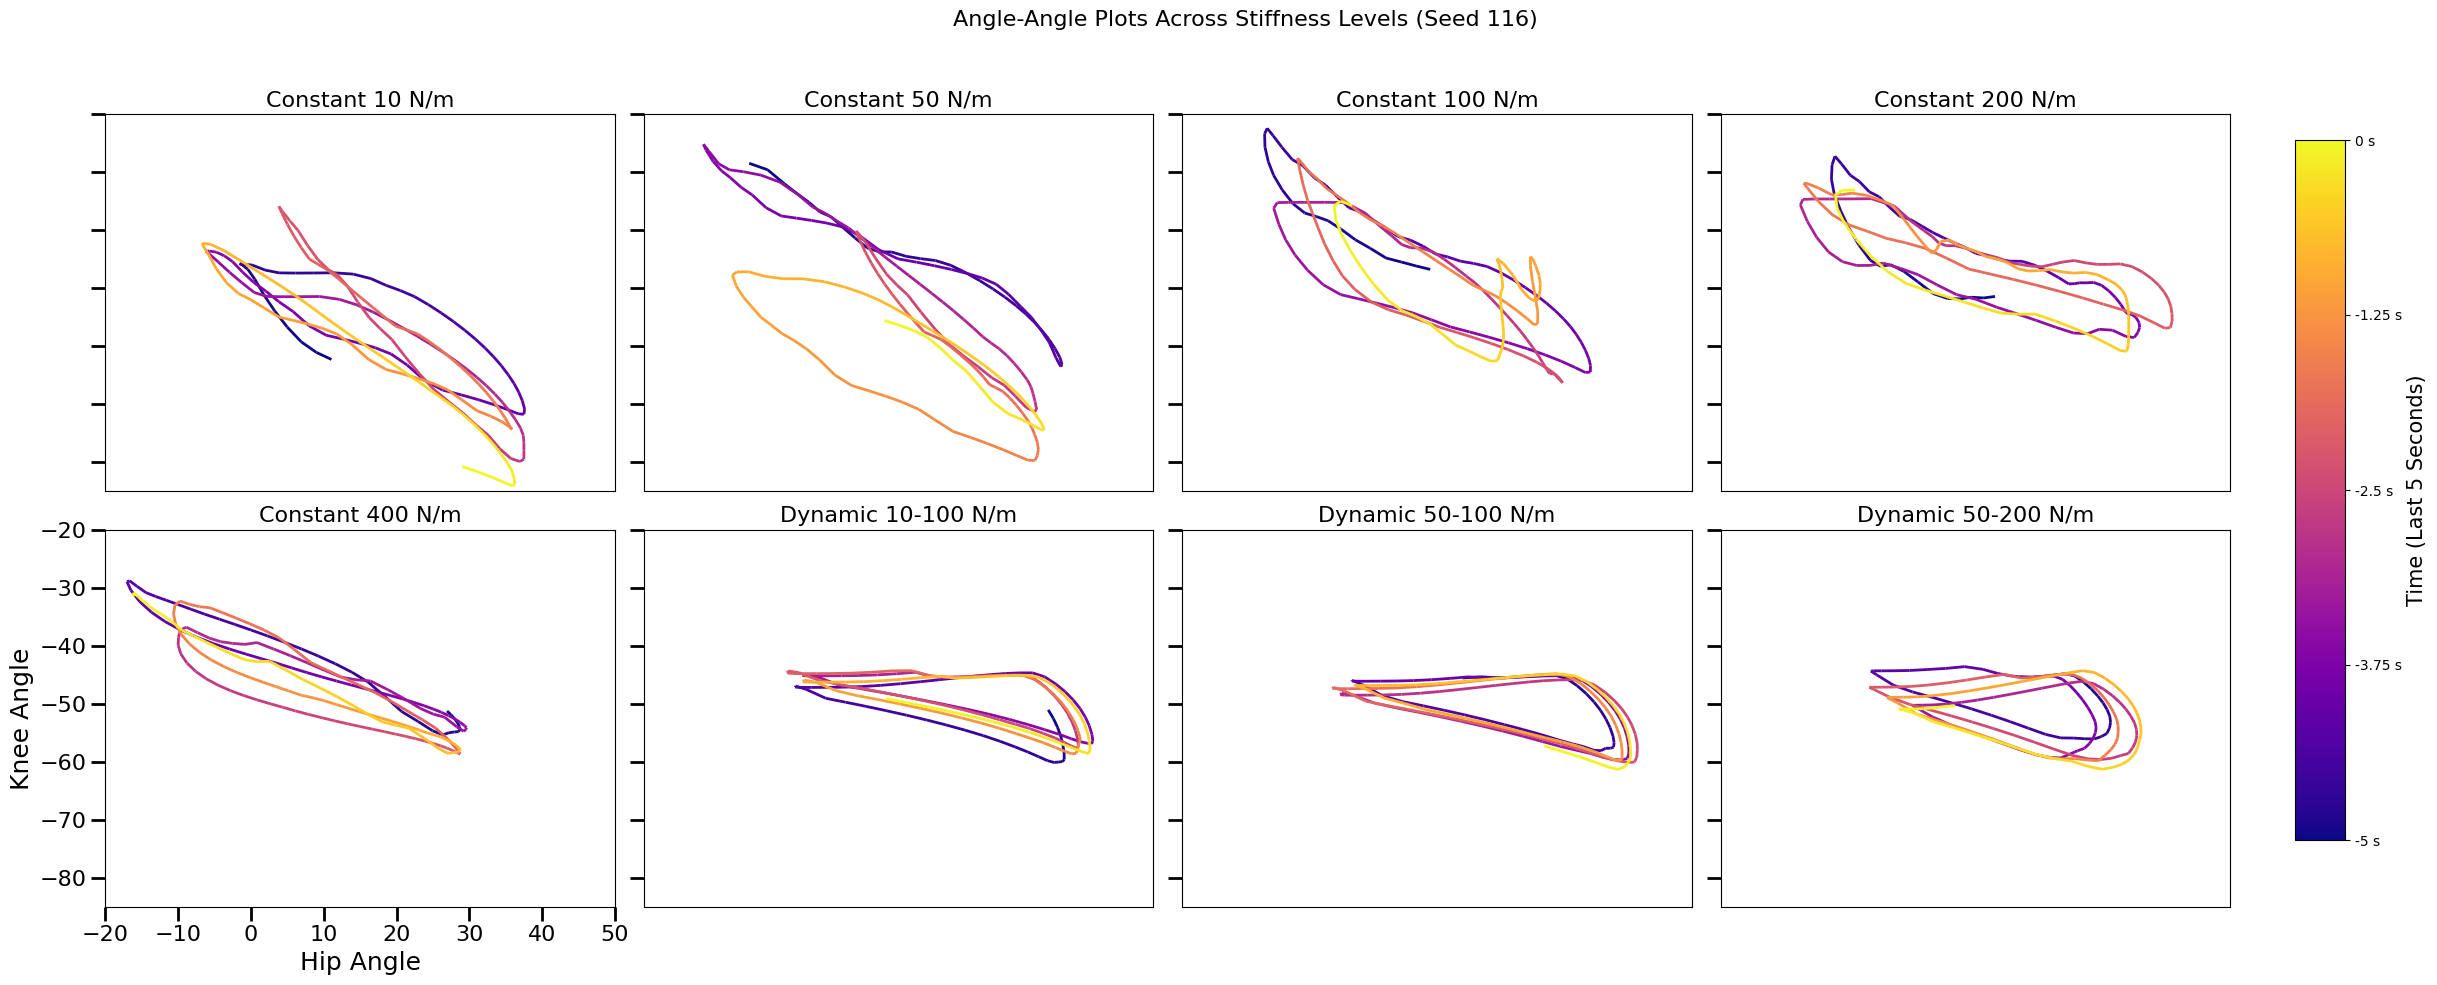

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import cm
import os

folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25"

# ----------- ORDERED & GROUPED STIFFNESS DICTIONARY ------------
stiffness_folders = {
    "Constant 10": fr"{folder_name}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO",
    "Constant 50": fr"{folder_name}\LegEnv_Jul20_constant_5k_lr_5e-04_PPO",
    "Constant 100": fr"{folder_name}\LegEnv_Jul20_constant_10k_lr_5e-04_PPO",
    "Constant 200": fr"{folder_name}\LegEnv_Jul20_constant_20k_lr_5e-04_PPO",
    "Constant 400": fr"{folder_name}\LegEnv_Jul20_constant_40k_lr_5e-04_PPO",

    "Dynamic 10-100": fr"{folder_name}\LegEnv_Aug02_seeds_100-120_linear_10-100_lr_5e-04_PPO",
    "Dynamic 50-100": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO",
    "Dynamic 50-200": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-200_lr_5e-04_PPO",
}

chosen_seed = 116

# Create subplots
fig, axes = plt.subplots(2, 4, figsize=(25, 10))
axes = axes.flatten()
# After axes = axes.flatten()
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=16, length=10, width=2)



for i, (stiffness, folder) in enumerate(stiffness_folders.items()):
    qpos_path = os.path.join(folder, f'kinematics/qpos_seed_{chosen_seed}.npy')
    if not os.path.exists(qpos_path):
        print(f"Missing: {qpos_path}")
        continue

    qpos_data = np.load(qpos_path, allow_pickle=True)
    full_episode = np.array([np.array(x, dtype=np.float32) for x in qpos_data[-1]])
    last_qpos = np.stack(full_episode[800:])  # Last 5 seconds if dt=0.001 and frame_skip=25

    hip_angles = np.degrees(last_qpos[:, 1])
    knee_angles = np.degrees(last_qpos[:, 2])

    points = np.array([hip_angles, knee_angles]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    time_steps = np.linspace(0, 1, len(segments))
    colors = cm.plasma(time_steps)
    lc = LineCollection(segments, colors=colors, linewidth=2)

    ax = axes[i]
    ax.add_collection(lc)
    ax.set_xlim(-20, 50)
    ax.set_ylim(-85, -20)
    ax.grid(True, linestyle='--', alpha=0.5)

    # ax.set_xticks(np.linspace(-60, 80, 6))
    # ax.set_yticks(np.linspace(-80, -20, 7))

    if i == 4:  # Bottom-left corner (2nd row, 1st column in 2x4 grid)
        ax.set_xlabel("Hip Angle", fontsize=18)
        ax.set_ylabel("Knee Angle", fontsize=18)
        ax.tick_params(labelbottom=True, labelleft=True)
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks([])
        ax.tick_params(labelbottom=False, labelleft=False)


    ax.set_title(f"{stiffness} N/m", fontsize=16)

# Set common title
plt.suptitle(f"Angle-Angle Plots Across Stiffness Levels (Seed {chosen_seed})", fontsize=16)

# Colorbar: updated label
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
mappable = cm.ScalarMappable(cmap='plasma')
mappable.set_array(np.linspace(0, 1, 100))

fig.colorbar(mappable, cax=cbar_ax, label="Last 5 Seconds (Normalized Time)")




fig.tight_layout(rect=[0, 0, 0.9, 0.95])  #
# Customize colorbar ticks to show seconds instead of 0–1
tick_locs = [0.0, 0.25, 0.5, 0.75, 1.0]
tick_labels = ["-5 s", "-3.75 s", "-2.5 s", "-1.25 s", "0 s"]
cbar = fig.colorbar(mappable, cax=cbar_ax)
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels)

cbar.set_label("Time (Last 5 Seconds)", fontsize  = 15)
plt.savefig(rf"angle_angle_plots_{chosen_seed}.png", dpi=700, bbox_inches='tight')

# plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_4472\1175945807.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


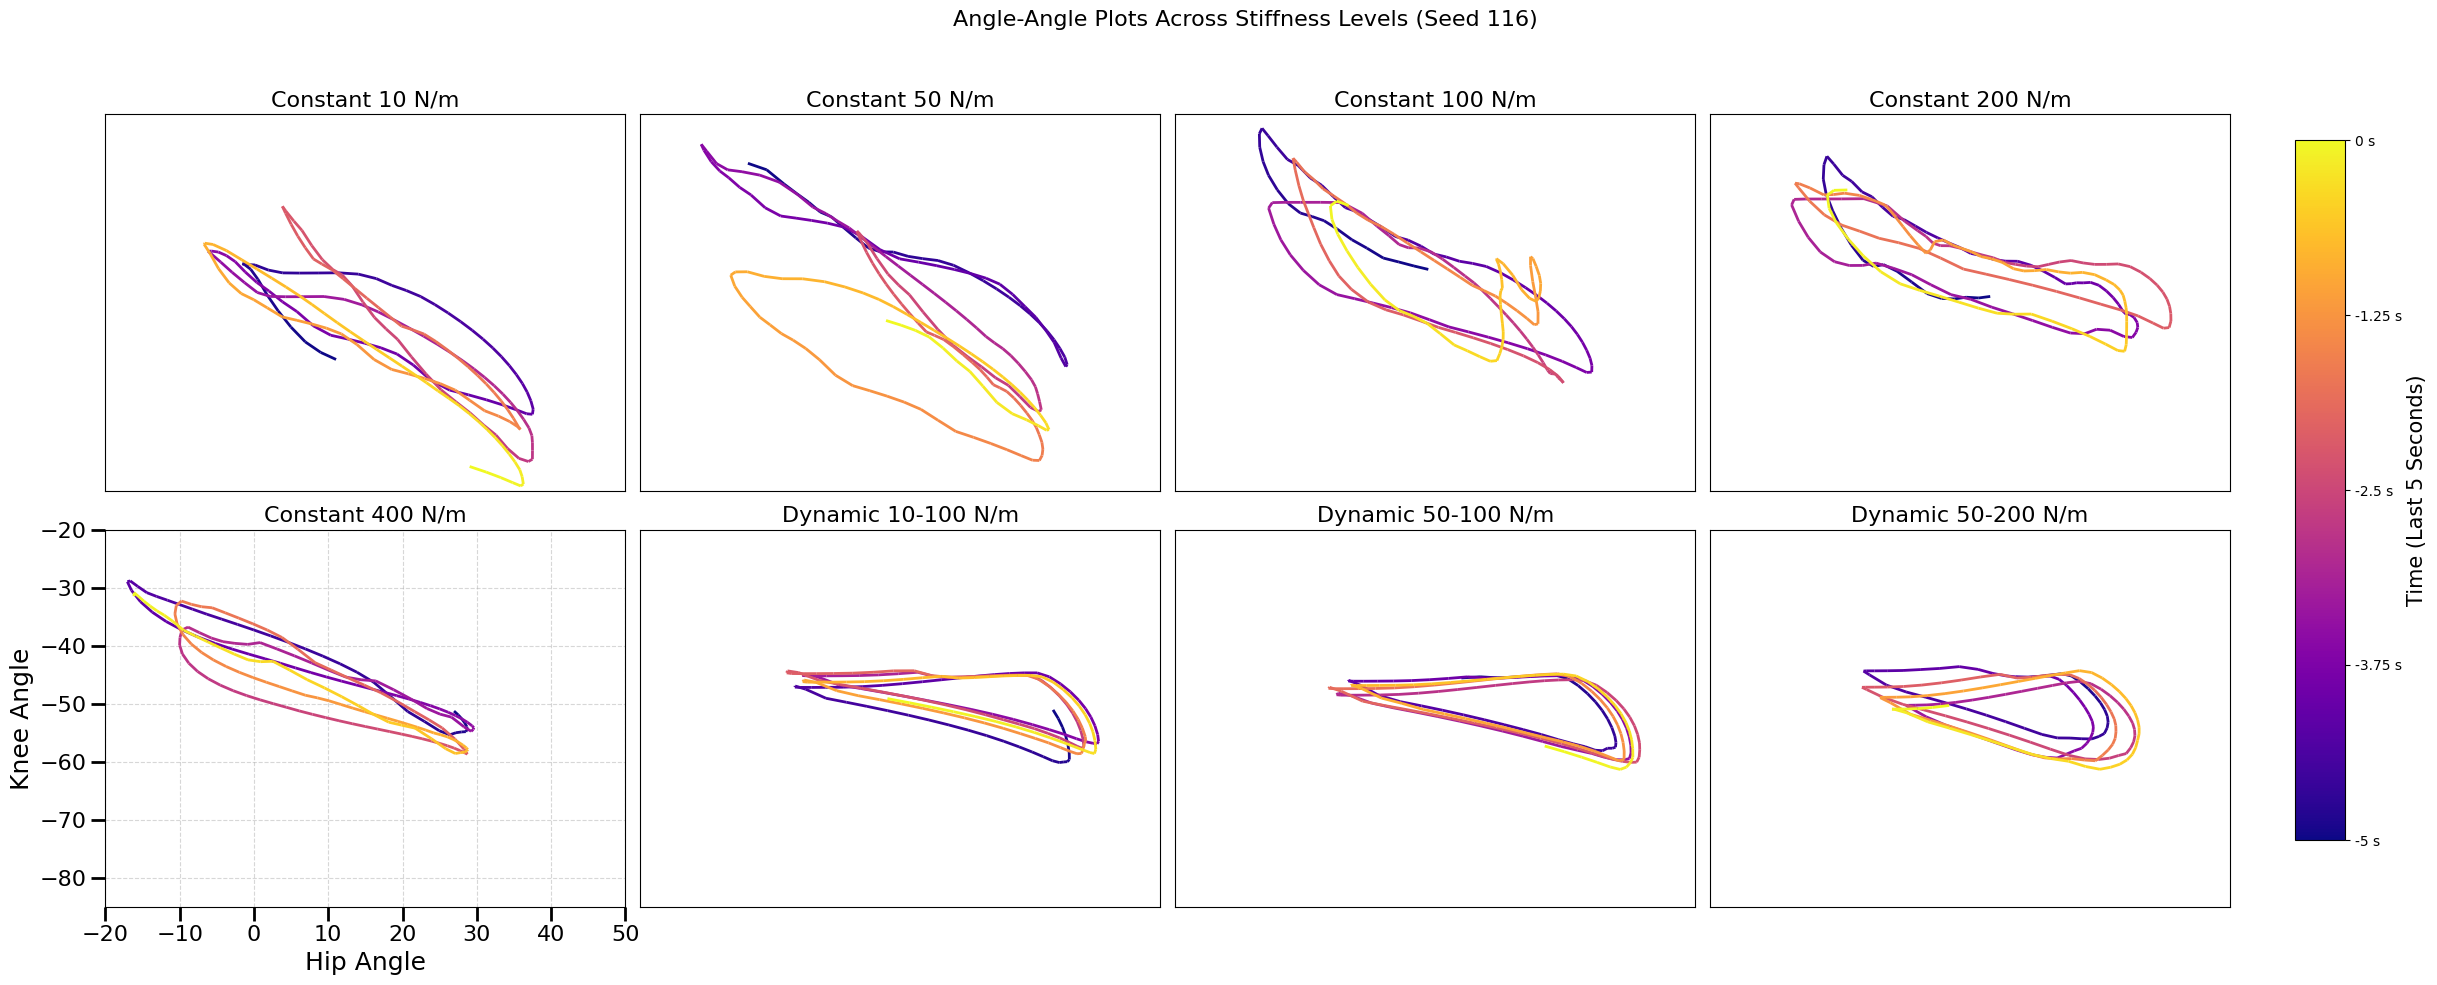

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import cm
import os

folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25"

stiffness_folders = {
    "Constant 10": fr"{folder_name}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO",
    "Constant 50": fr"{folder_name}\LegEnv_Jul20_constant_5k_lr_5e-04_PPO",
    "Constant 100": fr"{folder_name}\LegEnv_Jul20_constant_10k_lr_5e-04_PPO",
    "Constant 200": fr"{folder_name}\LegEnv_Jul20_constant_20k_lr_5e-04_PPO",
    "Constant 400": fr"{folder_name}\LegEnv_Jul20_constant_40k_lr_5e-04_PPO",

    "Dynamic 10-100": fr"{folder_name}\LegEnv_Aug02_seeds_100-120_linear_10-100_lr_5e-04_PPO",
    "Dynamic 50-100": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO",
    "Dynamic 50-200": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-200_lr_5e-04_PPO",
}

chosen_seed = 116

# Create subplots
fig, axes = plt.subplots(2, 4, figsize=(25, 10))
axes = axes.flatten()

# Define fixed axis limits
x_limits = (-20, 50)
y_limits = (-85, -20)

# Set up all axes: limits, grid, ticks
for i, ax in enumerate(axes):
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=16, length=10, width=2)
    ax.autoscale(enable=False)  # Important: prevent autoscaling from hiding grid

for i, (stiffness, folder) in enumerate(stiffness_folders.items()):
    ax = axes[i]

    qpos_path = os.path.join(folder, f'kinematics/qpos_seed_{chosen_seed}.npy')
    if not os.path.exists(qpos_path):
        print(f"Missing: {qpos_path}")
        continue

    qpos_data = np.load(qpos_path, allow_pickle=True)
    full_episode = np.array([np.array(x, dtype=np.float32) for x in qpos_data[-1]])
    last_qpos = np.stack(full_episode[800:])

    hip_angles = np.degrees(last_qpos[:, 1])
    knee_angles = np.degrees(last_qpos[:, 2])

    points = np.array([hip_angles, knee_angles]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    time_steps = np.linspace(0, 1, len(segments))
    colors = cm.plasma(time_steps)
    lc = LineCollection(segments, colors=colors, linewidth=2)
    ax.add_collection(lc)

    # Only bottom-left subplot has labels
    if i == 4:  # 2nd row, 1st column
        ax.set_xlabel("Hip Angle", fontsize=18)
        ax.set_ylabel("Knee Angle", fontsize=18)
        ax.tick_params(labelbottom=True, labelleft=True)
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.tick_params(labelbottom=False, labelleft=False)

    ax.set_title(f"{stiffness} N/m", fontsize=16)

# Common title
plt.suptitle(f"Angle-Angle Plots Across Stiffness Levels (Seed {chosen_seed})", fontsize=16)

# Colorbar
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
mappable = cm.ScalarMappable(cmap='plasma')
mappable.set_array(np.linspace(0, 1, 100))
cbar = fig.colorbar(mappable, cax=cbar_ax)
tick_locs = [0.0, 0.25, 0.5, 0.75, 1.0]
tick_labels = ["-5 s", "-3.75 s", "-2.5 s", "-1.25 s", "0 s"]
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels)
cbar.set_label("Time (Last 5 Seconds)", fontsize=15)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.savefig(rf"angle_angle_plots_{chosen_seed}.png", dpi=700, bbox_inches='tight')
# plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import cm
import matplotlib.animation as animation
import os

folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25"

stiffness_folders = {
    "Constant 10": fr"{folder_name}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO",
    "Constant 50": fr"{folder_name}\LegEnv_Jul20_constant_5k_lr_5e-04_PPO",
    "Constant 100": fr"{folder_name}\LegEnv_Jul20_constant_10k_lr_5e-04_PPO",
    "Constant 200": fr"{folder_name}\LegEnv_Jul20_constant_20k_lr_5e-04_PPO",
    "Constant 400": fr"{folder_name}\LegEnv_Jul20_constant_40k_lr_5e-04_PPO",
    "Dynamic 10-100": fr"{folder_name}\LegEnv_Aug02_seeds_100-120_linear_10-100_lr_5e-04_PPO",
    "Dynamic 50-100": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO",
    "Dynamic 50-200": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-200_lr_5e-04_PPO",
}

chosen_seed = 116
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
line_collections = []
segment_data = []

for i, (stiffness, folder) in enumerate(sorted(stiffness_folders.items())):
    qpos_path = os.path.join(folder, f'kinematics/qpos_seed_{chosen_seed}.npy')
    if not os.path.exists(qpos_path):
        print(f"Missing: {qpos_path}")
        continue

    qpos_data = np.load(qpos_path, allow_pickle=True)
    last_qpos = np.array([np.array(x, dtype=np.float32) for x in qpos_data[-1]])
    last_qpos = np.stack(last_qpos[800:])  # Last 5 seconds

    hip_angles = np.degrees(last_qpos[:, 1])
    knee_angles = np.degrees(last_qpos[:, 2])

    points = np.array([hip_angles, knee_angles]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    time_steps = np.linspace(0, 1, len(segments))
    colors = cm.plasma(time_steps)

    lc = LineCollection(segments[:1], colors=colors[:1], linewidth=2)
    ax = axes[i]
    ax.add_collection(lc)
    ax.set_xlim(-60, 80)
    ax.set_ylim(-100, 20)
    ax.set_xticks(np.linspace(-60, 80, 6))
    ax.set_yticks(np.linspace(-100, 20, 7))
    ax.set_title(f"{stiffness} N/m")
    ax.set_xlabel("Hip Angle")
    ax.set_ylabel("Knee Angle")

    line_collections.append(lc)
    segment_data.append((segments, colors))

# ============ Animation ==============
def init():
    for lc in line_collections:
        lc.set_segments([])
    return line_collections

def animate(frame):
    for i, lc in enumerate(line_collections):
        segments, colors = segment_data[i]
        lc.set_segments(segments[:frame])
        lc.set_color(colors[:frame])
    return line_collections

ani = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=200,
    interval=50,
    blit=True
)

# Add shared colorbar for normalized time
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as cbar

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = Normalize(0, 1)
sm = cm.ScalarMappable(norm=norm, cmap='plasma')
fig.colorbar(sm, cax=cbar_ax, label="Normalized Time (Last 5s)")

# Save
ani.save(f"angle_angle_colored_animation_{chosen_seed}.gif", fps=20, dpi=550)
plt.close()

print("✅ Animation saved as 'angle_angle_colored_animation.mp4'")


MovieWriter ffmpeg unavailable; using Pillow instead.


✅ Animation saved as 'angle_angle_colored_animation.mp4'


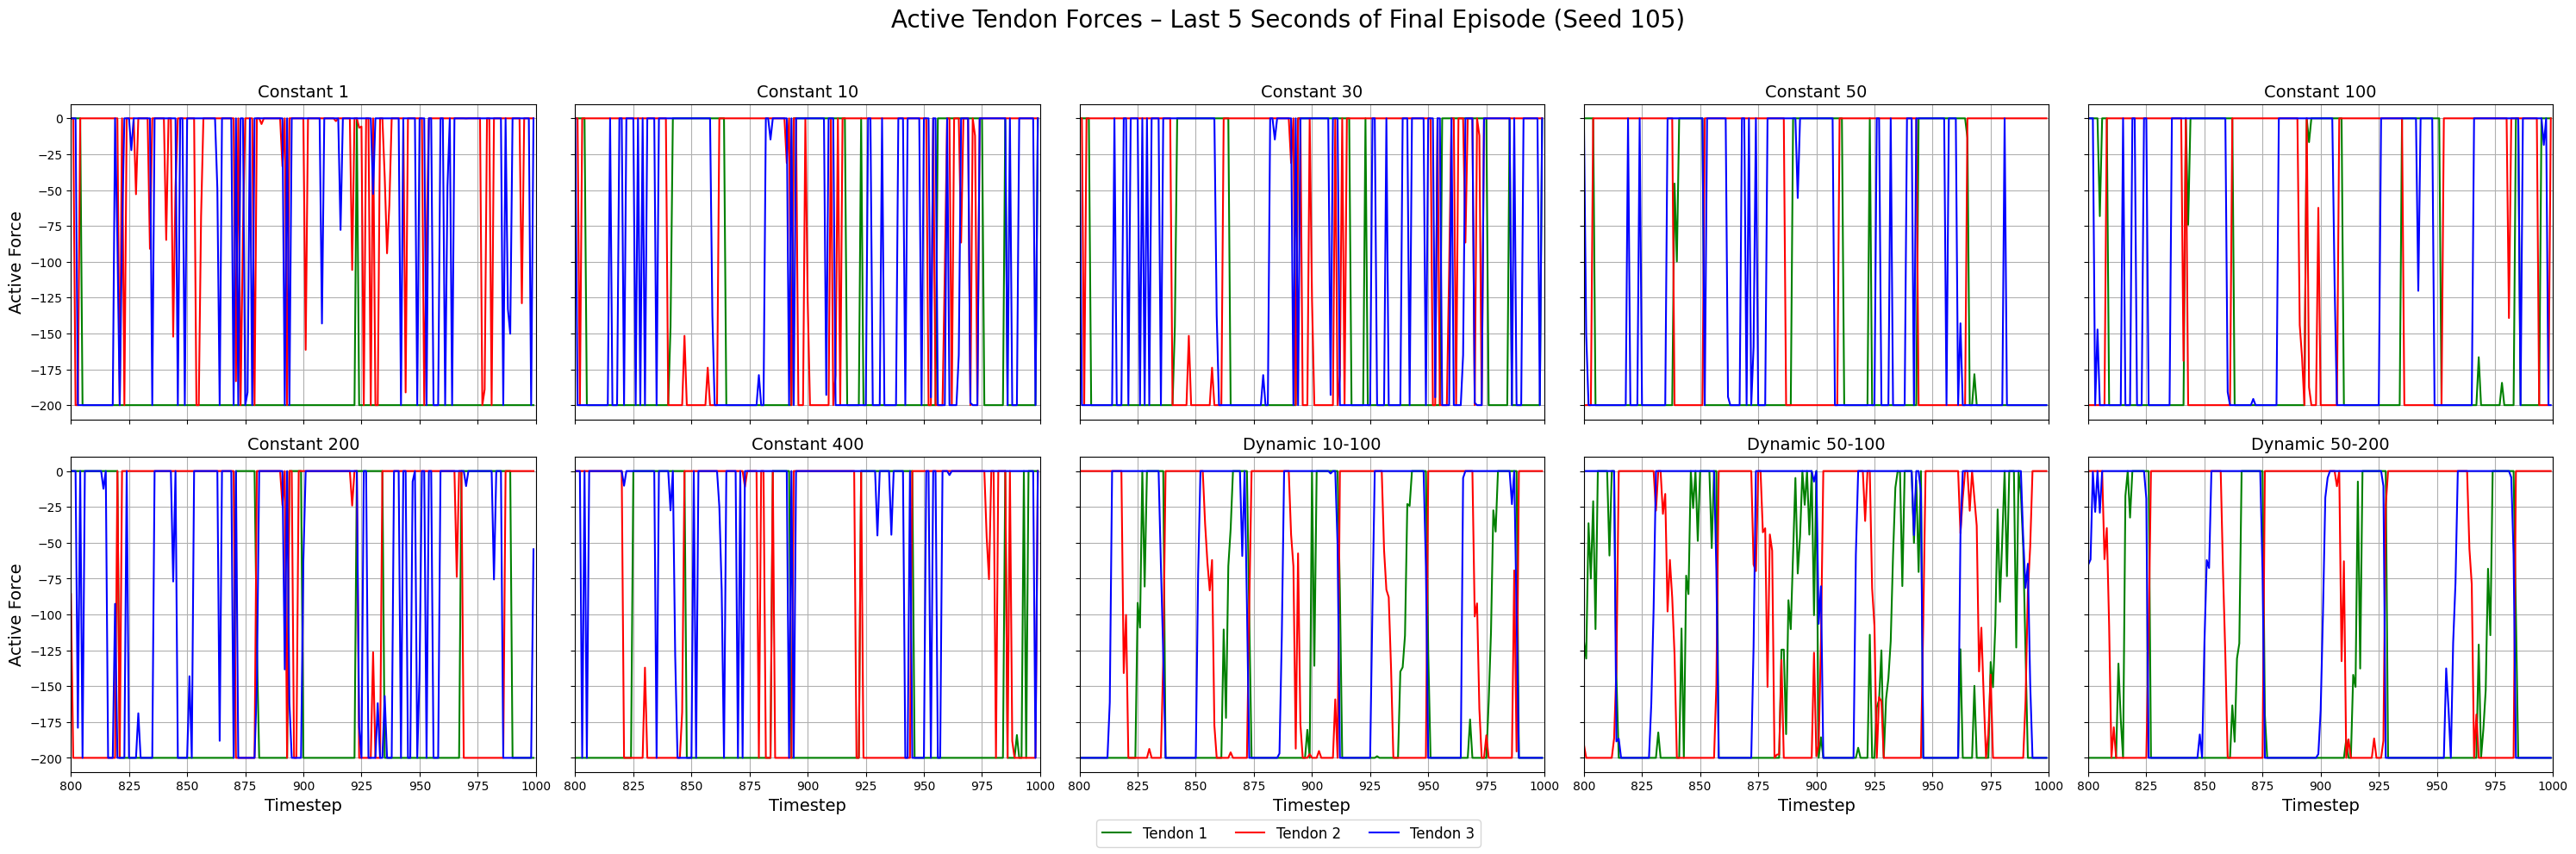

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import os
import re

# ---------- CONFIG ----------
chosen_seed = 105
window_size = 1  # Use >1 to smooth
tendon_colors = ['green', 'red', 'blue']

folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25"
groups = {
    'Constant 1': fr"{folder_name}\LegEnv_Aug07_constant_1_lr_5e-04_PPO\tendon_forces",
    'Constant 10': fr"{folder_name}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO\tendon_forces",
    'Constant 30': fr"{folder_name}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO\tendon_forces",
    'Constant 50': fr"{folder_name}\LegEnv_Jul20_constant_5k_lr_5e-04_PPO\tendon_forces",
    'Constant 100': fr"{folder_name}\LegEnv_Jul20_constant_10k_lr_5e-04_PPO\tendon_forces",
    'Constant 200': fr"{folder_name}\LegEnv_Jul20_constant_20k_lr_5e-04_PPO\tendon_forces",
    'Constant 400': fr"{folder_name}\LegEnv_Jul20_constant_40k_lr_5e-04_PPO\tendon_forces",
    'Dynamic 10-100': fr"{folder_name}\LegEnv_Aug02_seeds_100-120_linear_10-100_lr_5e-04_PPO\tendon_forces",
    'Dynamic 50-100': fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO\tendon_forces",
    'Dynamic 50-200': fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-200_lr_5e-04_PPO\tendon_forces",
}

# ---------- SORTING ----------
def sort_key(label):
    # "Constant" before "Dynamic", sort each group numerically
    group = 0 if "Constant" in label else 1
    match = re.search(r'\d+', label)
    num = int(match.group()) if match else float('inf')
    return (group, num)

sorted_groups = sorted(groups.items(), key=lambda x: sort_key(x[0]))

# ---------- PLOTTING ----------
fig, axes = plt.subplots(2, 5, figsize=(30, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (stiffness, folder) in enumerate(sorted_groups):
    ax = axes[idx]
    ax.set_title(f"{stiffness}", fontsize=14)

    file_path = os.path.join(folder, f"tendon_force_seed_{chosen_seed}.npy")
    if not os.path.exists(file_path):
        print(f"Missing: {file_path}")
        ax.axis('off')
        continue

    tendon_data = np.load(file_path, allow_pickle=True)
    if len(tendon_data) == 0 or len(tendon_data[-1]) < 200:
        print(f"No valid data in {file_path}")
        ax.axis('off')
        continue

    last_episode = tendon_data[-1][-200:]

    tendon_arrays = {i: [] for i in range(3)}
    for timestep in last_episode:
        for entry in timestep:
            tid = entry['tendon_id']
            tendon_arrays[tid].append(entry['active'])

    for tid in range(3):
        y = tendon_arrays[tid]
        if window_size > 1:
            y = np.convolve(y, np.ones(window_size) / window_size, mode='valid')
        t = np.arange(800, 800 + len(y))  # x-axis from 800 to 1000
        ax.plot(t, y, label=f"Tendon {tid + 1}", color=tendon_colors[tid])

    ax.set_xlim(800, 1000)

    if idx % 5 == 0:
        ax.set_ylabel("Active Force", fontsize=14)
    if idx >= 5:
        ax.set_xlabel("Timestep", fontsize=14)

    ax.grid(True)

# Remove extra axes
if len(axes) > len(groups):
    for ax in axes[len(groups):]:
        ax.axis('off')

# Global legend and title
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12)
fig.suptitle(f"Active Tendon Forces – Last 5 Seconds of Final Episode (Seed {chosen_seed})", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f"active_tendon_forces_seed_{chosen_seed}.png", dpi=700, bbox_inches='tight')
plt.show()



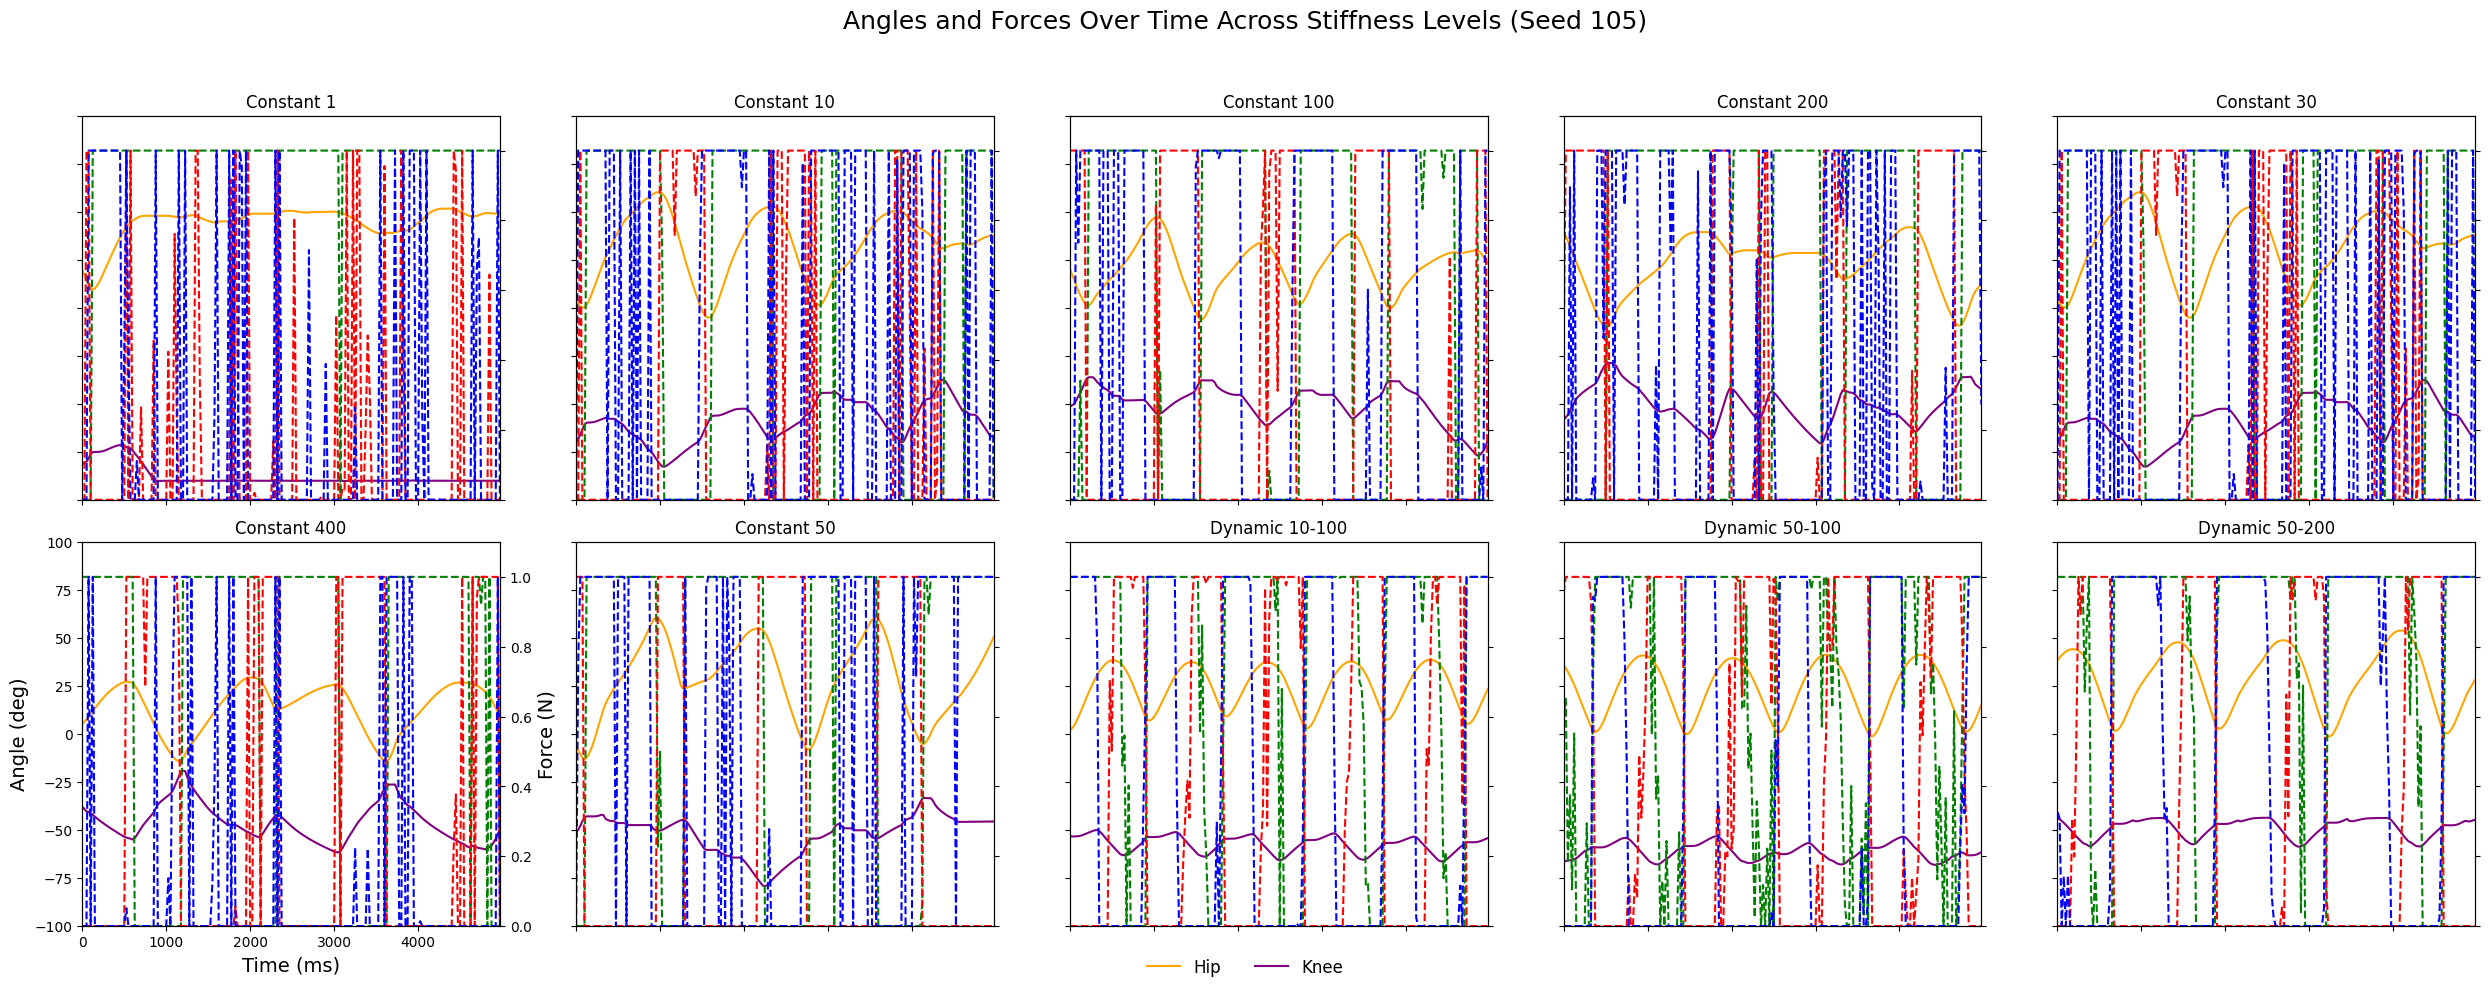

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25"
stiffness_folders = {
    'Constant 1': fr"{folder_name}\LegEnv_Aug07_constant_1_lr_5e-04_PPO",
    'Constant 10': fr"{folder_name}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO",
    'Constant 30': fr"{folder_name}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO",
    'Constant 50': fr"{folder_name}\LegEnv_Jul20_constant_5k_lr_5e-04_PPO",
    'Constant 100': fr"{folder_name}\LegEnv_Jul20_constant_10k_lr_5e-04_PPO",
    'Constant 200': fr"{folder_name}\LegEnv_Jul20_constant_20k_lr_5e-04_PPO",
    'Constant 400': fr"{folder_name}\LegEnv_Jul20_constant_40k_lr_5e-04_PPO",
    'Dynamic 10-100': fr"{folder_name}\LegEnv_Aug02_seeds_100-120_linear_10-100_lr_5e-04_PPO",
    'Dynamic 50-100': fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO",
    'Dynamic 50-200': fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-200_lr_5e-04_PPO",
}

chosen_seed = 105
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, (stiffness, folder) in enumerate(sorted(stiffness_folders.items())):
    qpos_path = os.path.join(folder, f'kinematics/qpos_seed_{chosen_seed}.npy')
    force_path = os.path.join(folder, f'actuator_forces/actuator_forces_seed_{chosen_seed}.npy')

    if not os.path.exists(qpos_path) or not os.path.exists(force_path):
        print(f"Missing data for stiffness {stiffness}")
        continue

    # Load kinematic data
    qpos_data = np.load(qpos_path, allow_pickle=True)
    full_qpos = np.array([np.array(x, dtype=np.float32) for x in qpos_data[-1]])
    last_qpos = np.stack(full_qpos)[800:]  # last 100 frames

    # Load force data
    force_data = np.load(force_path, allow_pickle=True)
    last_forces = np.array(force_data[-1])[800:]  # last 100 frames

    # Angles
    hip_angles = np.degrees(last_qpos[:, 1])
    knee_angles = np.degrees(last_qpos[:, 2])

    # Time vector (in ms)
    dt = 1 / 25  # Sampling rate
    time = np.arange(len(hip_angles)) *25

    ax1 = axes[i]
    ax2 = ax1.twinx()

    # Plot angles
    ax1.plot(time, hip_angles, label='Hip', color='orange')
    ax1.plot(time, knee_angles, label='Knee', color='purple')
    ax1.set_ylim([-100, 100])
    ax1.tick_params(axis='y', labelcolor='black')

    # Plot forces
    ax2.plot(time, last_forces[:, 0], label='M0', color='green', linestyle='--')
    ax2.plot(time, last_forces[:, 1], label='M1', color='red', linestyle='--')
    ax2.plot(time, last_forces[:, 2], label='M2', color='blue', linestyle='--')
    ax2.set_ylim([0, 1.1])  # adjust based on force range
    ax2.tick_params(axis='y', labelcolor='black')

    ax1.set_title(f"{stiffness}")
    ax1.set_xlim([0, time[-1]])

    # Labels only on one plot
    if i == 5:
        ax1.set_xlabel("Time (ms)", fontsize=14)
        ax1.set_ylabel("Angle (deg)" , fontsize=14)
        ax2.set_ylabel("Force (N)", fontsize=14)
    else:
        ax1.tick_params(labelbottom=False, labelleft=False, labelright=False)

        ax2.tick_params(labelbottom=False, labelleft=False, labelright=False)



# Super title and layout
handles, labels = ax1.get_legend_handles_labels()

fig.suptitle(f"Angles and Forces Over Time Across Stiffness Levels (Seed {chosen_seed})", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.legend(handles, labels, loc='lower center', ncol=5, frameon=False, fontsize=12)
plt.savefig(f"angles_forces_over_time_seed_{chosen_seed}.png", dpi=700, bbox_inches='tight')
plt.show()


In [13]:
import numpy as np

dt_eff = 0.025  # env.dt * env.frame_skip

# Load data
folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\LegEnv_Jul20_constant_3k_lr_5e-04_PPO"
tendon_len = np.load(rf"{folder_name}\tendon_lengths\tendon_length_seed_100.npy", allow_pickle=True)
tendon_force = np.load(rf"{folder_name}\tendon_forces\tendon_force_seed_100.npy", allow_pickle=True)
actuator_force = np.load(rf"{folder_name}\actuator_forces\actuator_forces_seed_100.npy", allow_pickle=True)
disp = np.load(rf"{folder_name}\displacements\displacements_seed_100.npy", allow_pickle=True)

energy_per_ep = []
smoothness_per_ep = []

def extract_force_array(ep_force_list, key="active"):
    """Convert list-of-dicts tendon force log to numeric array."""
    arr = []
    for step in ep_force_list:
        arr.append([tendon[key] for tendon in step])
    return np.array(arr, dtype=np.float32)  # shape (T, num_tendons)

# Convert cumulative displacement to per-episode
disp_per_episode = np.diff(np.insert(disp, 0, 0))

N = 50  # last N episodes
energy_per_ep = []
smoothness_per_ep = []

for ep_idx in range(len(tendon_len)-N, len(tendon_len)):
    ep_len = np.array(tendon_len[ep_idx])
    ep_force_dicts = tendon_force[ep_idx]
    ep_act = np.array(actuator_force[ep_idx])
    distance = disp_per_episode[ep_idx]

    v = np.gradient(ep_len, dt_eff, axis=0)
    ep_force = extract_force_array(ep_force_dicts, key="active")
    P = ep_force * v
    W = np.sum(np.abs(P)) * dt_eff

    work_per_meter = W / max(distance, 1e-6)
    force_rate = np.sum(np.abs(np.diff(ep_act, axis=0)))
    norm_force_rate = force_rate / max(distance, 1e-6)

    energy_per_ep.append(work_per_meter)
    smoothness_per_ep.append(norm_force_rate)

print(f"Last {N} episodes:")
print(f"  Mean work/m: {np.mean(energy_per_ep):.3f} ± {np.std(energy_per_ep):.3f}")
print(f"  Mean force-rate/m: {np.mean(smoothness_per_ep):.3f} ± {np.std(smoothness_per_ep):.3f}")


Last 50 episodes:
  Mean work/m: 538267235.131 ± 562672041.562
  Mean force-rate/m: 162579291.554 ± 172060806.315


In [12]:
print("Example episode:")
print("  Avg tendon force (N):", np.mean(ep_force))
print("  Avg tendon velocity (m/s):", np.mean(v))
print("  Avg power (W):", np.mean(P))
print("  Distance (m):", distance)
print("  Work total (J):", W)


Example episode:
  Avg tendon force (N): -106.19006
  Avg tendon velocity (m/s): -0.001339574430906249
  Avg power (W): 13.553455198471541
  Distance (m): 2.786940186513426
  Work total (J): 1114.7670397899326


In [16]:
import numpy as np

dt_eff = 0.025  # env.dt * env.frame_skip
N = 50          # last N episodes

# Load data
folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\LegEnv_Jul20_constant_3k_lr_5e-04_PPO"
actuator_force = np.load(rf"{folder_name}\actuator_forces\actuator_forces_seed_100.npy", allow_pickle=True)
disp = np.load(rf"{folder_name}\displacements\displacements_seed_100.npy", allow_pickle=True)

# If displacement is cumulative, convert to per-episode
disp_per_ep = np.diff(np.insert(disp, 0, 0))

n_tendons = actuator_force[0].shape[1]
energy_proxy_per_tendon = [[] for _ in range(n_tendons)]
smoothness_proxy_per_tendon = [[] for _ in range(n_tendons)]

for ep_idx in range(len(actuator_force) - N, len(actuator_force)):
    ep_act = np.array(actuator_force[ep_idx])  # shape (T, n_tendons)
    distance = disp_per_ep[ep_idx]

    for tendon_idx in range(n_tendons):
        tendon_signal = ep_act[:, tendon_idx]

        # Energy proxy: actuator effort per meter for this tendon
        effort = np.sum(np.abs(tendon_signal))
        effort_per_m = effort / max(distance, 1e-6)

        # Smoothness proxy: actuator force-rate per meter for this tendon
        force_rate = np.sum(np.abs(np.diff(tendon_signal)))
        norm_force_rate = force_rate / max(distance, 1e-6)

        energy_proxy_per_tendon[tendon_idx].append(effort_per_m)
        smoothness_proxy_per_tendon[tendon_idx].append(norm_force_rate)

# Convert lists to arrays
energy_proxy_per_tendon = [np.array(vals) for vals in energy_proxy_per_tendon]
smoothness_proxy_per_tendon = [np.array(vals) for vals in smoothness_proxy_per_tendon]

# Print summary per tendon
for tendon_idx in range(n_tendons):
    print(f"Tendon {tendon_idx}:")
    print(f"  Effort/m: {energy_proxy_per_tendon[tendon_idx].mean():.3f} ± {energy_proxy_per_tendon[tendon_idx].std():.3f}")
    print(f"  Force-rate/m: {smoothness_proxy_per_tendon[tendon_idx].mean():.3f} ± {smoothness_proxy_per_tendon[tendon_idx].std():.3f}")


Tendon 0:
  Effort/m: 313214012.682 ± 326448458.723
  Force-rate/m: 55641572.984 ± 59415833.967
Tendon 1:
  Effort/m: 205570040.338 ± 214378643.883
  Force-rate/m: 74196935.934 ± 80687145.652
Tendon 2:
  Effort/m: 228638693.006 ± 239612224.325
  Force-rate/m: 32740782.636 ± 34884689.769


In [56]:
# analyze_active_work_constant_dynamic_true.py
# Active work (positive/negative/net) for constant & dynamic stiffness experiments
# Distance-weighted aggregation over the last N episodes per seed.
# Requires: numpy, matplotlib, scipy (for Savitzky–Golay derivative)

from pathlib import Path
import re, csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# -------------------- USER CONFIG --------------------
BASE_DIR = Path(r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25")

# Episodes to aggregate per seed (use None or 0 = all episodes)
LAST_N = 5

# Per-episode & per-seed distance filters (meters)
MIN_DIST_EP    = 0.001   # skip episodes that moved < 2 cm
MIN_DIST_BLOCK = 0.05   # skip whole seed if total distance over window < 5 cm

# Velocity estimation for tendon length -> velocity
VEL_METHOD = "savgol"   # "savgol" (recommended) or "grad"
SAVGOL_WIN = 21         # odd; will auto-reduce if episode shorter
SAVGOL_POLY= 3          # < window length

# If None, infer dt_eff from BASE_DIR name like "...df_0.001_fs_25"
DT_EFF = None

# If you want to restrict seeds, set e.g. range(100,121); otherwise None auto-discovers
SEEDS = None

# -----------------------------------------------------

def infer_dt_eff_from_path(base_dir: Path) -> float:
    m = re.search(r"df[_\-]([\d\.eE\-]+)[_\-]fs[_\-](\d+)", str(base_dir))
    if not m:
        raise ValueError("Could not infer dt*frame_skip from BASE_DIR. Set DT_EFF manually.")
    return float(m.group(1)) * int(m.group(2))

def looks_like_experiment_dir(p: Path) -> bool:
    s = p.name.lower()
    return ("_constant_" in s) or ("_linear_" in s) or ("_dynamic_" in s)

def find_experiment_dirs(base_dir: Path):
    return [p for p in base_dir.rglob("LegEnv_*_PPO") if p.is_dir() and looks_like_experiment_dir(p)]

def discover_seeds(cond_dir: Path):
    seeds=set()
    disp_dir = cond_dir / "displacements"
    if not disp_dir.exists():
        return []
    for f in disp_dir.glob("displacements*_seed_*.npy"):
        m = re.search(r"_seed_(\d+)\.npy$", f.name)
        if m: seeds.add(int(m.group(1)))
    return sorted(seeds)

def label_key_family(name: str):
    """
    Returns (label, numeric_sort_key, family), family in {'constant','dynamic','other'}
    """
    s = name.lower()
    m = re.search(r"(constant)_(\d+(?:\.\d+)?)(k)?", s)
    if m:
        fam = "constant"
        # numeric sort key: interpret "10k" as 10000 for ordering only
        val = float(m.group(2)) * (1000 if m.group(3) else 1)
        label = f"constant {m.group(2)}{'k' if m.group(3) else ''}"
        return label, val, fam
    m = re.search(r"(linear|dynamic)_(\d+(?:\.\d+)?)(k)?-(\d+(?:\.\d+)?)(k)?", s)
    if m:
        fam = "dynamic"
        a = float(m.group(2)) * (1000 if m.group(3) else 1)
        label = f"dynamic {m.group(2)}{'k' if m.group(3) else ''}-{m.group(4)}{'k' if m.group(5) else ''}"
        return label, a, fam
    m = re.search(r"(linear|dynamic)_(\d+(?:\.\d+)?)(k)?", s)
    if m:
        fam = "dynamic"
        a = float(m.group(2)) * (1000 if m.group(3) else 1)
        label = f"dynamic {m.group(2)}{'k' if m.group(3) else ''}"
        return label, a, fam
    return name, float("inf"), "other"

def episode_active_work(F_active, L, dt_eff, vel_method="savgol", win=21, poly=3):
    """
    ACTIVE mechanical work for one episode from tendon force & length.
      F_active: (T, n) actuator/tendon force [N]
      L:        (T, n) tendon length [m]
      dt_eff:   scalar time step [s]
    Returns dict with positive/negative/net work totals and per-tendon arrays (J).
    """
    L = np.asarray(L, float)
    F = np.asarray(F_active, float)
    if L.shape != F.shape or L.ndim != 2 or L.shape[0] < 3:
        raise ValueError("Bad shapes for work: L and F must be (T,n) with T>=3 and same shape")

    # tendon velocity
    if vel_method == "savgol":
        v = np.empty_like(L)
        # ensure valid odd window <= T
        T = L.shape[0]
        ww = SAVGOL_WIN if (SAVGOL_WIN % 2 == 1) else SAVGOL_WIN + 1
        ww = min(ww, T if T % 2 == 1 else T-1)
        if ww < 5:
            v[:] = np.gradient(L, dt_eff, axis=0)
        else:
            for j in range(L.shape[1]):
                v[:, j] = savgol_filter(L[:, j], window_length=ww, polyorder=min(poly, ww-2),
                                        deriv=1, delta=dt_eff)
    else:
        v = np.gradient(L, dt_eff, axis=0)

    # instantaneous power
    P = F * v  # W

    # split positive (generation) and negative (absorption)
    P_pos = np.clip(P, 0.0, None)
    P_neg = np.clip(P, None, 0.0)

    W_pos_t = np.sum(P_pos, axis=0) * dt_eff   # J per tendon
    W_neg_t = np.sum(P_neg, axis=0) * dt_eff   # J per tendon (≤0)
    W_net_t = W_pos_t + W_neg_t                # J per tendon

    return {
        "W_pos_total": float(np.sum(W_pos_t)),
        "W_neg_total": float(np.sum(W_neg_t)),
        "W_net_total": float(np.sum(W_net_t)),
        "W_pos_t": W_pos_t,
        "W_neg_t": W_neg_t,
        "W_net_t": W_net_t,
    }

def main():
    dt_eff = DT_EFF if DT_EFF is not None else infer_dt_eff_from_path(BASE_DIR)
    print(f"Using dt_eff = {dt_eff:.6f} s")

    cond_dirs = find_experiment_dirs(BASE_DIR)
    if not cond_dirs:
        print("No experiment folders found under", BASE_DIR)
        return

    # build meta and sort within family
    meta=[]
    for d in cond_dirs:
        lab, key, fam = label_key_family(d.name)
        if fam in ("constant","dynamic"):
            meta.append((lab, key, fam, d))
    meta.sort(key=lambda x: (x[2], x[1]))  # family then numeric key

    per_fam = {"constant": [], "dynamic": []}

    for label, key, fam, cdir in meta:
        seeds = SEEDS if SEEDS is not None else discover_seeds(cdir)
        if not seeds:
            print(f"\n▶ {label}: ⚠ No seeds discovered (missing displacements/*.npy)")
            continue
        print(f"\n▶ {label} | seeds: {seeds}")

        per_seed = []
        for sd in seeds:
            try:
                L_all   = np.load(cdir/"tendon_lengths"/f"tendon_length_seed_{sd}.npy",  allow_pickle=True)
                F_all   = np.load(cdir/"actuator_forces"/f"actuator_forces_seed_{sd}.npy", allow_pickle=True)
                disp    = np.load(cdir/"displacements"/f"displacements_seed_{sd}.npy",    allow_pickle=True)
            except Exception as e:
                print(f"  ❌ SKIP seed {sd}: {e}")
                continue

            # distances per episode from cumulative
            disp_ep = np.diff(np.insert(np.asarray(disp, float), 0, 0.0))
            n = min(len(L_all), len(F_all), len(disp_ep))
            if n <= 0:
                print(f"  ⚠ seed {sd}: zero episodes"); continue

            # choose episodes
            start = 0 if (LAST_N in (None, 0)) else max(0, n - int(LAST_N))

            # accumulators (distance-weighted)
            Wpos_sum_total = 0.0
            Wneg_sum_total = 0.0
            Wpos_sum_tendon = None
            Wneg_sum_tendon = None
            D_sum = 0.0

            for epi in range(start, n):
                d_ep = float(disp_ep[epi])
                if d_ep < MIN_DIST_EP:
                    continue

                L = np.asarray(L_all[epi], float)
                F = np.asarray(F_all[epi], float)
                if L.ndim != 2 or F.ndim != 2 or L.shape[0] < 3 or L.shape != F.shape:
                    continue

                w = episode_active_work(F, L, dt_eff, vel_method=VEL_METHOD)

                Wpos_sum_total += w["W_pos_total"]
                Wneg_sum_total += w["W_neg_total"]

                if Wpos_sum_tendon is None:
                    Wpos_sum_tendon = w["W_pos_t"].copy()
                    Wneg_sum_tendon = w["W_neg_t"].copy()
                else:
                    Wpos_sum_tendon += w["W_pos_t"]
                    Wneg_sum_tendon += w["W_neg_t"]

                D_sum += d_ep

            if D_sum >= MIN_DIST_BLOCK and Wpos_sum_tendon is not None:
                per_seed.append({
                    "work_pos":   Wpos_sum_total / D_sum,                         # J/m
                    "work_neg":   Wneg_sum_total / D_sum,                         # J/m (≤0)
                    "work_net":  (Wpos_sum_total + Wneg_sum_total) / D_sum,       # J/m
                    "work_pos_t": Wpos_sum_tendon / D_sum,                        # per tendon
                    "work_neg_t": Wneg_sum_tendon / D_sum,
                    "work_net_t": (Wpos_sum_tendon + Wneg_sum_tendon) / D_sum,
                })
            else:
                print(f"  ⚠ seed {sd}: insufficient movement (D={D_sum:.3f} m) over window")

        if per_seed:
            def sem(x):
                x = np.asarray(x, float)
                return float(np.std(x, ddof=1)/np.sqrt(len(x))) if len(x) > 1 else 0.0

            per_fam[fam].append({
                "label": label, "key": key,
                "means": {
                    "work_pos":   float(np.mean([s["work_pos"] for s in per_seed])),
                    "work_neg":   float(np.mean([s["work_neg"] for s in per_seed])),
                    "work_net":   float(np.mean([s["work_net"] for s in per_seed])),
                    "work_pos_t": np.mean(np.vstack([s["work_pos_t"] for s in per_seed]), axis=0),
                    "work_neg_t": np.mean(np.vstack([s["work_neg_t"] for s in per_seed]), axis=0),
                    "work_net_t": np.mean(np.vstack([s["work_net_t"] for s in per_seed]), axis=0),
                },
                "sems": {
                    "work_pos":   sem([s["work_pos"] for s in per_seed]),
                    "work_neg":   sem([s["work_neg"] for s in per_seed]),
                    "work_net":   sem([s["work_net"] for s in per_seed]),
                    "work_pos_t": np.std(np.vstack([s["work_pos_t"] for s in per_seed]), axis=0, ddof=1)/np.sqrt(len(per_seed)) if len(per_seed)>1 else np.zeros_like(per_seed[0]["work_pos_t"]),
                    "work_neg_t": np.std(np.vstack([s["work_neg_t"] for s in per_seed]), axis=0, ddof=1)/np.sqrt(len(per_seed)) if len(per_seed)>1 else np.zeros_like(per_seed[0]["work_neg_t"]),
                    "work_net_t": np.std(np.vstack([s["work_net_t"] for s in per_seed]), axis=0, ddof=1)/np.sqrt(len(per_seed)) if len(per_seed)>1 else np.zeros_like(per_seed[0]["work_net_t"]),
                }
            })
        else:
            print(f"  ⚠ {label}: no usable seeds after filtering/aggregation")

    # -------------------- CSV --------------------
    out_csv = BASE_DIR / f"active_work_true_last{LAST_N}_DW.csv"
    with open(out_csv, "w", newline="") as f:
        w = csv.writer(f)
        header = ["family","condition",
                  "work_pos_mean","work_pos_sem",
                  "work_neg_mean","work_neg_sem",
                  "work_net_mean","work_net_sem"]
        w.writerow(header)
        for fam in ("constant","dynamic"):
            for rec in sorted(per_fam[fam], key=lambda r: r["key"]):
                m, s = rec["means"], rec["sems"]
                row = [fam, rec["label"],
                       m["work_pos"], s["work_pos"],
                       m["work_neg"], s["work_neg"],
                       m["work_net"], s["work_net"]]
                w.writerow(row)
    print("Saved CSV →", out_csv)

    # -------------------- PLOTS --------------------
    import matplotlib as mpl

    def _sorted_groups(perfam):
        const = sorted(perfam.get("constant", []), key=lambda r: r["key"])
        dyn   = sorted(perfam.get("dynamic",  []), key=lambda r: r["key"])
        return const, dyn, const + dyn

    def _y_format_plain(ax):
        ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter(useMathText=False))
        ax.ticklabel_format(axis='y', style='plain')

    def plot_combined_total(perfam, metric_key, ylabel, fname):
        const, dyn, combo = _sorted_groups(perfam)
        if not combo:
            print(f"No data for {metric_key}")
            return
        labels = [r["label"].replace("constant ","Constant ").replace("dynamic ","Dynamic ") for r in combo]
        y = np.array([r["means"][metric_key] for r in combo])
        e = np.array([r["sems"][metric_key]  for r in combo])

        x = np.arange(len(labels))
        fig, ax = plt.subplots(figsize=(12,5))
        ax.errorbar(x, y, yerr=e, marker='o', linestyle='-', label=metric_key)
        n_const = len(const)
        if n_const > 0 and len(combo) > n_const:
            ax.axvline(n_const - 0.5, color='k', ls='--', alpha=0.35)
            ymax = np.nanmax(y + (e if np.size(e) else 0))
            ax.text((n_const-1)/2, ymax, "constant", ha='center', va='bottom', fontsize=9)
            ax.text(n_const + (len(combo)-n_const-1)/2, ymax, "dynamic", ha='center', va='bottom', fontsize=9)

        ax.set_xticks(x, labels, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} (last {('all' if LAST_N in (None,0) else LAST_N)} episodes, distance‑weighted)")
        _y_format_plain(ax)
        ax.grid(alpha=0.2)
        fig.tight_layout()
        out = BASE_DIR / fname
        fig.savefig(out, dpi=200); plt.close(fig)
        print("Saved plot →", out)

    # Totals (constants first, then dynamics)
    plot_combined_total(per_fam, "work_pos", "Active positive work per meter (J/m)",
                        f"plot_workPos_total_combined_last{LAST_N}_DW.png")
    plot_combined_total(per_fam, "work_neg", "Active negative work per meter (J/m)",
                        f"plot_workNeg_total_combined_last{LAST_N}_DW.png")
    plot_combined_total(per_fam, "work_net", "Net mechanical work per meter (J/m)",
                        f"plot_workNet_total_combined_last{LAST_N}_DW.png")

if __name__ == "__main__":
    main()


Using dt_eff = 0.025000 s

▶ constant 1 | seeds: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124]
  ⚠ seed 104: insufficient movement (D=0.020 m) over window
  ⚠ seed 115: insufficient movement (D=0.046 m) over window

▶ constant 1k | seeds: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124]
  ⚠ seed 104: insufficient movement (D=0.000 m) over window
  ⚠ seed 106: insufficient movement (D=0.034 m) over window
  ⚠ seed 107: insufficient movement (D=0.012 m) over window
  ⚠ seed 111: insufficient movement (D=0.013 m) over window

▶ constant 3k | seeds: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124]
  ⚠ seed 107: insufficient movement (D=0.009 m) over window
  ⚠ seed 113: insufficient movement (D=0.026 m) over window
  ⚠ seed 114: insufficient movement (D=0.019 

In [ ]:
# === qpos coordination metrics across seeds/conditions (NO RESAMPLING) ===
# Scans: <ROOT>\**\kinematics\qpos_seed_*.npy
# Condition label = parent folder of "kinematics" (e.g., LegEnv_Jul20_constant_1k_lr_5e-04_PPO)

import os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# ----------------- CONFIG -----------------
ROOT = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25"
HIP_IDX  = 0   # <-- set to your hip qpos index
KNEE_IDX = 1   # <-- set to your knee qpos index

EPISODE_ID    = -1         # last episode
WINDOW_STEPS  = 200        # last 5 seconds = 200 steps
STANDARDIZE   = False      # if True, z-score hip/knee per trial before metrics
DTW_BAND_RATIO = 0.1       # Sakoe–Chiba band (speed)
BINS_2D       = 40         # for occupancy entropy
OUT_DIR = Path(ROOT) / "coord_metrics_out"
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ------------------------------------------

def find_qpos_files(root: str):
    pattern = str(Path(root) / "**" / "kinematics" / "qpos_seed_*.npy")
    return sorted(glob.glob(pattern, recursive=True))

def parse_condition_from_path(path: str) -> str:
    p = Path(path)
    return p.parent.parent.name  # ...\<ENV>\kinematics\qpos_...

# ------- robust loaders & helpers -------
def _to_float2d(xy):
    xy = np.asarray(xy)
    if xy.dtype == object:
        xy = np.vectorize(lambda v: float(v))(xy)
    xy = xy.astype(np.float64, copy=False)
    mask = np.isfinite(xy).all(axis=1)
    if not mask.any():
        raise ValueError("No finite rows after cleaning")
    return xy[mask]

def load_qpos_last_window(npy_path: str, hip_idx: int, knee_idx: int,
                          episode_id: int, window_steps: int) -> np.ndarray:
    raw = np.load(npy_path, allow_pickle=True)
    # handle dict-like saves: np.save(..., {'qpos': arr})
    if isinstance(raw, np.ndarray) and raw.dtype == object and raw.size == 1:
        maybe = raw.item()
        if isinstance(maybe, dict) and 'qpos' in maybe:
            raw = maybe['qpos']
    # normalize shapes
    if isinstance(raw, np.ndarray) and raw.ndim == 3:
        epi = raw[episode_id]  # (T,D)
    elif isinstance(raw, np.ndarray) and raw.ndim == 2:
        epi = raw
    elif isinstance(raw, np.ndarray) and raw.dtype == object:
        epi = raw[episode_id]
    else:
        raise ValueError(f"Unsupported qpos shape/dtype: {getattr(raw,'shape',None)} / {getattr(raw,'dtype',None)}")
    T = epi.shape[0]
    w = min(window_steps, T)
    seg = epi[-w:, [hip_idx, knee_idx]]  # (WINDOW_STEPS, 2)
    return _to_float2d(seg)

def maybe_standardize(xy: np.ndarray, do: bool) -> np.ndarray:
    if not do:
        return xy
    mu = xy.mean(axis=0); sd = xy.std(axis=0); sd[sd==0]=1.0
    return (xy - mu)/sd

def cov_ellipse_metrics(xy: np.ndarray):
    C = np.cov(xy.T)
    w, _ = np.linalg.eigh(C); w = np.sort(w)
    area = float(np.pi * np.sqrt(max(w[0],1e-12)) * np.sqrt(max(w[1],1e-12)))
    lam_min, lam_max = w[0], w[1]
    ecc = 0.0 if lam_max <= 0 else float(np.sqrt(1.0 - (lam_min/lam_max)))
    return area, ecc

def dtw_banded(seq1: np.ndarray, seq2: np.ndarray, band_ratio: float=0.1) -> float:
    n, m = len(seq1), len(seq2)
    w = int(max(band_ratio*max(n,m), abs(n-m)))
    INF = 1e18
    D = np.full((n+1, m+1), INF); D[0,0] = 0.0
    for i in range(1, n+1):
        j0, j1 = max(1, i-w), min(m, i+w)
        for j in range(j0, j1+1):
            d = float(np.linalg.norm(seq1[i-1] - seq2[j-1]))
            D[i,j] = d + min(D[i-1,j], D[i,j-1], D[i-1,j-1])
    return float(D[n,m])

def occupancy_entropy(xy: np.ndarray, bins:int=40) -> float:
    H, _, _ = np.histogram2d(xy[:,0], xy[:,1], bins=bins, density=True)
    p = H.ravel(); p = p[p>0]
    return float(-np.sum(p * np.log(p)))

def compute_metrics_for_condition(files):
    # normalize all sequences (no resampling), pick medoid via DTW
    seqs = {}
    for f in files:
        xy = load_qpos_last_window(f, HIP_IDX, KNEE_IDX, EPISODE_ID, WINDOW_STEPS)
        xy = maybe_standardize(xy, STANDARDIZE)
        seqs[f] = xy
    paths = list(seqs.keys())
    if not paths: return {}
    K = len(paths)
    mean_d = np.zeros(K)
    for i in range(K):
        di = 0.0
        for j in range(K):
            if i == j: continue
            di += dtw_banded(seqs[paths[i]], seqs[paths[j]], DTW_BAND_RATIO)
        mean_d[i] = di / max(1, K-1)
    med_idx = int(np.argmin(mean_d))
    med_seq = seqs[paths[med_idx]]
    out = {}
    for p, xy in seqs.items():
        area, ecc = cov_ellipse_metrics(xy)
        dmed = dtw_banded(xy, med_seq, DTW_BAND_RATIO)
        ent = occupancy_entropy(xy, BINS_2D)
        out[p] = {"ellipse_area": area, "ellipse_eccentricity": ecc,
                  "dtw_to_medoid": dmed, "entropy": ent}
    return out

# ---------- Run ----------
all_files = find_qpos_files(ROOT)
if not all_files:
    raise FileNotFoundError(f"No qpos_seed_*.npy found under {ROOT}")
by_cond = defaultdict(list)
for f in all_files:
    by_cond[parse_condition_from_path(f)].append(f)

rows = []
for cond, files in sorted(by_cond.items()):
    metrics = compute_metrics_for_condition(files)
    for p, m in metrics.items():
        rows.append({"condition": cond, "trial": Path(p).name, **m})
df = pd.DataFrame(rows).sort_values(["condition","trial"])

# Save CSV
csv_path = OUT_DIR / "coordination_metrics_no_resample.csv"
df.to_csv(csv_path, index=False)
print(f"Saved metrics -> {csv_path}")

# Boxplots
def boxplot_metric(metric, ylabel, fname):
    if df.empty: return
    plt.figure()
    groups = [g[metric].values for _, g in df.groupby("condition")]
    labels = list(df.groupby("condition").groups.keys())
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.ylabel(ylabel); plt.xlabel("Condition"); plt.xticks(rotation=22)
    plt.title(f"{ylabel} by Condition")
    plt.tight_layout(); plt.savefig(OUT_DIR / fname, dpi=700); plt.close()

boxplot_metric("ellipse_area", "Ellipse Area", "ellipse_area_box.png")
boxplot_metric("ellipse_eccentricity", "Ellipse Eccentricity", "ellipse_ecc_box.png")
boxplot_metric("dtw_to_medoid", "DTW to Medoid", "dtw_medoid_box.png")
boxplot_metric("entropy", "Occupancy Entropy", "entropy_box.png")

print("Done.")


C:\Users\User\AppData\Local\Temp\ipykernel_3952\719886069.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt


Saved metrics -> C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\coord_metrics_out\coordination_metrics_no_resample.csv
Done.


Saved metrics -> C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\coord_metrics_out\coordination_metrics_l200_noresample.csv
Saved plots to: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\coord_metrics_out\figs_pretty


In [2]:
# === Coordination metrics + plots (degrees, unwrapped, last-200, 2x5 subplot) ===
import os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# ---------------- CONFIG ----------------
base_folder = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25"
HIP_IDX, KNEE_IDX = 0, 1
EPISODE_ID, WINDOW_STEPS = -1, 200
STANDARDIZE = False                 # (per-trial z-score) False recommended for physical units
DTW_BAND_RATIO, BINS_2D = 0.10, 40

# Subplot grid
N_ROWS, N_COLS = 2, 5

# Axis behavior for the multi-panel loops figure
USE_FIXED_LIMITS = True             # if False, auto-scales to data
HIP_LIMS  = (-20, 80)               # deg
KNEE_LIMS = (-80, -20)              # deg

# If you keep fixed limits but your data sit outside, auto-shift knee FOR PLOTTING ONLY
AUTO_CALIBRATE_KNEE_OFFSET_FOR_PLOTS = True
TARGET_KNEE_MID = -50.0             # center of the fixed knee band (deg)

# Optional display convention (applied to BOTH metrics & plots); leave False unless you really need it
FLIP_KNEE_SIGN = False
GLOBAL_KNEE_OFFSET_FOR_METRICS = 0.0 # adds a constant to knee (deg) for metrics+plots (rarely needed)

# Explicit mapping (order controls x-axis & subplot order)
folders = {

    "Constant 1":    fr"{base_folder}\LegEnv_Aug07_constant_1_lr_5e-04_PPO",
    "Constant 10":    fr"{base_folder}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO",
    "Constant 30":    fr"{base_folder}\LegEnv_Jul20_constant_3k_lr_5e-04_PPO",
    "Constant 50":    fr"{base_folder}\LegEnv_Jul20_constant_5k_lr_5e-04_PPO",
    "Constant 100":   fr"{base_folder}\LegEnv_Jul20_constant_10k_lr_5e-04_PPO",
    "Constant 200":   fr"{base_folder}\LegEnv_Jul20_constant_20k_lr_5e-04_PPO",
    "Constant 400":   fr"{base_folder}\LegEnv_Jul20_constant_40k_lr_5e-04_PPO",
    "Dynamic 10-100": fr"{base_folder}\LegEnv_Aug02_seeds_100-120_linear_10-100_lr_5e-04_PPO",
    "Dynamic 50-100": fr"{base_folder}\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO",
    "Dynamic 50-200": fr"{base_folder}\LegEnv_Aug01_seeds_100-110_linear_50-200_lr_5e-04_PPO",
}
# ---------------------------------------

OUT_DIR  = Path(base_folder) / "coord_metrics_out"
PLOT_DIR = OUT_DIR / "figs_pretty"
OUT_DIR.mkdir(parents=True, exist_ok=True); PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ------------- helpers -------------
def unwrap_rad_to_deg(radians_1d: np.ndarray) -> np.ndarray:
    """Unwrap in radians, convert to degrees, and wrap to [-180, 180]."""
    r = np.unwrap(np.asarray(radians_1d, dtype=float))
    deg = np.degrees(r)
    return (deg + 180.0) % 360.0 - 180.0

def load_qpos_last_window_deg_unwrapped(npy_path: str) -> np.ndarray:
    """Return (T,2) = [hip_deg, knee_deg], unwrapped to remove 360° jumps."""
    raw = np.load(npy_path, allow_pickle=True)
    if isinstance(raw, np.ndarray) and raw.dtype == object and raw.size == 1:
        maybe = raw.item()
        if isinstance(maybe, dict) and 'qpos' in maybe:
            raw = maybe['qpos']

    if raw.ndim == 3:   # (episodes, steps, dof)
        epi = raw[EPISODE_ID]
    elif raw.ndim == 2: # (steps, dof)
        epi = raw
    elif isinstance(raw, np.ndarray) and raw.dtype == object:
        epi = raw[EPISODE_ID]
    else:
        raise ValueError(f"Unsupported qpos format in {npy_path}")

    seg = epi[-min(WINDOW_STEPS, epi.shape[0]):, [HIP_IDX, KNEE_IDX]]  # radians
    seg = np.asarray(seg, dtype=float)

    hip_deg  = unwrap_rad_to_deg(seg[:, 0])
    knee_deg = unwrap_rad_to_deg(seg[:, 1])

    if FLIP_KNEE_SIGN: knee_deg = -knee_deg
    if GLOBAL_KNEE_OFFSET_FOR_METRICS: knee_deg = knee_deg + GLOBAL_KNEE_OFFSET_FOR_METRICS

    xy = np.column_stack([hip_deg, knee_deg])
    if not STANDARDIZE:
        return xy
    # optional z-score (shape-only)
    mu, sd = xy.mean(axis=0), xy.std(axis=0); sd[sd==0]=1.0
    return (xy - mu)/sd

def cov_ellipse_metrics(xy: np.ndarray):
    C = np.cov(xy.T); w, _ = np.linalg.eigh(C); w = np.sort(w)
    area = float(np.pi * np.sqrt(max(w[0],1e-12)) * np.sqrt(max(w[1],1e-12)))
    lam_min, lam_max = w[0], w[1]
    ecc = 0.0 if lam_max <= 0 else float(np.sqrt(1.0 - (lam_min/lam_max)))
    return area, ecc

def dtw_banded(seq1: np.ndarray, seq2: np.ndarray, band_ratio: float=0.1) -> float:
    n, m = len(seq1), len(seq2); w = int(max(band_ratio*max(n,m), abs(n-m))); INF=1e18
    D = np.full((n+1, m+1), INF); D[0,0] = 0.0
    for i in range(1, n+1):
        j0, j1 = max(1, i-w), min(m, i+w)
        for j in range(j0, j1+1):
            d = float(np.linalg.norm(seq1[i-1] - seq2[j-1]))
            D[i,j] = d + min(D[i-1,j], D[i,j-1], D[i-1,j-1])
    return float(D[n,m])

def occupancy_entropy(xy: np.ndarray, bins:int=40) -> float:
    H, _, _ = np.histogram2d(xy[:,0], xy[:,1], bins=bins, density=True)
    p = H.ravel(); p = p[p>0]
    return float(-np.sum(p * np.log(p)))

# -------- collect sequences + metrics (DEGREES, UNWRAPPED) --------
rows, all_sequences, medoid_seq_by_label = [], {}, {}
for label, folder in folders.items():
    seed_files = sorted(glob.glob(str(Path(folder) / "kinematics" / "qpos_seed_*.npy")))
    if not seed_files:
        print(f"[WARN] No qpos files for '{label}' in {folder}")
        continue

    seqs = {}
    for f in seed_files:
        xy = load_qpos_last_window_deg_unwrapped(f)   # degrees, unwrapped
        seqs[f] = xy
        all_sequences.setdefault(label, []).append((f, xy))

    # medoid (degrees)
    paths = list(seqs.keys())
    K = len(paths); mean_d = np.zeros(K)
    for i in range(K):
        di = 0.0
        for j in range(K):
            if i == j: continue
            di += dtw_banded(seqs[paths[i]], seqs[paths[j]], DTW_BAND_RATIO)
        mean_d[i] = di / max(1, K-1)
    med_seq = seqs[paths[int(np.argmin(mean_d))]]
    medoid_seq_by_label[label] = med_seq

    # per-seed metrics (degrees)
    for p, xy in seqs.items():
        area, ecc = cov_ellipse_metrics(xy)
        dmed, ent = dtw_banded(xy, med_seq, DTW_BAND_RATIO), occupancy_entropy(xy, BINS_2D)
        rows.append({"label": label, "trial": Path(p).name,
                     "ellipse_area": area, "ellipse_eccentricity": ecc,
                     "dtw_to_medoid": dmed, "entropy": ent})

df = pd.DataFrame(rows)
csv_path = OUT_DIR / "coordination_metrics_deg_unwrapped_l200.csv"
df.to_csv(csv_path, index=False)
print(f"Saved metrics -> {csv_path}")

# ------------- boxplots -------------
labels_order = list(folders.keys())

def boxplot_pretty(metric, ylabel, fname):
    groups = [df.loc[df["label"] == lab, metric].values for lab in labels_order]
    plt.figure(figsize=(max(9, 0.9*len(labels_order)), 4.8))
    plt.boxplot(groups, labels=labels_order, showfliers=False)
    plt.ylabel(ylabel); plt.xlabel("Stiffness Profile"); plt.xticks(rotation=20)
    plt.title(f"{ylabel} by Stiffness Profile")
    try:
        const_end = max(i for i,l in enumerate(labels_order) if l.startswith("Constant "))
        plt.axvspan(const_end+1.5, len(labels_order)+0.5, color=(0,0,0,0.05))
    except ValueError:
        pass
    plt.tight_layout(); plt.savefig(PLOT_DIR / fname, dpi=220); plt.close()

PLOT_DIR.mkdir(parents=True, exist_ok=True)
boxplot_pretty("ellipse_area",         "Ellipse Area (deg²)",  "box_ellipse_area.png")
boxplot_pretty("ellipse_eccentricity", "Ellipse Eccentricity", "box_eccentricity.png")
boxplot_pretty("dtw_to_medoid",        "DTW to Medoid (deg)",  "box_dtw_medoid.png")
boxplot_pretty("entropy",              "Occupancy Entropy",    "box_entropy.png")

# ------------- 2x5 subplot: all loops (deg), medoid bold -------------
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS*3.2, N_ROWS*3.2), sharex=True, sharey=True)

# Compute global bounds for optional auto-scaling/rendering
all_hip  = np.concatenate([xy[:,0] for lbl in labels_order for _,xy in all_sequences.get(lbl, [])]) if all_sequences else np.array([0])
all_knee = np.concatenate([xy[:,1] for lbl in labels_order for _,xy in all_sequences.get(lbl, [])]) if all_sequences else np.array([0])
hip_lo, hip_hi   = float(all_hip.min()-5),  float(all_hip.max()+5)
knee_lo, knee_hi = float(all_knee.min()-5), float(all_knee.max()+5)

# For plotting ONLY: auto-calibrate a knee offset so fixed limits show data (metrics are untouched)
plot_knee_offset = 0.0
if USE_FIXED_LIMITS and AUTO_CALIBRATE_KNEE_OFFSET_FOR_PLOTS and len(all_knee) > 1:
    global_mid = 0.5 * (all_knee.min() + all_knee.max())
    plot_knee_offset = TARGET_KNEE_MID - global_mid

def apply_limits(ax):
    if USE_FIXED_LIMITS:
        ax.set_xlim(*HIP_LIMS); ax.set_ylim(*KNEE_LIMS)
    else:
        ax.set_xlim(hip_lo, hip_hi); ax.set_ylim(knee_lo, knee_hi)

for idx, label in enumerate(labels_order):
    r, c = divmod(idx, N_COLS)
    ax = axes[r, c]
    bundle = all_sequences.get(label, [])
    if not bundle:
        ax.axis("off"); continue
    med_seq = medoid_seq_by_label.get(label, None)

    # light gray: all seeds (apply plot-only knee offset)
    for _, xy in bundle:
        y = xy[:,1] + plot_knee_offset
        ax.plot(xy[:,0], y, linewidth=0.6, alpha=0.5, color="gray")
    # medoid bold
    if med_seq is not None:
        ax.plot(med_seq[:,0], med_seq[:,1] + plot_knee_offset, linewidth=2.0, color='tab:orange')

    apply_limits(ax)
    ax.set_title(label, fontsize=9)
    ax.set_aspect("equal")

# hide unused panels
for idx in range(len(labels_order), N_ROWS*N_COLS):
    r, c = divmod(idx, N_COLS); axes[r, c].axis("off")

fig.text(0.5, 0.04, "Hip angle (deg)", ha='center', fontsize=12)
fig.text(0.06, 0.5, "Knee angle (deg)", va='center', rotation='vertical', fontsize=12)
plt.tight_layout(rect=[0.06, 0.06, 1, 0.98])
plt.savefig(PLOT_DIR / "loops_all_conditions_subplots.png", dpi=250)
plt.close()

# ------------- medoid-to-medoid DTW heatmap (deg) -------------
labs = [lab for lab in labels_order if lab in medoid_seq_by_label]
L = len(labs); M = np.zeros((L, L), dtype=float)
for i in range(L):
    for j in range(L):
        M[i,j] = 0.0 if i==j else dtw_banded(medoid_seq_by_label[labs[i]], medoid_seq_by_label[labs[j]], DTW_BAND_RATIO)

plt.figure(figsize=(1.15*L, 1.0*L))
im = plt.imshow(M, cmap="magma", interpolation="nearest")
plt.colorbar(im, fraction=0.046, pad=0.04, label="DTW distance (deg)")
plt.xticks(range(L), labs, rotation=20, ha='right'); plt.yticks(range(L), labs)
plt.title("Medoid-to-Medoid DTW Distance (coordination similarity)")
for i in range(L):
    for j in range(L):
        plt.text(j, i, f"{M[i,j]:.0f}", ha='center', va='center', color='w', fontsize=8)
plt.tight_layout(); plt.savefig(PLOT_DIR / "medoid_dtw_heatmap.png", dpi=240); plt.close()

print("Saved plots to:", PLOT_DIR)


Saved metrics -> C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\coord_metrics_out\coordination_metrics_deg_unwrapped_l200.csv
Saved plots to: C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\coord_metrics_out\figs_pretty


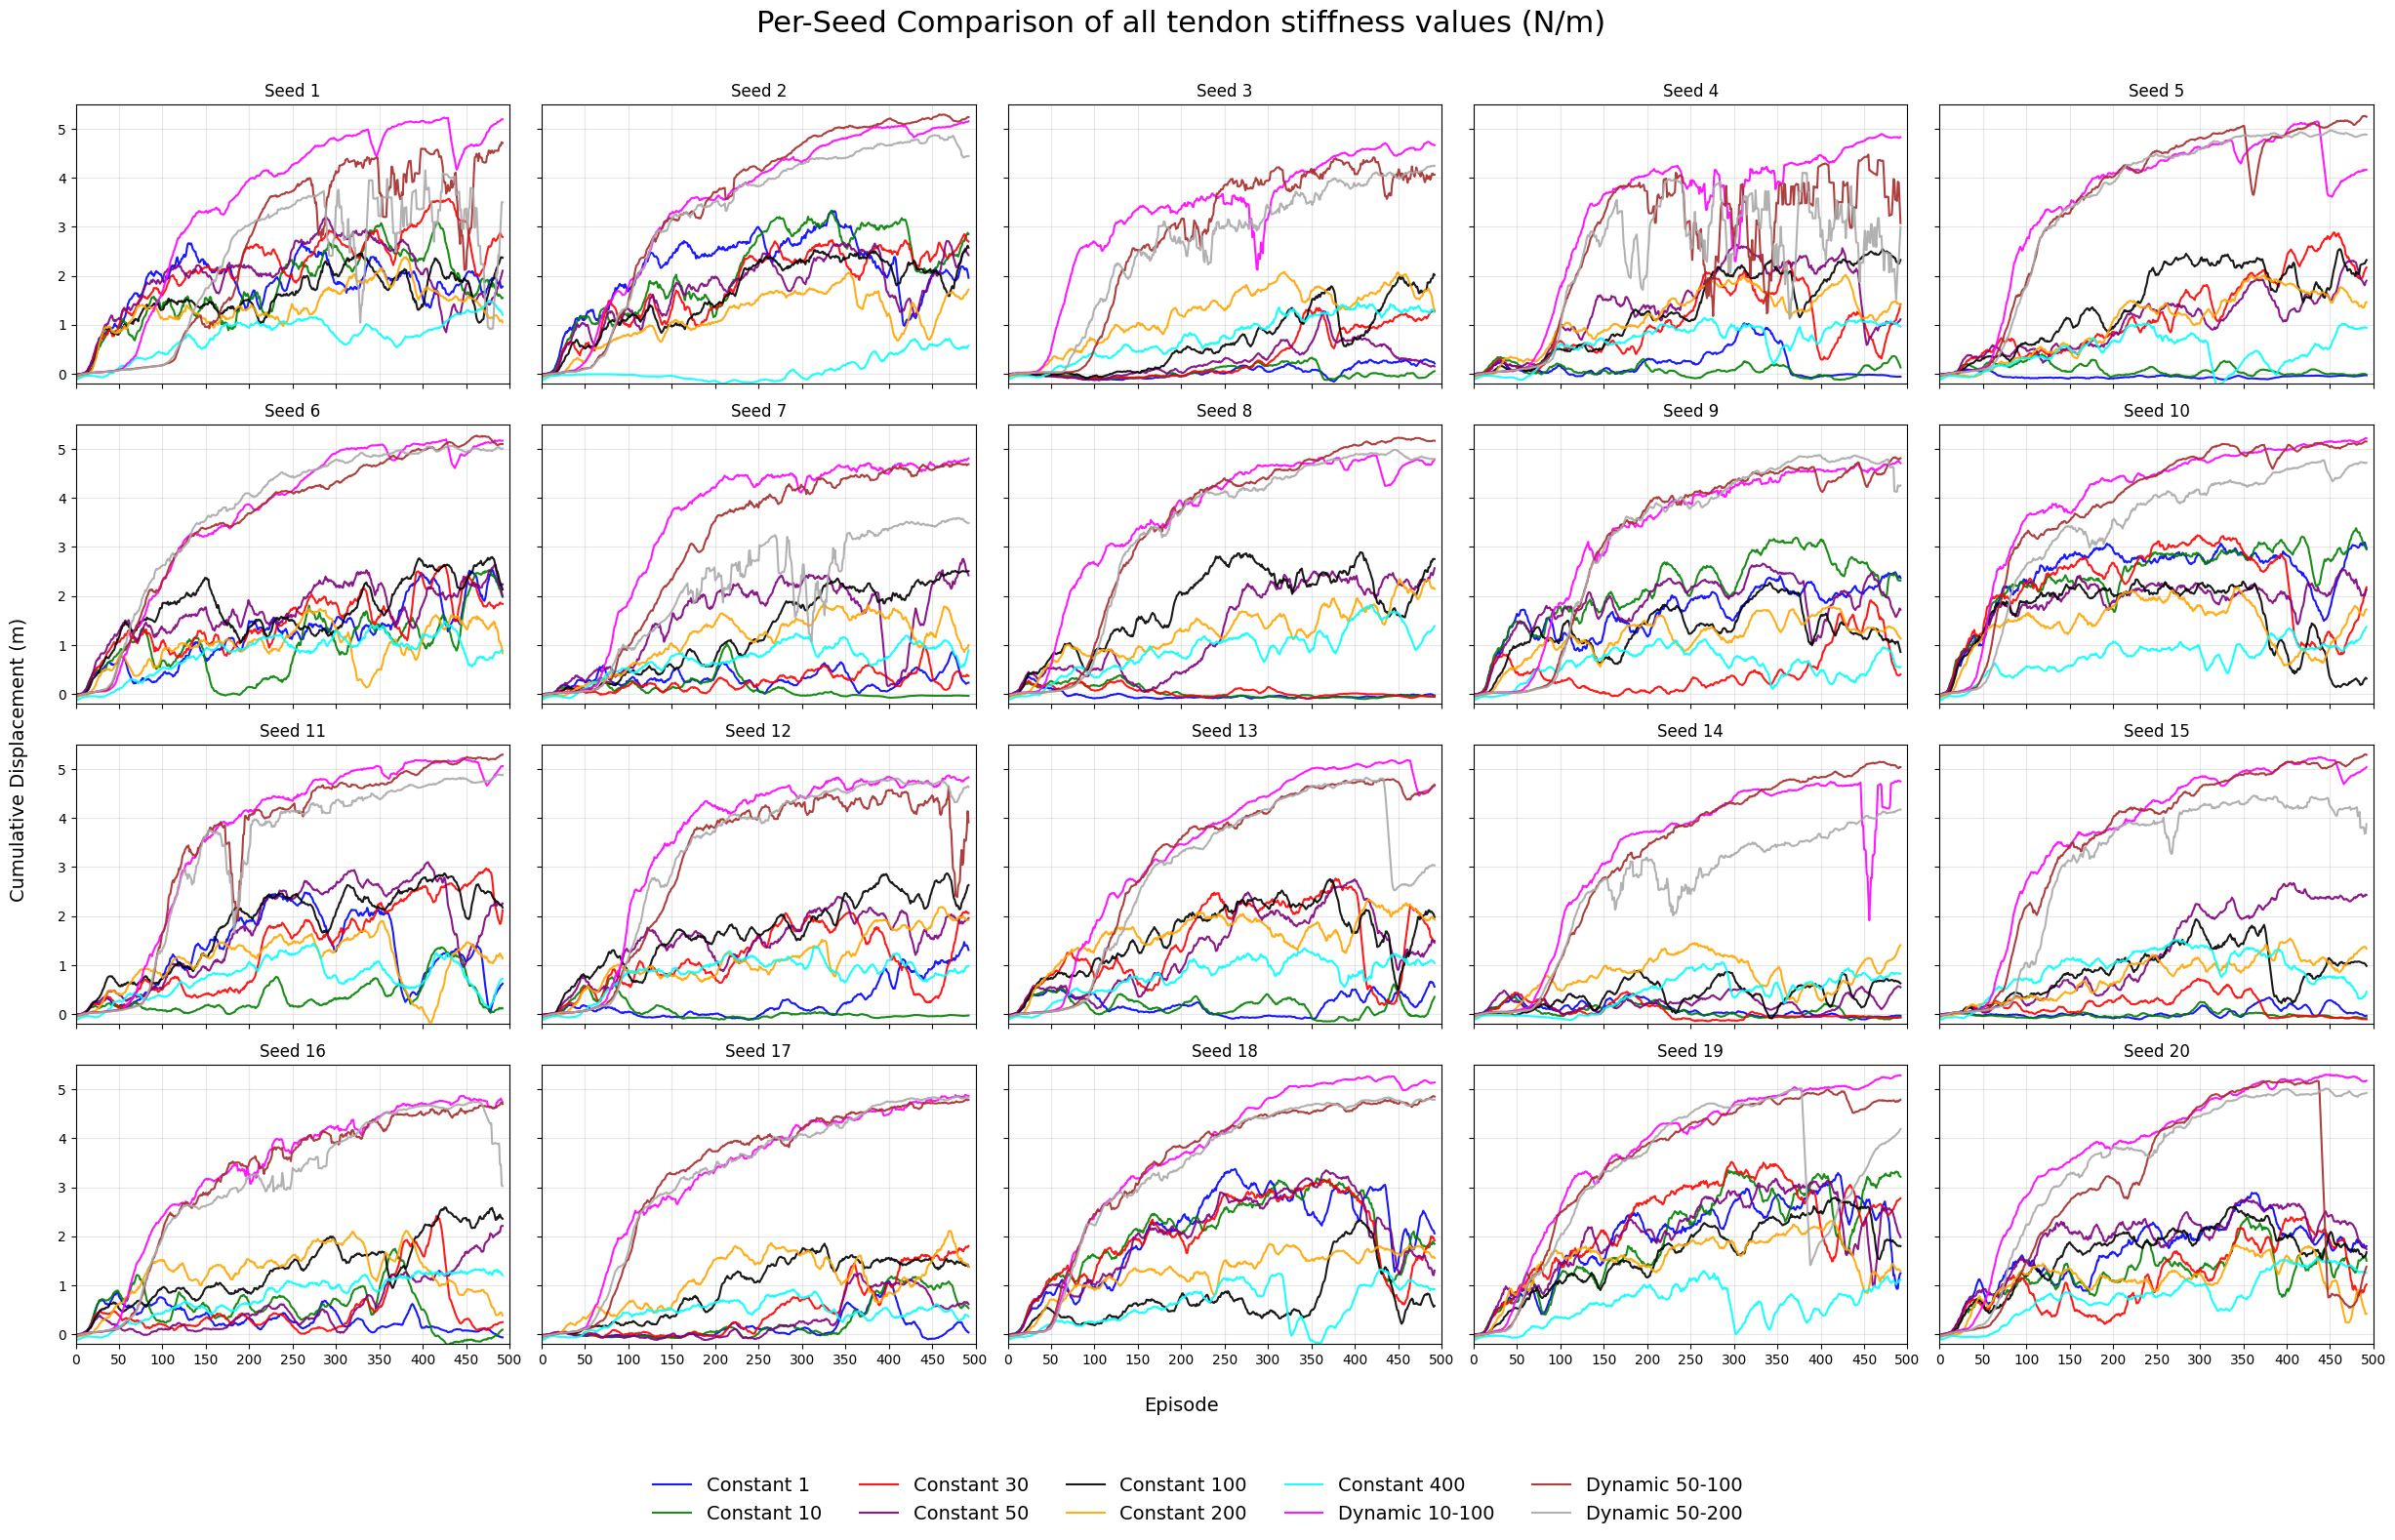

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math

folder_name = r"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25"

def moving_average(data, window_size=5):
    """Apply moving average smoothing."""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# ==== Groups (cases) ====
groups = {
    "Constant 1":  fr"{folder_name}\LegEnv_Aug07_constant_1_lr_5e-04_PPO\displacements",
    # "Constant 5": fr"{folder_name}\LegEnv_Jul24_constant_5_lr_5e-04_PPO\displacements",

    "Constant 10": fr"{folder_name}\LegEnv_Jul20_constant_1k_lr_5e-04_PPO\displacements",
    "Constant 30": fr"{folder_name}\LegEnv_Jul20_constant_3k_lr_5e-04_PPO\displacements",
    "Constant 50": fr"{folder_name}\LegEnv_Jul20_constant_5k_lr_5e-04_PPO\displacements",

    "Constant 100": fr"{folder_name}\LegEnv_Jul20_constant_10k_lr_5e-04_PPO\displacements",
    "Constant 200": fr"{folder_name}\LegEnv_Jul20_constant_20k_lr_5e-04_PPO\displacements",
    "Constant 400": fr"{folder_name}\LegEnv_Jul20_constant_40k_lr_5e-04_PPO\displacements",

    "Dynamic 10-100": fr"{folder_name}\LegEnv_Aug02_seeds_100-120_linear_10-100_lr_5e-04_PPO\displacements",
    "Dynamic 50-100": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO\displacements",
    "Dynamic 50-200": fr"{folder_name}\LegEnv_Aug01_seeds_100-110_linear_50-200_lr_5e-04_PPO\displacements",
}

# ==== Seed ranges per group ====
group_seeds = {
    "Constant 1": range(100, 125),
    # "Constant 5": range(100, 120),

    "Constant 10": range(100, 125),
    "Constant 30": range(100, 125),
    "Constant 50": range(100, 125),

    "Constant 100": range(100, 125),
    "Constant 200": range(100, 120),
    "Constant 400": range(100, 125),

    "Dynamic 10-100": range(100, 120),
    "Dynamic 50-100": range(100, 120),
    "Dynamic 50-200": range(100, 120),
}

# Colors per case (consistent across all subplots)
colors = ['blue','green','red','purple','black','orange','cyan','magenta','brown','darkgrey','tan','sienna']
labels_list = list(groups.keys())
group_colors = {label: colors[i % len(colors)] for i, label in enumerate(labels_list)}

# ==== Choose up to 20 seeds to show (intersection across all groups so each subplot can have every case) ====
seed_sets = [set(group_seeds[label]) for label in groups if label in group_seeds]
seeds_common = sorted(set.intersection(*seed_sets)) if seed_sets else []
max_seeds = 20
seeds_to_plot = seeds_common[:max_seeds]

# If for some reason intersection is empty, fall back to union (still capped at 20; some cases may be missing per subplot)
if not seeds_to_plot:
    seeds_union = sorted(set().union(*seed_sets))
    seeds_to_plot = seeds_union[:max_seeds]

# ==== Plotting ====
window_size = 10

n = len(seeds_to_plot)
if n == 0:
    raise RuntimeError("No seeds found to plot. Check your group_seeds definitions and data files.")

ncols = 5 if n >= 5 else n
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

global_max_len = 0

for i, seed in enumerate(seeds_to_plot):
    ax = axes[i]
    lines_drawn = 0

    for g_idx, (label, folder) in enumerate(groups.items()):
        file_path = os.path.join(folder, f"displacements_seed_{seed}.npy")
        if os.path.exists(file_path):
            arr = np.load(file_path)

            # Smooth each trace
            smoothed = moving_average(arr, window_size)
            smoothed = np.insert(smoothed, 0, 0.0)  # start at episode 0
            episodes = np.arange(len(smoothed))

            # Only label in the first subplot to create a single, clean global legend later
            lbl = label if i == 0 else "_nolegend_"
            ax.plot(episodes, smoothed, label=lbl, linewidth=1.5, alpha=0.9,
                    color=group_colors[label])
            lines_drawn += 1
            global_max_len = max(global_max_len, len(episodes))
        else:
            # File missing for this case/seed: skip
            pass

    ax.set_title(f"Seed {seed-99}", fontsize=12)
    ax.grid(True, alpha=0.3)

# Remove unused axes
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

# Global axes formatting
fig.suptitle("Per-Seed Comparison of all tendon stiffness values (N/m)", fontsize=22)

# Shared labels (with fallback for older Matplotlib)
try:
    fig.supxlabel("Episode", y=0.08, fontsize=14)
    fig.supylabel("Cumulative Displacement (m)", fontsize=14)
except AttributeError:
    fig.text(0.5, 0.02, "Episode", ha="center", fontsize=18)
    fig.text(0.02, 0.5, "Cumulative Displacement (m)", va="center", rotation="vertical", fontsize=18)

# Consistent x/y limits & ticks
if global_max_len > 0:
    max_len_rounded = int(np.ceil(global_max_len / 50.0) * 50)
    for ax in axes[:n]:
        ax.set_xlim(0, max_len_rounded)
        ax.set_xticks(np.arange(0, max_len_rounded + 1, 50))

for ax in axes[:n]:
    ax.set_ylim(-0.2, 5.5)
    ax.set_yticks(np.arange(0, 5.6, 1))

# Single global legend from the first subplot's labels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(len(labels_list), 5), frameon=False, fontsize=14)
plt.subplots_adjust(bottom=0.16, top=0.88)    # fine-tune if needed

plt.tight_layout(rect=[0.02, 0.08, 1, 0.97])  # reserve 8% bottom, 8% top
plt.savefig("displacement_by_seed_grid.png", dpi=700, bbox_inches="tight")
plt.show()
